In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [151]:
import matplotlib.font_manager as fm
for font in fm.findSystemFonts():
    print(font)

C:\Windows\Fonts\segoeuisl.ttf
C:\Windows\Fonts\TCCEB.TTF
C:\Windows\Fonts\BOOKOSB.TTF
C:\Windows\Fonts\couri.ttf
C:\Windows\Fonts\VLADIMIR.TTF
C:\Windows\Fonts\msjhbd.ttc
C:\Windows\Fonts\FELIXTI.TTF
C:\Windows\Fonts\BOD_PSTC.TTF
C:\Windows\Fonts\DUBAI-MEDIUM.TTF
C:\Windows\Fonts\BOOKOS.TTF
C:\Windows\Fonts\verdana.ttf
C:\Windows\Fonts\ARIALNBI.TTF
C:\Windows\Fonts\COOPBL.TTF
C:\Windows\Fonts\micross.ttf
C:\Windows\Fonts\GOUDOSI.TTF
C:\Windows\Fonts\msyhbd.ttc
C:\Windows\Fonts\PLAYBILL.TTF
C:\Windows\Fonts\MTEXTRA.TTF
C:\Windows\Fonts\SitkaVF-Italic.ttf
C:\Windows\Fonts\YES24GothicM.ttf
C:\Windows\Fonts\ARIALN.TTF
C:\Windows\Fonts\sylfaen.ttf
C:\Windows\Fonts\corbelz.ttf
C:\Windows\Fonts\ALGER.TTF
C:\Windows\Fonts\GILLUBCD.TTF
C:\Windows\Fonts\gadugib.ttf
C:\Windows\Fonts\BAUHS93.TTF
C:\Windows\Fonts\CURLZ___.TTF
C:\Windows\Fonts\comic.ttf
C:\Windows\Fonts\ERASLGHT.TTF
C:\Windows\Fonts\ROCKB.TTF
C:\Windows\Fonts\SegUIVar.ttf
C:\Windows\Fonts\YES24GothicEB.ttf
C:\Windows\Fonts\ANTQUAI.

- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [2]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Batang') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 다른 폰트를 기본으로 하려면 아래 코드로 사용 가능 폰트를 체크하고 활용한다.
# import matplotlib.font_manager as fm

# from matplotlib.font_manager import FontProperties
# font_path = str(r'C:\Windows\Fonts\YES24MyoungjoR.ttf') # 폰트 파일 주소
# font_prop = FontProperties(fname=font_path, size = 10)
# plt.rc('font', family=font_prop)

# font_file = r'C:\Windows\Fonts\YES24MyoungjoB.ttf'
# font_name = fm.FontProperties(fname=font_file, size = 10).get_name()
print(font_prop) #Pyunji R

# 모든 폰트 체크
# for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
#     print(fm.FontProperties(fname=font).get_name()) 

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='default') # 경고 메세지 무시
warnings.filterwarnings(action='ignore') # 경고 메세지 무시

NameError: name 'font_prop' is not defined

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [12]:
%ls "C:/ai_x/download/sharedata/부동산_250213/"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\download\sharedata\부동산_250213 디렉터리

2025-04-30  오후 02:44    <DIR>          .
2025-04-30  오후 02:44    <DIR>          ..
2021-01-02  오후 03:44             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2025-04-30  오후 02:04           419,340 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv
               2개 파일             421,503 바이트
               2개 디렉터리  142,223,003,648 바이트 남음


In [3]:
df_first = pd.read_csv("C:/ai_x/download/sharedata/부동산_250213/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv", encoding='cp949')
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [4]:
df_first.shape

(17, 22)

In [5]:
pd.options.display.max_columns = 22
df_first.tail(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
16,제주,7674,7900,7900,7900,7900,7900,7914,7914,7914,7833,7724,7724,7739,7739,7739,7826,7285,7285,7343,7343,7343


In [6]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [7]:
# isna(), isnull() : 결측치 여부
# notna(), notnull() : 결측치가 아닌지 여부
df_first[df_first.isna().any(axis=1)]

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월


In [8]:
# set_index('열이름') : 열 이름을 index로 setting
# reset_index() : index를 열로 setting
ㄱ

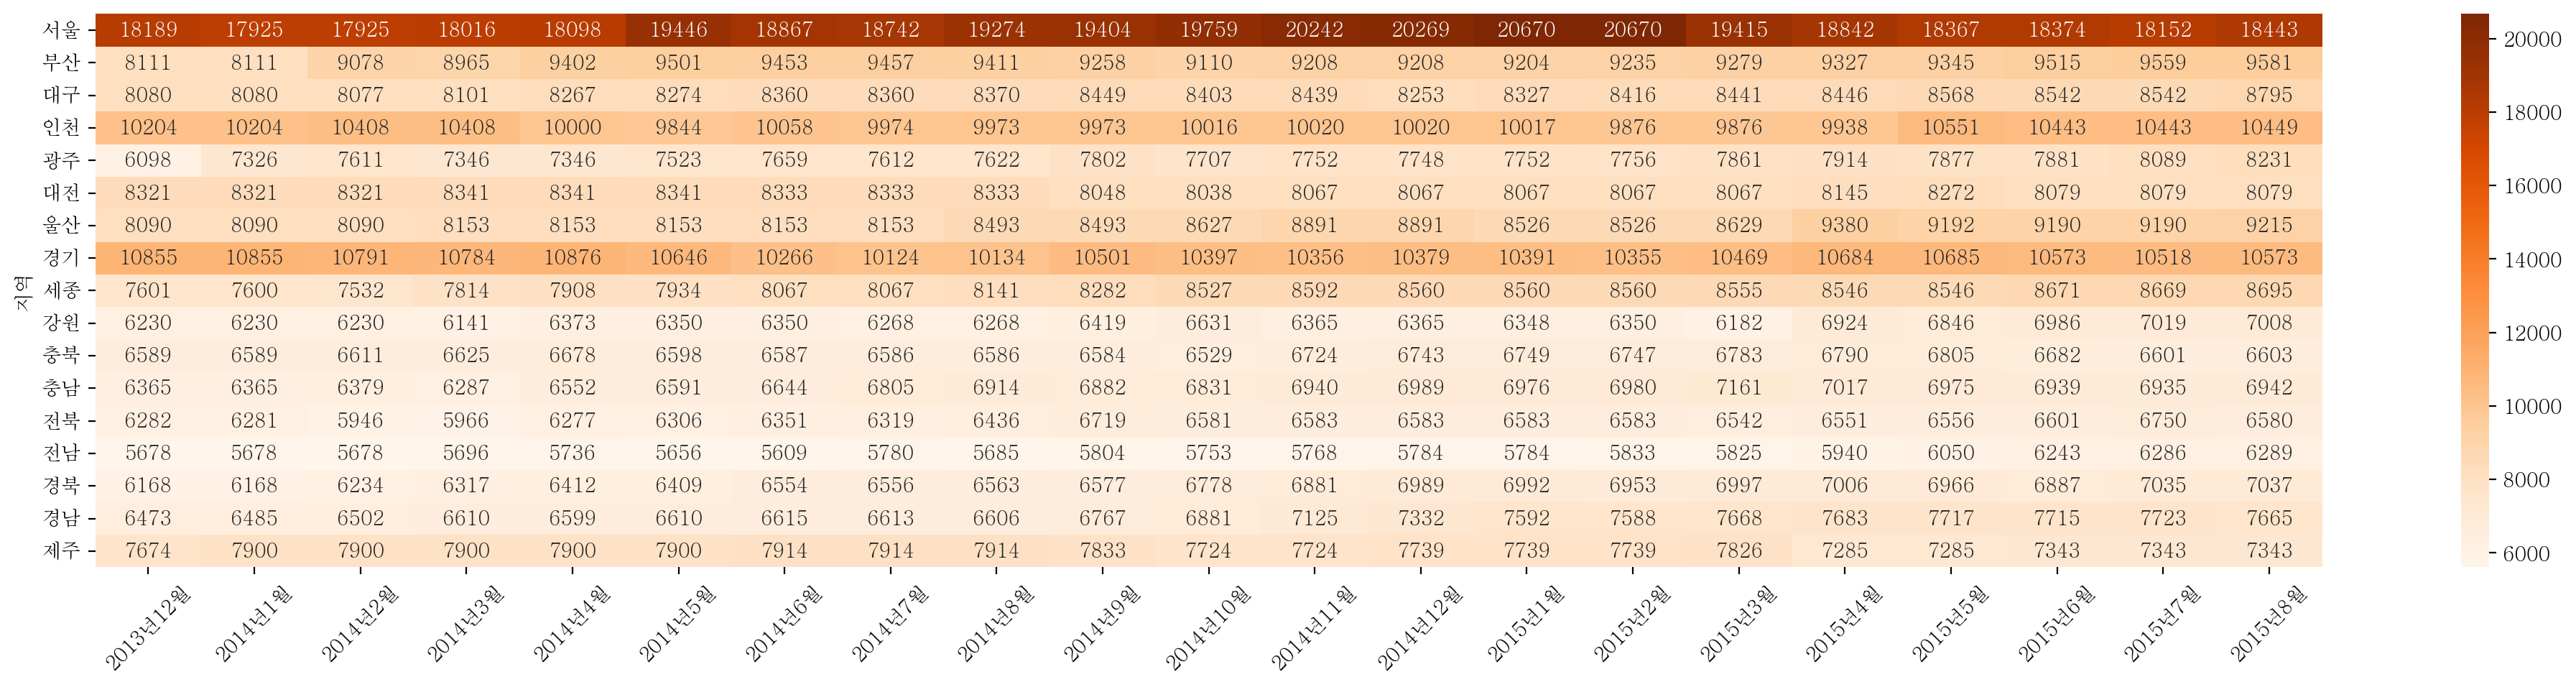

In [13]:
df_first.head(1)
plt.figure(figsize=(25,5))
sns.heatmap(data = df_first, annot=True, fmt = 'd', cmap = 'Oranges')
plt.xticks(rotation = 45)
plt.show()

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

## (2) 2015이후 데이터 분양가격에 간헐적으로 comma(,) 추가하여 csv로 출력
- 분양가격에 np.nan, ' ', 8111 -> '8,111'

In [14]:
ex = pd.read_csv('C:/ai_x/download/sharedata/부동산_250213/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv', encoding= 'cp949')
ex

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,7703
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [15]:
# isna(), isnull() - 결측치 여부 : 분양가격 614개
# notnull(), notna() - 결측치가 아닌지 여부
print('전체 개수 :', ex.shape[0])
print('결측치가 아닌 개수 :', ex['분양가격(제곱미터)'].notna().sum())
print('결측치 :', ex['분양가격(제곱미터)'].isna().sum())

전체 개수 : 9095
결측치가 아닌 개수 : 8481
결측치 : 614


In [16]:
# 분양가격(제곱미터)가 결측치인 행 상위2개
ex[ex['분양가격(제곱미터)'].isna()].head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터)
368,광주,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
369,광주,전용면적 102제곱미터초과,2016,2,NaN


In [17]:
ex.info() # 분양가격(제곱미터) 컬럼의 type => object
type(ex.loc[368, '분양가격(제곱미터)']), type(ex.loc[0, '분양가격(제곱미터)'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   지역명         9095 non-null   object
 1   규모구분        9095 non-null   object
 2   연도          9095 non-null   int64 
 3   월           9095 non-null   int64 
 4   분양가격(제곱미터)  8481 non-null   object
dtypes: int64(2), object(3)
memory usage: 355.4+ KB


(float, str)

In [18]:
# 분양가격(제곱미터) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()
# ex['분양가격(제곱미터)'].astype('float64') # 에러 이유 : could not convert string to float: '  '
# pd.to_numeric(ex['분양가격(제곱미터)']) # 에러 이유 : Unable to parse string "  " at position 28
# pd.to_numeric(ex['분양가격(제곱미터)'], errors='coerce') # 에러나는 행을 결측치NaN 변경
pd.to_numeric(ex['분양가격(제곱미터)'], errors='coerce').isna().sum()

740

In [19]:
# 분양가격(제곱미터) 컬럼이 space인 행 : 740 - 614 = 126개
ex[ex['분양가격(제곱미터)'].str.strip() ==''].head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,


In [20]:
nanex = ex.loc[368] # 분양가격(제곱미터) 결측치
spaceex = ex.loc[28] # 분양가격(제곱미터) space
ex.loc[0] # 분양 가격이 정상

지역명             서울
규모구분          모든면적
연도            2015
월               10
분양가격(제곱미터)    5841
Name: 0, dtype: object

In [21]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    price = row['분양가격(제곱미터)']
    # df.isna() => df or Series 자료구조에서만 사용 가능
    # pd.isna(스칼라 변수) => 스칼라 변수가 np.nan or None 결측치 인지 
    # np.isnan(스칼라 변수) => 스칼라 변수가 np.nan결측치 인지
    # pd.notnull(스칼라 변수) => 스칼라 변수가 결측치가 아닌 지 여부
    # np.notnan(스칼라 변수) => 스칼라 변수가 np.nan결측치가 아닌 지 여부
    # 1차원이나2차원변수.isna() : 결측치 여부
    if pd.notnull(price) and price.strip() != '' :
        return len(price)
    else :
        return 0
    
get_pricelen(nanex), get_pricelen(spaceex), get_pricelen(ex.loc[0])

(0, 0, 4)

In [22]:
ex['자리수'] = ex.apply(get_pricelen, axis=1)
ex.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [23]:
ex.자리수.unique()

array([4, 0, 5], dtype=int64)

In [24]:
ex.index.name = 'idx'
ex.head()

,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
idx,,,,,,
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,4
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,4
4,서울,전용면적 102제곱미터초과,2015,10,5879,4


In [25]:
ex.reset_index(inplace = True)
ex

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,0,서울,모든면적,2015,10,5841,4
1,1,서울,전용면적 60제곱미터이하,2015,10,5652,4
2,2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,4
3,3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,4
4,4,서울,전용면적 102제곱미터초과,2015,10,5879,4
...,...,...,...,...,...,...,...
9090,9090,제주,모든면적,2024,8,7703,4
9091,9091,제주,전용면적 60제곱미터이하,2024,8,NaN,0
9092,9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,4
9093,9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,0


In [26]:
# 자리수가 5인 행 : 8245 행 (, 체크)
ex[(ex.자리수 == 5) & (ex.idx % 5 == 0)].head(1)

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
8245,8245,서울,모든면적,2023,11,10347,5


In [27]:
# 컴마 추가 X : nanex, spaceex, ex.loc[1] 
# 컴마 추가 O : ex.loc[0], ex.loc[8245]

In [28]:
# 2022년 데이터 흉내내기 위한 함수  : nan, ' ', '  ', '5123', '5,123'
# 매개변수로 row(Series)를 받아 nan, ' ', '  ', '5123', '5,123' return
def comma_append(row):
    price = row['분양가격(제곱미터)']
    if row.idx % 5 == 0 and row.자리수 >= 4 :
        price = price[:-3] + ',' + price[-3:]
    return price

In [29]:
nanex = ex.loc[368] # 분양가격(제곱미터) 결측치
spaceex = ex.loc[28] # 분양가격(제곱미터) space
ex.loc[0] # 분양 가격이 정상

idx              0
지역명             서울
규모구분          모든면적
연도            2015
월               10
분양가격(제곱미터)    5841
자리수              4
Name: 0, dtype: object

In [30]:
comma_append(nanex), comma_append(spaceex), comma_append(ex.loc[1]), \
comma_append(ex.loc[0]), comma_append(ex.loc[8245])

(nan, '  ', '5652', '5,841', '10,347')

In [31]:
ex['분양가격(제곱미터)'] = ex.apply(comma_append, axis =1)
ex.head(6)

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,0,서울,모든면적,2015,10,"5,841",4
1,1,서울,전용면적 60제곱미터이하,2015,10,5652,4
2,2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,4
3,3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,4
4,4,서울,전용면적 102제곱미터초과,2015,10,5879,4
5,5,인천,모든면적,2015,10,"3,163",4


In [32]:
ex.drop(['idx','자리수'], axis = 1, inplace=True)
ex

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [33]:
ex

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [34]:
# csv파일 저장(엑셀에서 보려면 cp949, pandas 기본은 utf-8)
ex.to_csv('data/전국제곱미터당분양가격(2015년10월부터).csv', index = False)

In [35]:
# 간헐적으로 평당분양가에 ,가 있거나(5개 마다) np.nan이 있거나 space가 있는 데이터 csv로 백업

## (3) 이후 데이터는 df_last 변수에 담아 탐색

In [36]:
df_last = pd.read_csv('data/전국제곱미터당분양가격(2015년10월부터).csv')
df_last

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [37]:
df_last.shape

(9095, 5)

In [38]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   지역명         9095 non-null   object
 1   규모구분        9095 non-null   object
 2   연도          9095 non-null   int64 
 3   월           9095 non-null   int64 
 4   분양가격(제곱미터)  8481 non-null   object
dtypes: int64(2), object(3)
memory usage: 355.4+ KB


# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [39]:
# 열별 결측치 갯수
df_last.isna().sum()

지역명             0
규모구분            0
연도              0
월               0
분양가격(제곱미터)    614
dtype: int64

In [40]:
# 열별 결측치를 제외한 갯수
df_last.notna().sum()

지역명           9095
규모구분          9095
연도            9095
월             9095
분양가격(제곱미터)    8481
dtype: int64

# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정, space가 저장된 경우 nan으로 수정하는 함수를 apply나 map적용
## (3) df_last['분양가격(제곱미터)']*3.3

In [41]:
# df_last['분양가격(제곱미터)'].astype(np.float64)*3.3
# df_last['분양가격(제곱미터)'].str.replace(',','').astype(np.float64)
# ,와 space때문에 에러
pd.to_numeric(df_last['분양가격(제곱미터)'], errors='coerce') # 비추

0          NaN
1       5652.0
2       5882.0
3       5721.0
4       5879.0
         ...  
9090       NaN
9091       NaN
9092    7515.0
9093       NaN
9094    7950.0
Name: 분양가격(제곱미터), Length: 9095, dtype: float64

### apply

In [42]:
# 콤마가 있는 문자에서 콤마 없애기 방법1
temp = '12,523'
temp.replace(',','')

'12523'

In [43]:
# 콤마가 있는 문자에서 콤마 없애기 방법2
temp = '12,523'
''.join(temp.split(','))

'12523'

In [44]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    price = row['분양가격(제곱미터)']
    if pd.isnull(price) : # np.nan, None, Null 체크
        row['제곱미터분양가격'] = np.nan
    elif price.strip() == '' : # space => np.nan
        row['제곱미터분양가격'] = np.nan
    elif price.find(',') != -1 :
        row['제곱미터분양가격'] = price.replace(',','')
    else :
        row['제곱미터분양가격'] = price
    return row

commadrop(df_last.loc[0]) # 콤마 제외
commadrop(df_last.loc[1]) # 그대로
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
commadrop(df_last.loc[368]) # nan의 경우 nan

지역명                                광주
규모구분          전용면적 85제곱미터초과 102제곱미터이하
연도                               2016
월                                   2
분양가격(제곱미터)                        NaN
제곱미터분양가격                          NaN
Name: 368, dtype: object

In [45]:
%%time
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용
df_last = df_last.apply(commadrop, axis=1)

CPU times: total: 4.62 s
Wall time: 4.74 s


In [46]:
df_last.제곱미터분양가격 = df_last.제곱미터분양가격.astype('float64')

In [47]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         9095 non-null   object 
 1   규모구분        9095 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   분양가격(제곱미터)  8481 non-null   object 
 5   제곱미터분양가격    8355 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 426.5+ KB


In [48]:
# map 사용을 위해 df_last의 제곱미터분양가격 drop
df_map = df_last.drop('제곱미터분양가격', axis = 1)
df_map

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


### map

In [49]:
df_map

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [50]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    # if pd.isnull(price)
    # if price is np.nan
    # if price is null
    # if np.isnan(price)
    if pd.isna(price) :
        return np.nan
    elif price.strip() == '' :
        return np.nan
    elif price.find(',')!= -1:
        return int(price.replace(',',''))
    else :
        return int(price)

commadrop2(df_map.loc[0, '분양가격(제곱미터)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_map.loc[1, '분양가격(제곱미터)']) # 콤마없는 문자를 숫자로 
commadrop2(df_map.loc[28, '분양가격(제곱미터)']) # 공백문자를 nan
commadrop2(df_map.loc[368, '분양가격(제곱미터)']) # nan을 nan

nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [51]:
#df_map['분양가격(제곱미터)'].apply(commadrop2)
#df_map['분양가격(제곱미터)'].map(commadrop2)
df_map['분양가격(제곱미터)'].map(commadrop2)

0       5841.0
1       5652.0
2       5882.0
3       5721.0
4       5879.0
         ...  
9090    7703.0
9091       NaN
9092    7515.0
9093       NaN
9094    7950.0
Name: 분양가격(제곱미터), Length: 9095, dtype: float64

In [52]:
df_map['제곱미터당분양가격'] = df_map['분양가격(제곱미터)'].map(commadrop2)
df_map.tail(2)

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN
9094,제주,전용면적 102제곱미터초과,2024,8,7950,7950.0


In [53]:
df_map.dtypes

지역명            object
규모구분           object
연도              int64
월               int64
분양가격(제곱미터)     object
제곱미터당분양가격     float64
dtype: object

In [54]:
df_map['평당분양가격'] = df_map.제곱미터당분양가격 * 3.3
df_map

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격,평당분양가격
0,서울,모든면적,2015,10,"5,841",5841.0,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0,19400.7
...,...,...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703",7703.0,25419.9
9091,제주,전용면적 60제곱미터이하,2024,8,NaN,NaN,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,7515.0,24799.5
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN,NaN


In [55]:
df_map

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격,평당분양가격
0,서울,모든면적,2015,10,"5,841",5841.0,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0,19400.7
...,...,...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703",7703.0,25419.9
9091,제주,전용면적 60제곱미터이하,2024,8,NaN,NaN,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,7515.0,24799.5
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN,NaN


# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [56]:
df_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         9095 non-null   object 
 1   규모구분        9095 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   분양가격(제곱미터)  8481 non-null   object 
 5   제곱미터당분양가격   8355 non-null   float64
 6   평당분양가격      8355 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 497.5+ KB


In [57]:
# 규모 구분 컬럼을 중복 단어를 제외 하고 전용 면적 컬럼
df_map['전용면적'] = df_map['규모구분'].str.replace('전용면적','').str.replace('제곱미터','㎡').str.replace('초과','~').str.replace('이하','').str.replace(' ','')

In [58]:
df_map['규모구분'].unique()
df_map['전용면적'].unique()
df_map

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격,평당분양가격,전용면적
0,서울,모든면적,2015,10,"5,841",5841.0,19275.3,모든면적
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0,18651.6,60㎡
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0,19410.6,60㎡~85㎡
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0,18879.3,85㎡~102㎡
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0,19400.7,102㎡~
...,...,...,...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703",7703.0,25419.9,모든면적
9091,제주,전용면적 60제곱미터이하,2024,8,NaN,NaN,NaN,60㎡
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,7515.0,24799.5,60㎡~85㎡
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN,NaN,85㎡~102㎡


# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [59]:
df_map.info() # 규모구분, 분양가격(제곱미터),제곱미터분양가격

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         9095 non-null   object 
 1   규모구분        9095 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   분양가격(제곱미터)  8481 non-null   object 
 5   제곱미터당분양가격   8355 non-null   float64
 6   평당분양가격      8355 non-null   float64
 7   전용면적        9095 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 568.6+ KB


In [60]:
df_map = df_map.drop(['규모구분', '분양가격(제곱미터)','제곱미터당분양가격'], axis=1)

In [61]:
df_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     9095 non-null   object 
 1   연도      9095 non-null   int64  
 2   월       9095 non-null   int64  
 3   평당분양가격  8355 non-null   float64
 4   전용면적    9095 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 355.4+ KB


In [62]:
df_map.to_csv('data/df_last.csv', index = False) # 전처리 단계 백업

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

In [63]:
df_map.head(1)

,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,모든면적


- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

In [64]:
df_map['지역명'].value_counts() # 결측치를 포함한 데이터 개수

서울    535
강원    535
경남    535
경북    535
전남    535
전북    535
충남    535
충북    535
세종    535
인천    535
울산    535
대전    535
광주    535
대구    535
부산    535
경기    535
제주    535
Name: 지역명, dtype: int64

In [65]:
# 지역명 별 데이터 행수(결측치 제외) : 결과 1차원 시리즈
df_map.groupby('지역명')['평당분양가격'].count().sort_values(ascending = False)

지역명
경기    535
충북    533
부산    533
인천    531
서울    527
강원    523
전북    520
경남    516
충남    516
경북    511
전남    507
대구    495
광주    450
제주    439
대전    415
세종    409
울산    395
Name: 평당분양가격, dtype: int64

In [66]:
# 지역명 별 데이터 행수(결측치 제외) : 결과 2차원 DataFrame
df_map.groupby('지역명')['평당분양가격'].count().sort_values(ascending = False).to_frame().T # 1열 형태 데이터프레임
df_map.groupby('지역명')[['평당분양가격']].count().T # 1열 형태 데이터프레임
df_map.groupby('지역명', as_index=False)['평당분양가격'].count() # 2열 형태 지역명 컬럼
df_map.groupby('지역명')['평당분양가격'].count().reset_index() # 2열 지역명 컬럼

df_map.groupby('지역명')['평당분양가격'].count().sort_values(ascending = False).to_frame().T

지역명,경기,충북,부산,인천,서울,강원,전북,경남,충남,경북,전남,대구,광주,제주,대전,세종,울산
평당분양가격,535,533,533,531,527,523,520,516,516,511,507,495,450,439,415,409,395


In [67]:
# pivot_table : DataFrame 반환
df_map.groupby('지역명')[['평당분양가격']].count()
df_map.pivot_table(values = '평당분양가격', index = '지역명' , aggfunc = 'count').head(1)

,평당분양가격
지역명,
강원,523


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [68]:
df_map.groupby('지역명')['평당분양가격'].describe()

,count,mean,std,min,25%,50%,75%,max
지역명,,,,,,,,
강원,523.0,10078.717400,2828.907867,6639.6,7652.700,9428.10,11873.400,17806.8
경기,535.0,15420.030280,3245.863323,10160.7,13274.250,14652.00,17168.250,24172.5
경남,516.0,10776.955814,2223.562736,7260.0,9187.200,10254.75,12031.800,16566.0
경북,511.0,10261.553425,2276.026239,6949.8,8378.700,9705.30,12500.400,15345.0
광주,450.0,12998.216000,3637.557312,7428.3,9554.325,12673.65,15213.000,24951.3
대구,495.0,14434.520000,3407.303427,8259.9,11949.300,14711.40,16338.300,30600.9
대전,415.0,12829.565060,4191.685609,8002.5,9401.700,11820.60,15310.350,30851.7
부산,533.0,14896.949156,4059.939958,9669.0,12467.400,13411.20,17301.900,31904.4
서울,527.0,27755.404554,6566.391764,16701.3,22497.750,26763.00,31054.650,61917.9


In [69]:
df_map.groupby('지역명')[['평당분양가격']].max().sort_values(by = '평당분양가격',ascending =False).head(3)

,평당분양가격
지역명,
서울,61917.9
인천,54723.9
부산,31904.4


In [70]:
df_map.groupby('지역명')[['평당분양가격']].mean().sort_values(by = '평당분양가격',ascending =False).head(3)
df_map.groupby('지역명')['평당분양가격'].mean().sort_values(ascending =False).to_frame().head(3)

,평당분양가격
지역명,
서울,27755.404554
제주,15912.434624
경기,15420.030280


In [71]:
# 지역별 평당분양가격 최대, 평균, 통계요약정보를 pivot_table로
df_map.pivot_table(index = '지역명',values = '평당분양가격', aggfunc = 'max')
df_map.pivot_table(index = '지역명',values = '평당분양가격', aggfunc = 'mean')
df_map.pivot_table(index = '지역명',values = '평당분양가격', aggfunc = 'describe').applymap(lambda x : round(x,1))

,25%,50%,75%,count,max,mean,min,std
지역명,,,,,,,,
강원,7652.7,9428.1,11873.4,523.0,17806.8,10078.7,6639.6,2828.9
경기,13274.2,14652.0,17168.2,535.0,24172.5,15420.0,10160.7,3245.9
경남,9187.2,10254.8,12031.8,516.0,16566.0,10777.0,7260.0,2223.6
경북,8378.7,9705.3,12500.4,511.0,15345.0,10261.6,6949.8,2276.0
광주,9554.3,12673.6,15213.0,450.0,24951.3,12998.2,7428.3,3637.6
대구,11949.3,14711.4,16338.3,495.0,30600.9,14434.5,8259.9,3407.3
대전,9401.7,11820.6,15310.3,415.0,30851.7,12829.6,8002.5,4191.7
부산,12467.4,13411.2,17301.9,533.0,31904.4,14896.9,9669.0,4059.9
서울,22497.8,26763.0,31054.6,527.0,61917.9,27755.4,16701.3,6566.4


## (3) 전용면적별 평당분양가격(평균)

In [72]:
df_map.groupby('전용면적')['평당분양가격'].mean().to_frame().applymap(lambda x : round(x,1)).sort_values('평당분양가격')

,평당분양가격
전용면적,
60㎡,12522.8
60㎡~85㎡,12619.0
모든면적,12654.1
85㎡~102㎡,13447.7
102㎡~,14066.8


In [73]:
df_map.pivot_table(index = '전용면적',values = '평당분양가격', aggfunc='mean').applymap(lambda x : round(x,1)).sort_values('평당분양가격')

,평당분양가격
전용면적,
60㎡,12522.8
60㎡~85㎡,12619.0
모든면적,12654.1
85㎡~102㎡,13447.7
102㎡~,14066.8


## (4) 지역별, 전용면적별 평당분양가격(평균)

In [74]:
r = df_map.groupby(['지역명','전용면적'])['평당분양가격'].mean()
print(r)
print(r['서울'])
print(r[('서울','모든면적')])

지역명  전용면적    
강원   102㎡~       11314.805607
     60㎡          9441.885981
     60㎡~85㎡      9383.472897
     85㎡~102㎡    10795.481053
     모든면적         9538.326168
                     ...     
충북   102㎡~        9369.532710
     60㎡          8598.227103
     60㎡~85㎡      8558.503738
     85㎡~102㎡     9418.420000
     모든면적         8547.986916
Name: 평당분양가격, Length: 85, dtype: float64
전용면적
102㎡~       29035.948515
60㎡         27371.156075
60㎡~85㎡     26662.612150
85㎡~102㎡    28972.177143
모든면적        26829.678505
Name: 평당분양가격, dtype: float64
26829.678504672895


In [75]:
r.to_frame()

평당분양가격
지역명 전용면적                  
강원  102㎡~     11314.805607
    60㎡        9441.885981
    60㎡~85㎡    9383.472897
    85㎡~102㎡  10795.481053
    모든면적       9538.326168
...                    ...
충북  102㎡~      9369.532710
    60㎡        8598.227103
    60㎡~85㎡    8558.503738
    85㎡~102㎡   9418.420000
    모든면적       8547.986916

[85 rows x 1 columns]

In [76]:
r = df_map.groupby(['지역명','전용면적'])['평당분양가격'].mean()
# 2차원 index 중 level0 인덱스는 그대로, level1 인덱스를 컬러으로
r.unstack().round()

전용면적,102㎡~,60㎡,60㎡~85㎡,85㎡~102㎡,모든면적
지역명,,,,,
강원,11315.0,9442.0,9383.0,10795.0,9538.0
경기,16559.0,15291.0,14787.0,15740.0,14723.0
경남,11522.0,10122.0,10108.0,12151.0,10147.0
경북,11061.0,9732.0,9828.0,10968.0,9857.0
광주,14749.0,12254.0,12656.0,12292.0,12798.0
대구,15564.0,13748.0,14494.0,13714.0,14517.0
대전,17662.0,11834.0,11920.0,13003.0,11948.0
부산,15741.0,14449.0,14745.0,14801.0,14765.0
서울,29036.0,27371.0,26663.0,28972.0,26830.0


In [77]:
df_map.pivot_table(columns='전용면적',index = '지역명',values='평당분양가격', aggfunc = 'mean')
df_map.pivot_table(index = ['지역명', '전용면적'],values='평당분양가격', aggfunc = 'mean').unstack()
r = df_map.pivot_table(columns='전용면적',index = '지역명',values='평당분양가격', aggfunc = 'mean')
r= r[['60㎡','60㎡~85㎡','85㎡~102㎡','102㎡~','모든면적']]

In [78]:
r

전용면적,60㎡,60㎡~85㎡,85㎡~102㎡,102㎡~,모든면적
지역명,,,,,
강원,9441.885981,9383.472897,10795.481053,11314.805607,9538.326168
경기,15291.151402,14787.207477,15739.920561,16559.091589,14722.780374
경남,10122.231429,10107.838318,12150.634021,11522.478000,10146.513084
경북,9731.888571,9828.325234,10968.300000,11060.616346,9856.637383
광주,12254.043564,12655.962617,12291.714286,14749.190323,12798.356075
대구,13748.378351,14494.393269,13713.937500,15564.029412,14516.541346
대전,11834.224752,11920.124299,13002.643902,17662.047458,11947.572897
부산,14448.602804,14744.955140,14801.024299,15741.408571,14764.539252
서울,27371.156075,26662.612150,28972.177143,29035.948515,26829.678505


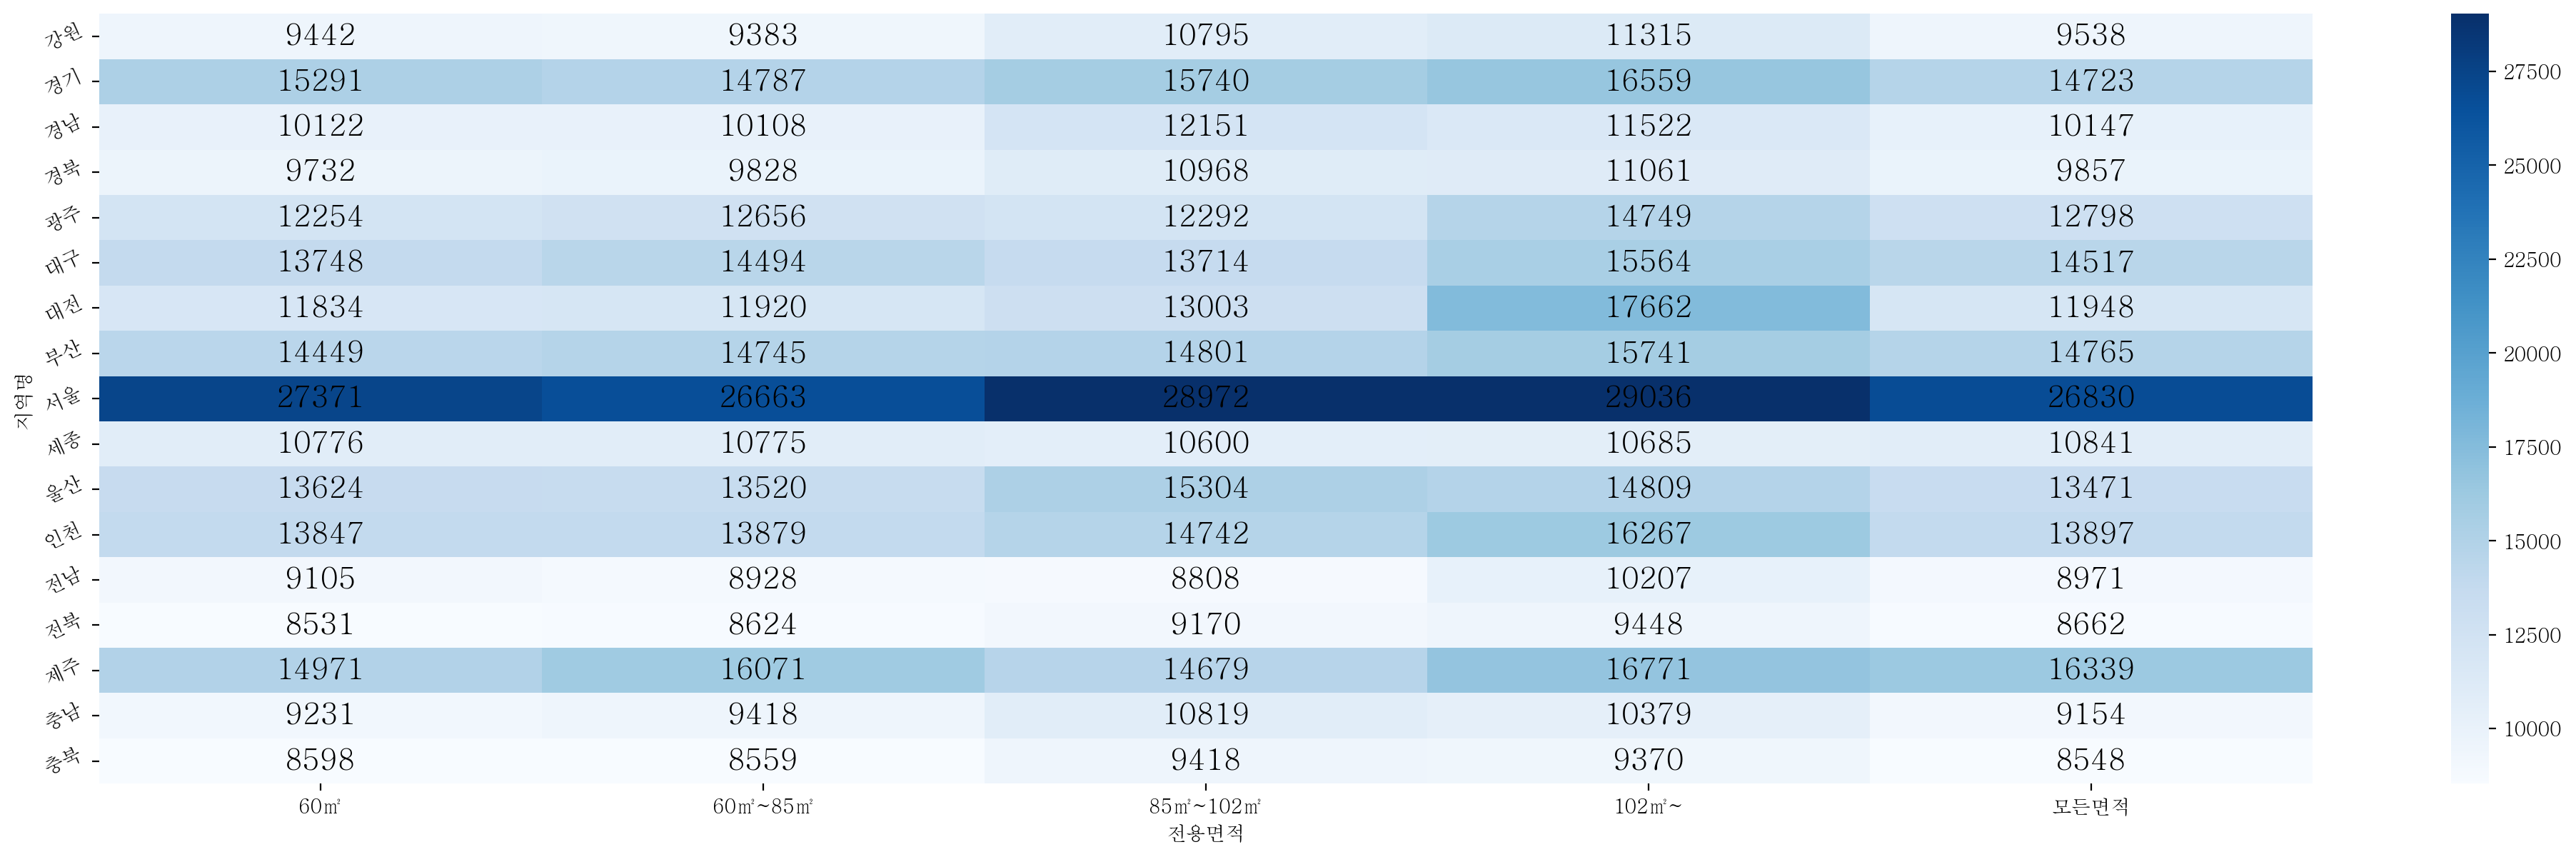

In [79]:
plt.figure(figsize = (25,7))
sns.heatmap(r, cmap = 'Blues', annot = True, fmt = '.0f', annot_kws = {'size' : 15, 'weight' : 'bold', 'color' : 'black'})
plt.yticks(rotation = 25)
plt.show()

## (5) 연도, 지역별 평당분양가격(평균)

In [80]:
df_map.groupby(['연도','지역명'])['평당분양가격'].mean().to_frame().unstack().T.applymap(lambda x : round(x,1))

연도             2015     2016     2017     2018     2019     2020     2021  \
       지역명                                                                  
평당분양가격 강원    7188.1   7162.9   7318.9   8219.3   8934.5  10302.4  10291.3   
       경기   11060.9  11685.0  12296.2  14258.4  15665.5  15106.1  14567.1   
       경남    8459.2   8496.7   8806.6   9327.7  10697.6  10919.3  11302.3   
       경북    7464.2   7753.4   8288.1   8680.8   9050.2   9997.7  11227.1   
       광주    7916.7   9190.7   9599.7   9527.0  12111.7  13406.5  13709.8   
       대구    9018.9  10282.0  12192.0  12139.3  14081.6  15314.2  15586.3   
       대전    8190.6   8910.7   9912.9  10234.1  12619.2  11238.8  11994.2   
       부산   10377.4  10743.5  11637.6  12890.0  13537.9  13353.0  14317.7   
       서울   20315.7  21753.4  21864.1  23202.2  28286.8  29781.0  29380.4   
       세종    8765.0   8857.8   9132.9  10340.5  11299.4  11628.1  12578.1   
       울산    9367.6   9582.6  10630.2  10241.4  10216.2  12837.6  14192.0   
       인천   10976.0  11099.1  11672.4  11881.5  13249.8  14983.0  15774.3   
       전남    6798.9   6936.6   7413.2   7929.8   8219.3   9562.4   9980.8   
       전북    7110.4   6906.6   7406.1   8174.6   8532.3   8559.4   9047.9   
       제주    7951.1   9567.5  12628.5  11936.0  11828.5  14192.9  22302.3   
       충남    7689.9   7958.2   8157.3   8201.8   8748.8   9139.4   9860.7   
       충북    6828.8   7133.3   7462.6   8149.3   7970.9   8359.0   8822.4   

연도             2022     2023     2024  
       지역명                             
평당분양가격 강원   11644.2  13409.4  15622.3  
       경기   16621.5  20175.2  21532.5  
       경남   12455.7  13283.2  13776.6  
       경북   12018.0  13025.3  14085.4  
       광주   15095.9  17957.9  18548.4  
       대구   16821.9  17656.7  24102.3  
       대전   14113.9  17917.3  19881.9  
       부산   18166.8  20470.9  22900.3  
       서울   29128.5  33230.6  38981.8  
       세종   11310.0  12278.2  19115.8  
       울산   17903.8  18832.1  17828.8  
       인천   17341.8  16150.7  21506.3  
       전남   10635.5  11846.7  13540.4  
       전북   10003.1  10966.0  12400.9  
       제주   18953.8  24095.9  25096.1  
       충남   11730.3  12580.6  12739.6  
       충북   10033.5  11104.0  12851.8

In [81]:
# df_map.groupby(['연도','지역명'])['평당분양가격'].mean().to_frame().unstack().T.applymap(lambda x : round(x,1))
r = df_map.pivot_table(index = '연도',columns = '지역명',values = '평당분양가격', aggfunc = 'mean').applymap(lambda x : round(x,1))

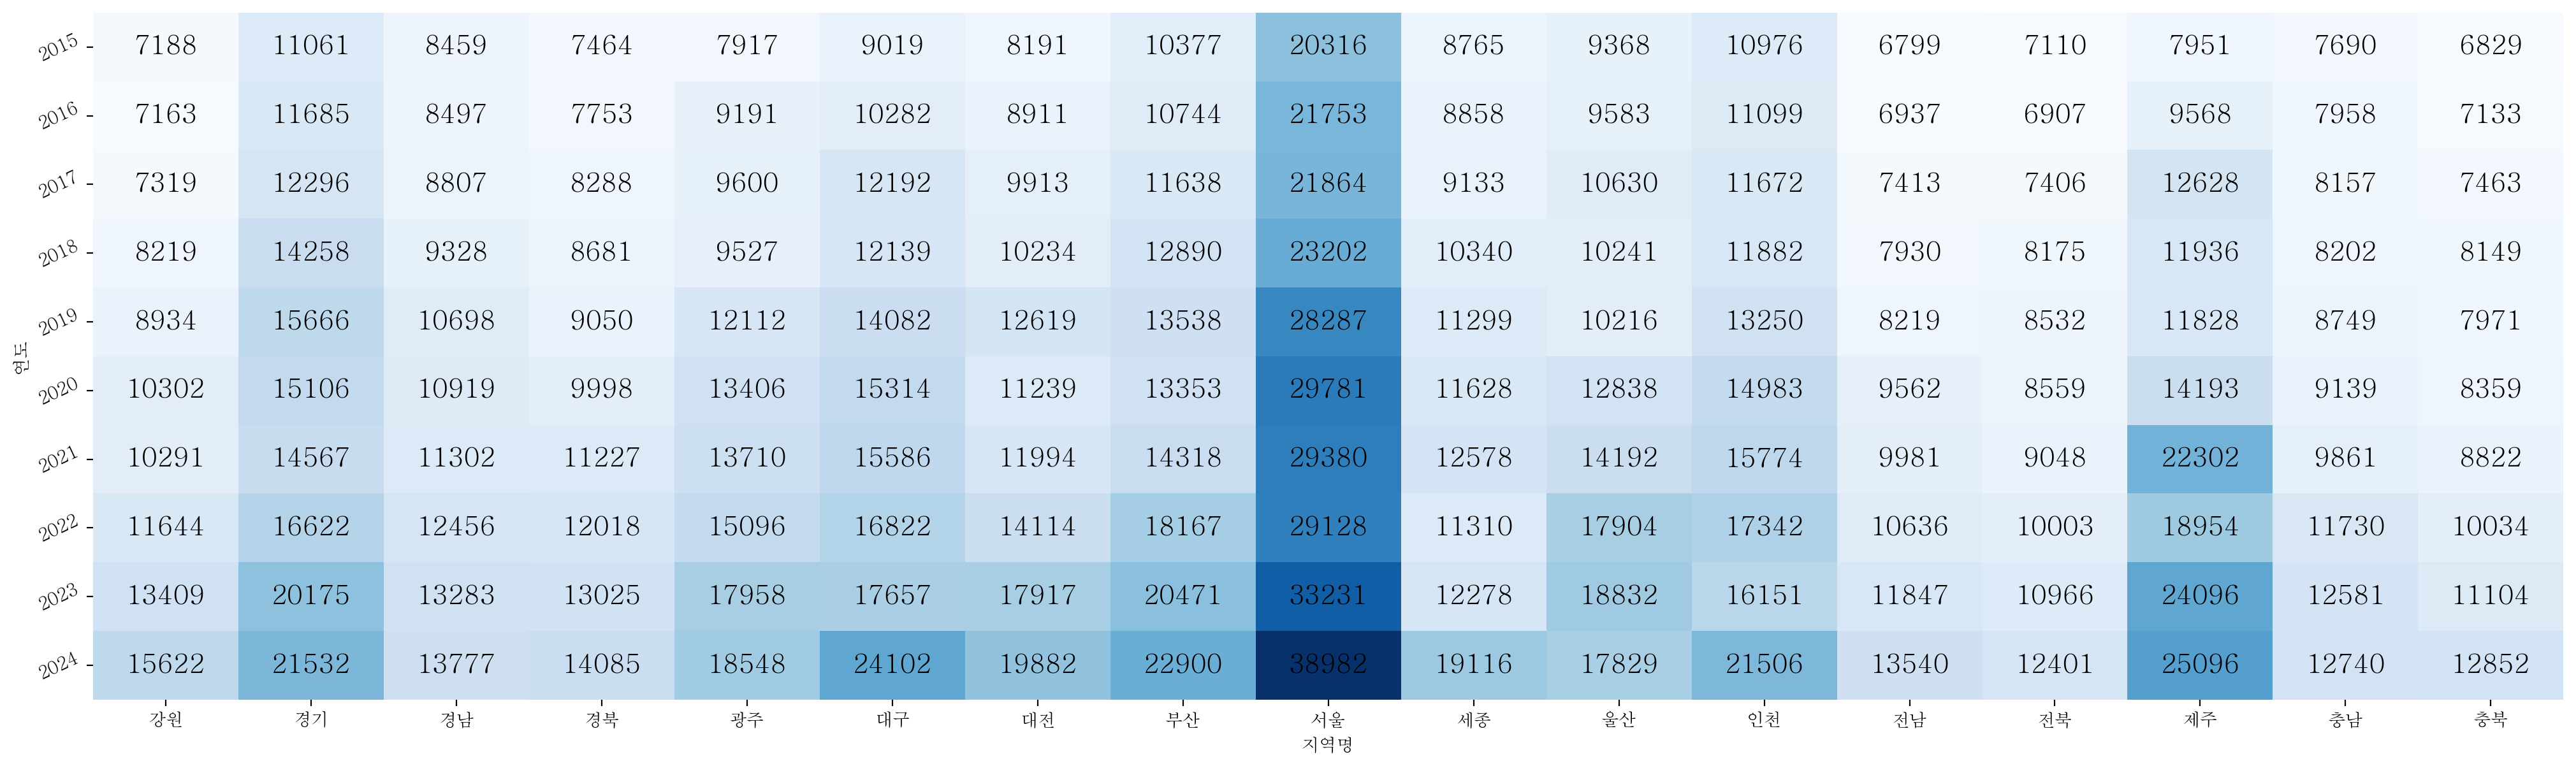

In [82]:
r
plt.figure(figsize = (25,7))
sns.heatmap(r, cmap = 'Blues', annot = True, fmt = '.0f', annot_kws = {'size' : 15, 'weight' : 'bold', 'color' : 'black'}, cbar = False)
plt.yticks(rotation = 25)
plt.show()

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/ <br>
동일한 통계, 다른 분포
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

In [85]:
len(result)

17

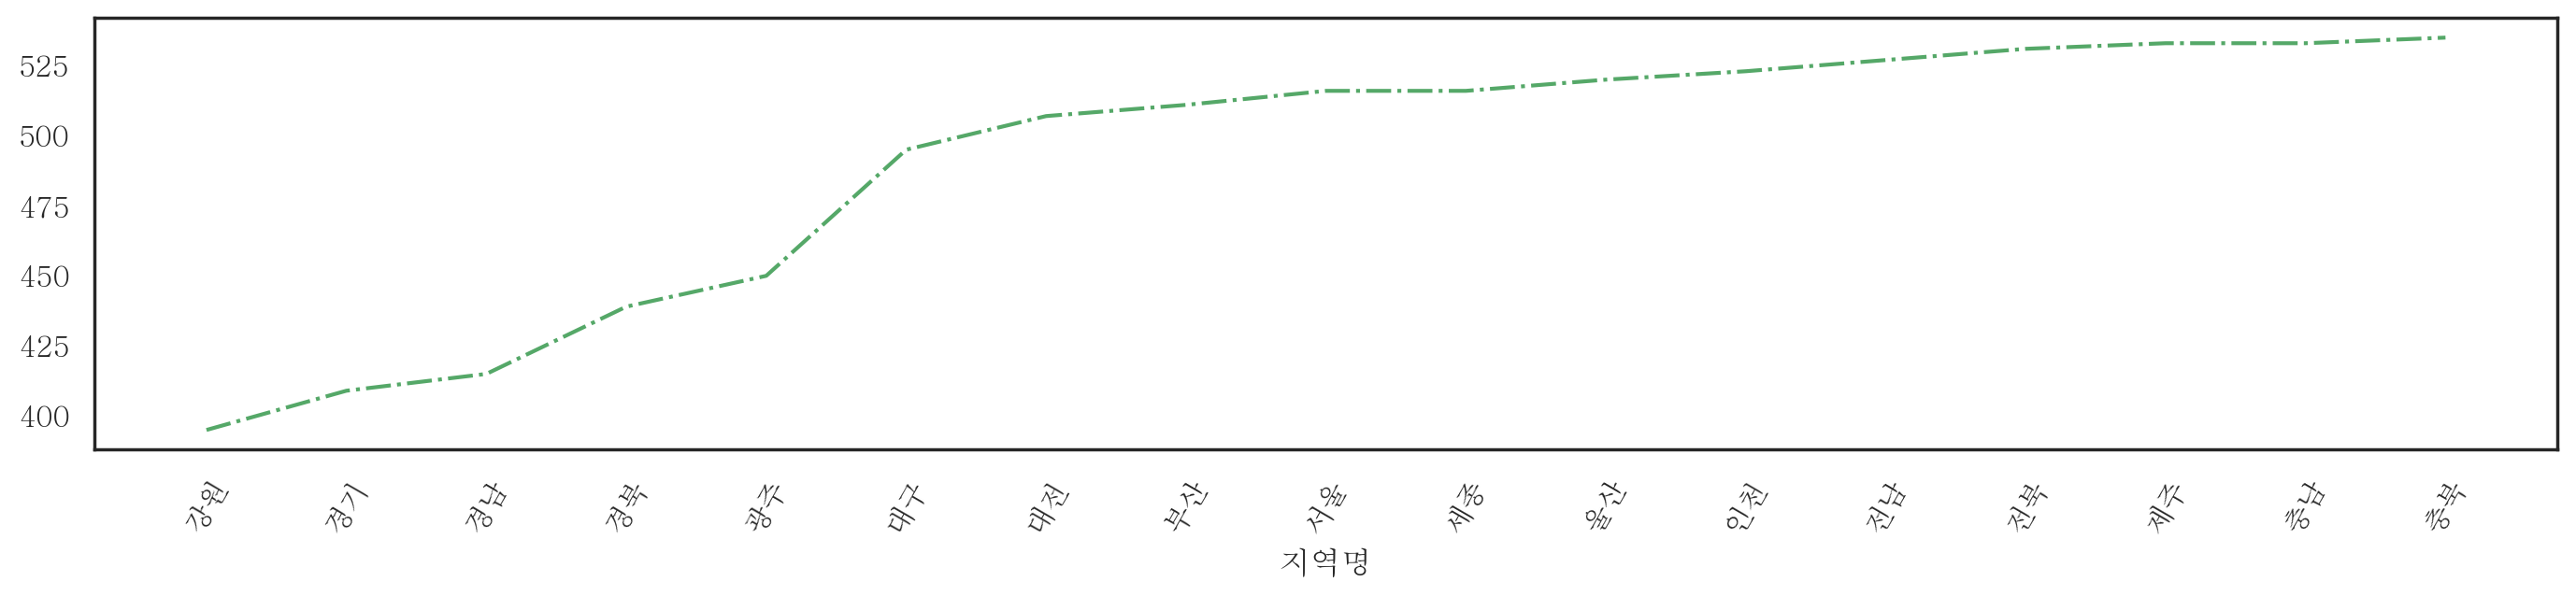

In [108]:
result = df_map.groupby('지역명')['평당분양가격'].count()
#result.sort_values().plot(kind = 'line', figsize = (27,7), linewidth=1, marker = 'o')
plt.figure(figsize=(17,3))
ax = result.sort_values().plot.line(color = 'g', linestyle='-.')
ax.set_xticks(range(len(result)))
ax.set_xticklabels(result.index, rotation = 60, size = 11)
plt.show()

<Axes: xlabel='지역명'>

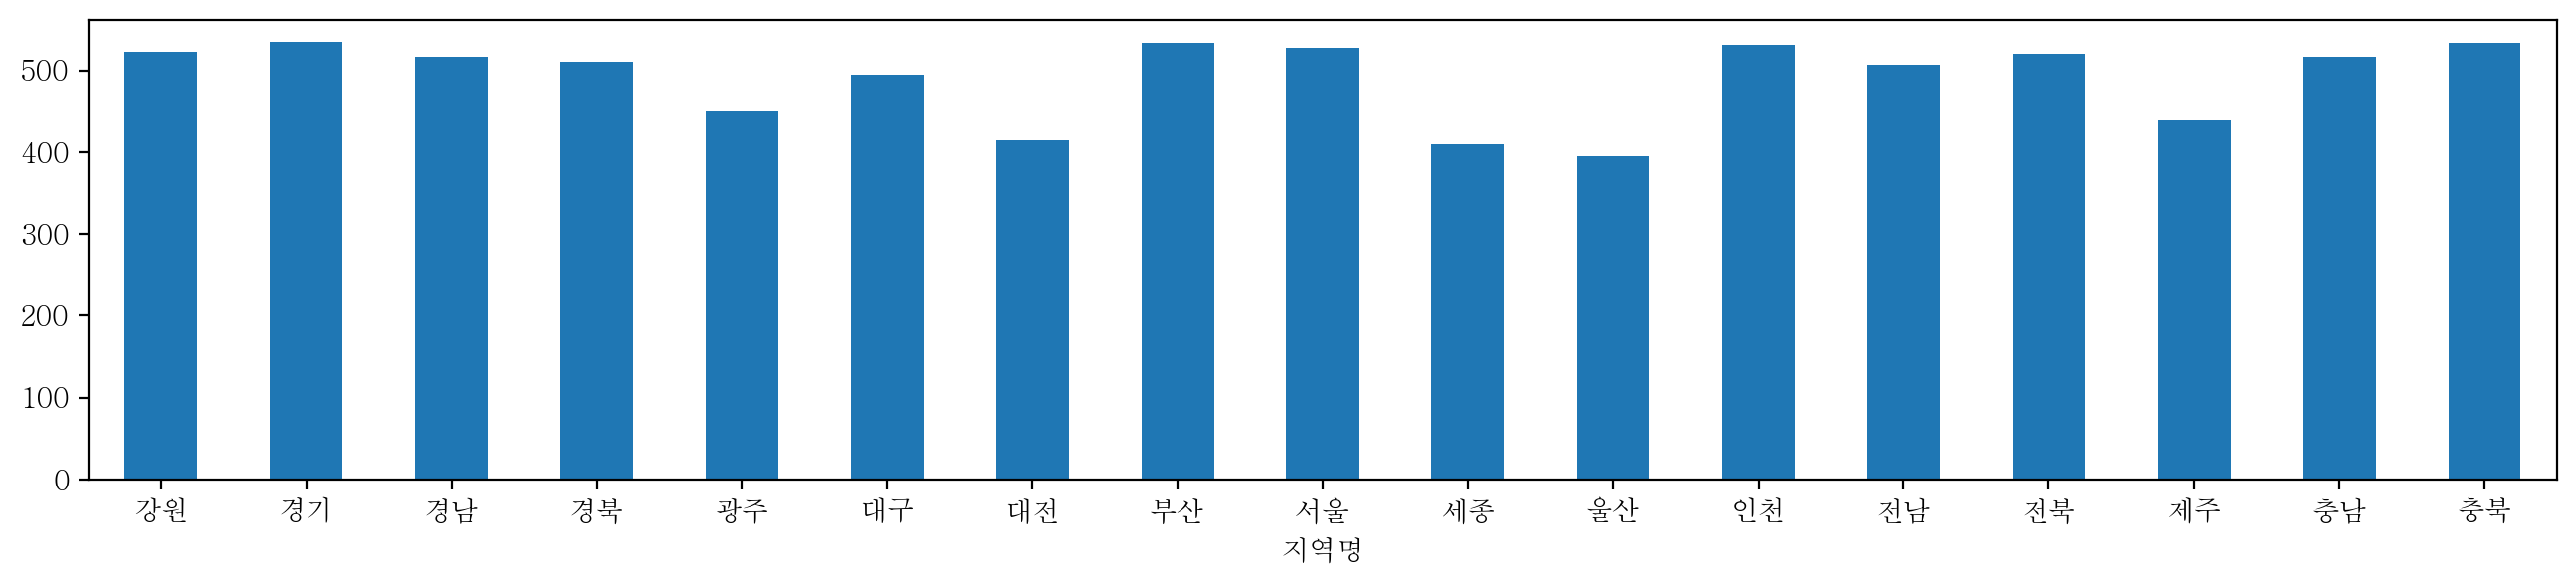

In [86]:
result.plot.bar(rot=0, figsize = (16,3))

## (2) 지역별 평당분양가격 (line, bar)

<Axes: xlabel='지역명'>

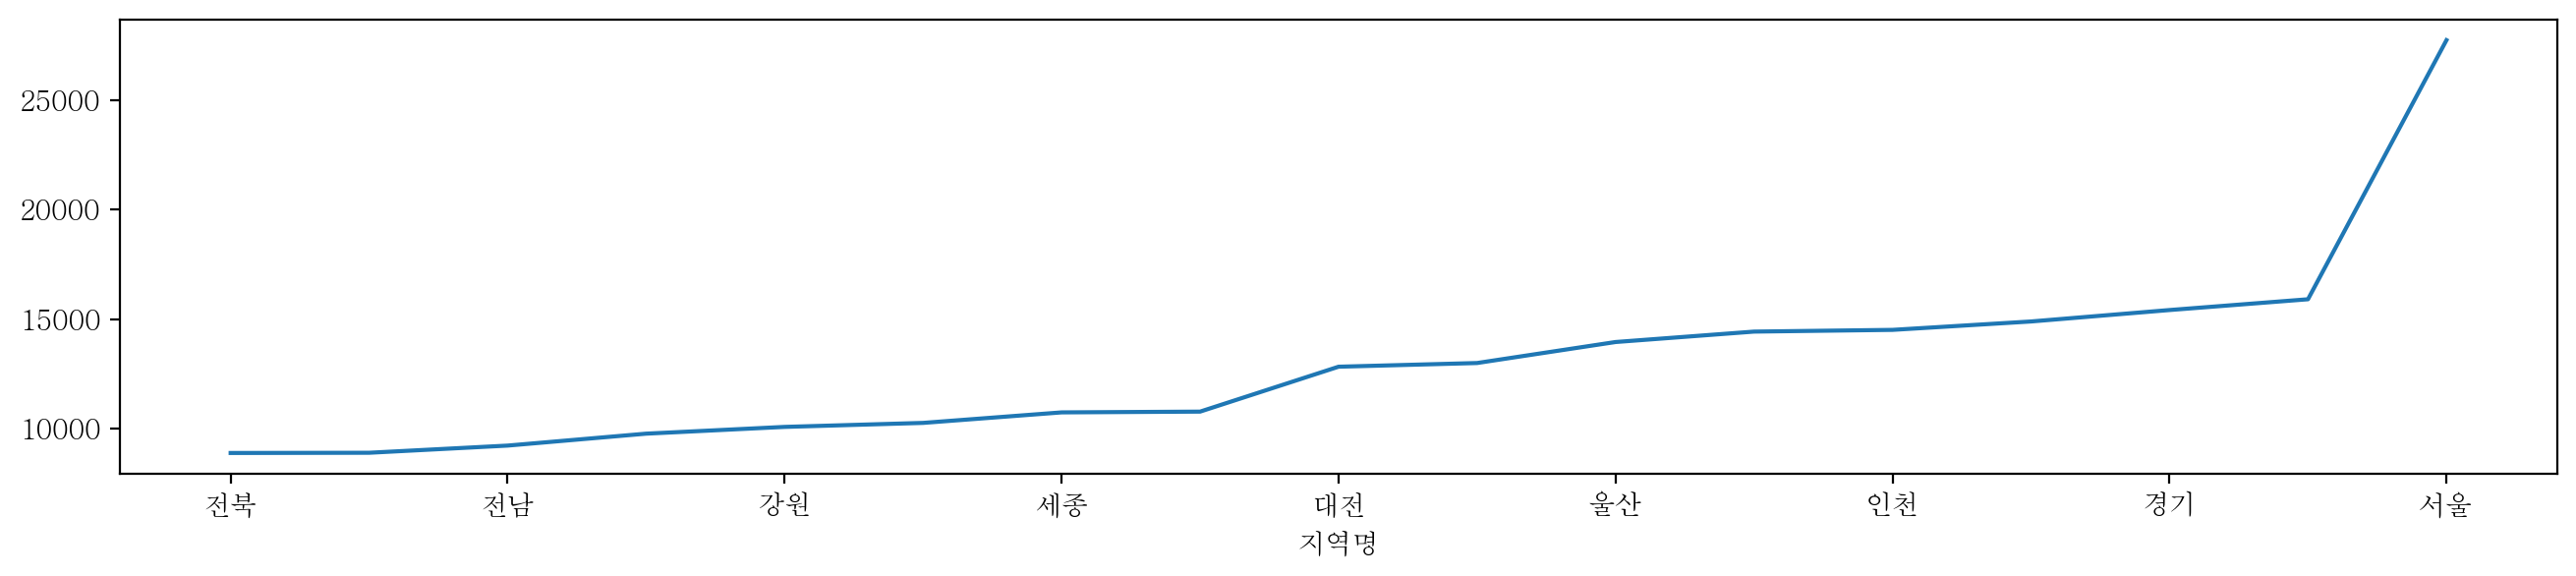

In [87]:
df_map.groupby('지역명')['평당분양가격'].mean().sort_values().plot.line(figsize = (16,3))

<Axes: xlabel='지역명'>

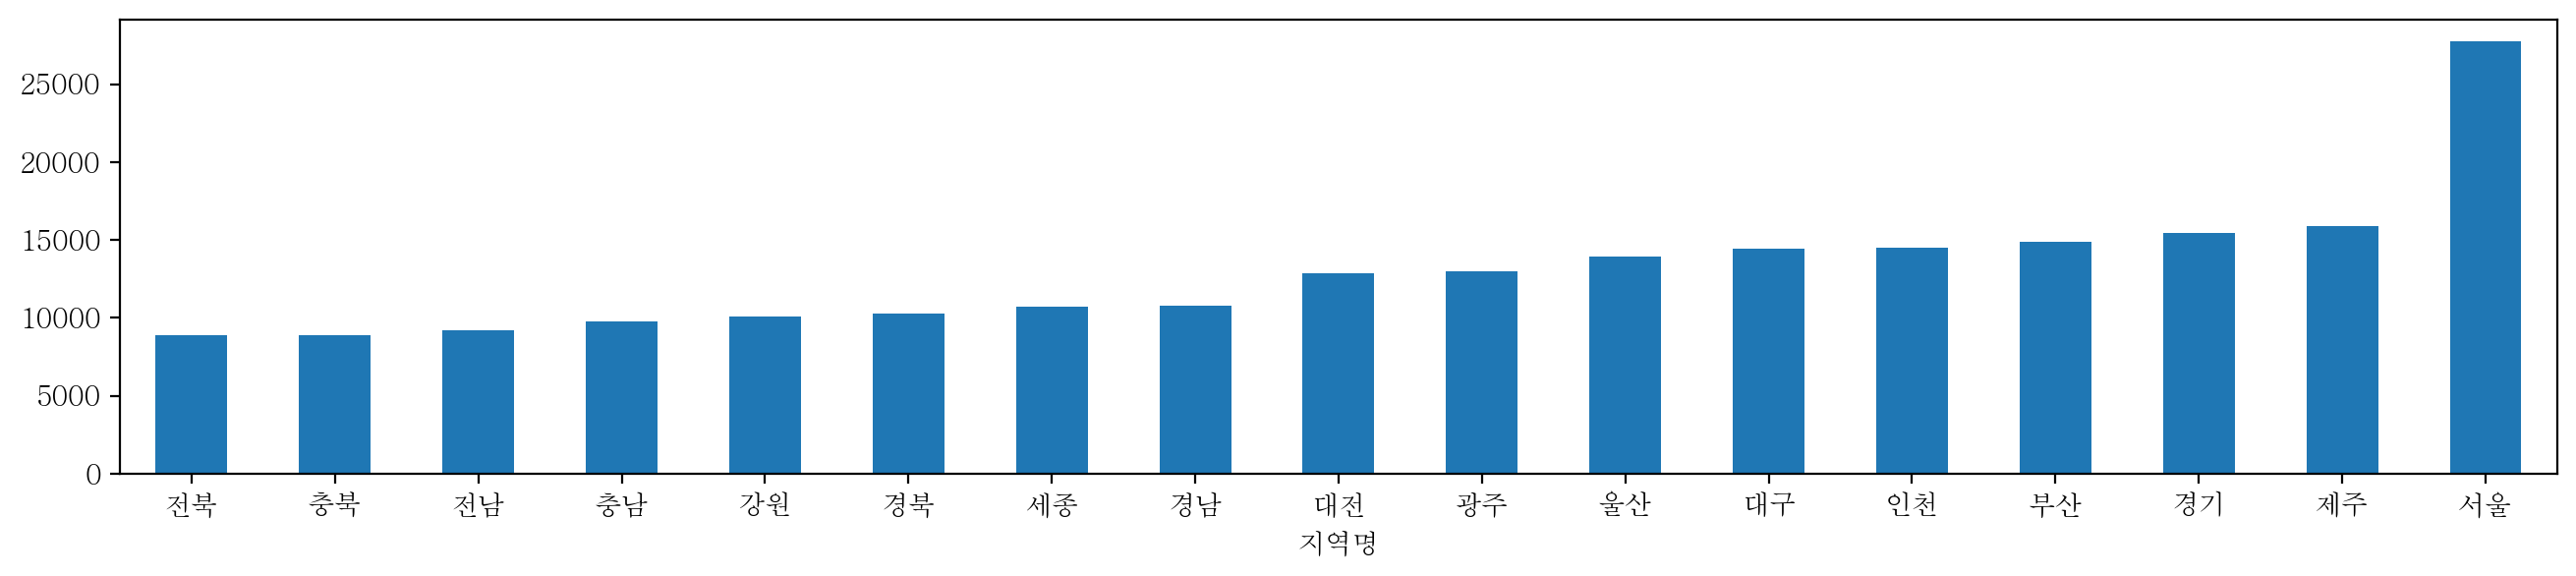

In [88]:
df_map.groupby('지역명')['평당분양가격'].mean().sort_values().plot.bar(figsize = (16,3), rot = 0)

## (3) 전용면적별 평당분양가격(barplot)

In [89]:
result = df_map.groupby('전용면적')['평당분양가격'].mean().sort_values()

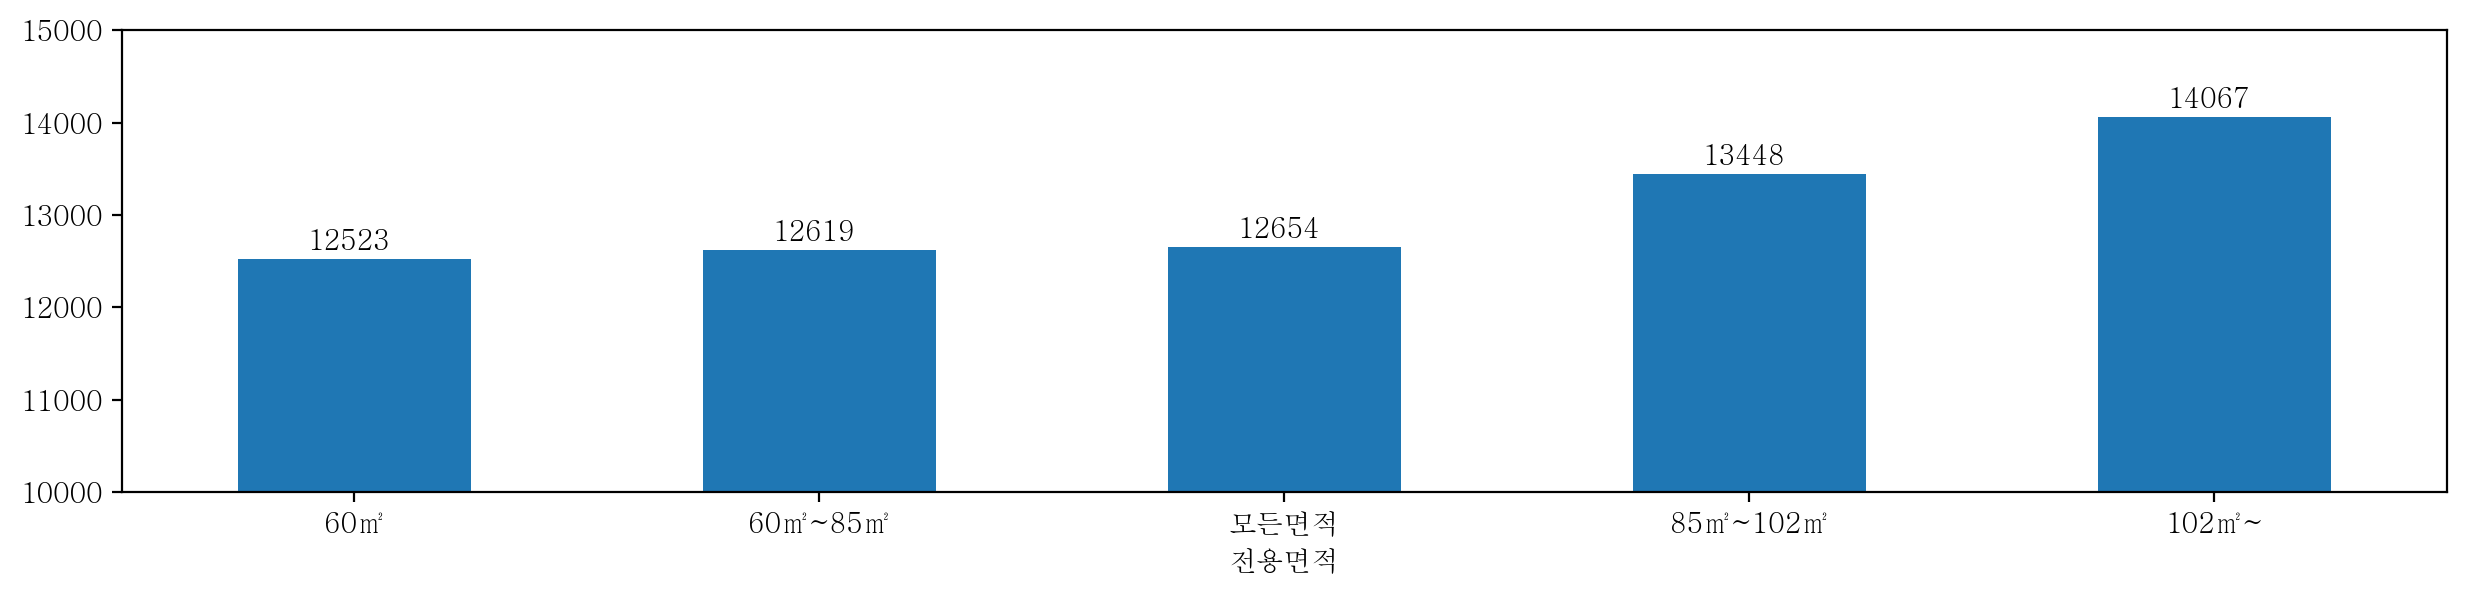

In [90]:
re = result.plot.bar(figsize = (15,3), rot = 0) # result.plot(kind = 'bar')
re.set_xlim()
re.set_ylim([10000, 15000])
# plt.text(0-0.1,round(result['60㎡'])+100,round(result['60㎡']))
for idx,val in enumerate(result) :
    #print(idx, key, val)
    plt.text(idx-0.1,round(val)+100,round(val))

## (4) 연도별 평균 평당분양가격(line)

In [93]:
for year, val in line_df.items() :
    print(year, val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105261
2020 13039.42244897959
2021 13636.022539682539
2022 14942.504494382021
2023 16890.92065677966
2024 18962.91923076923


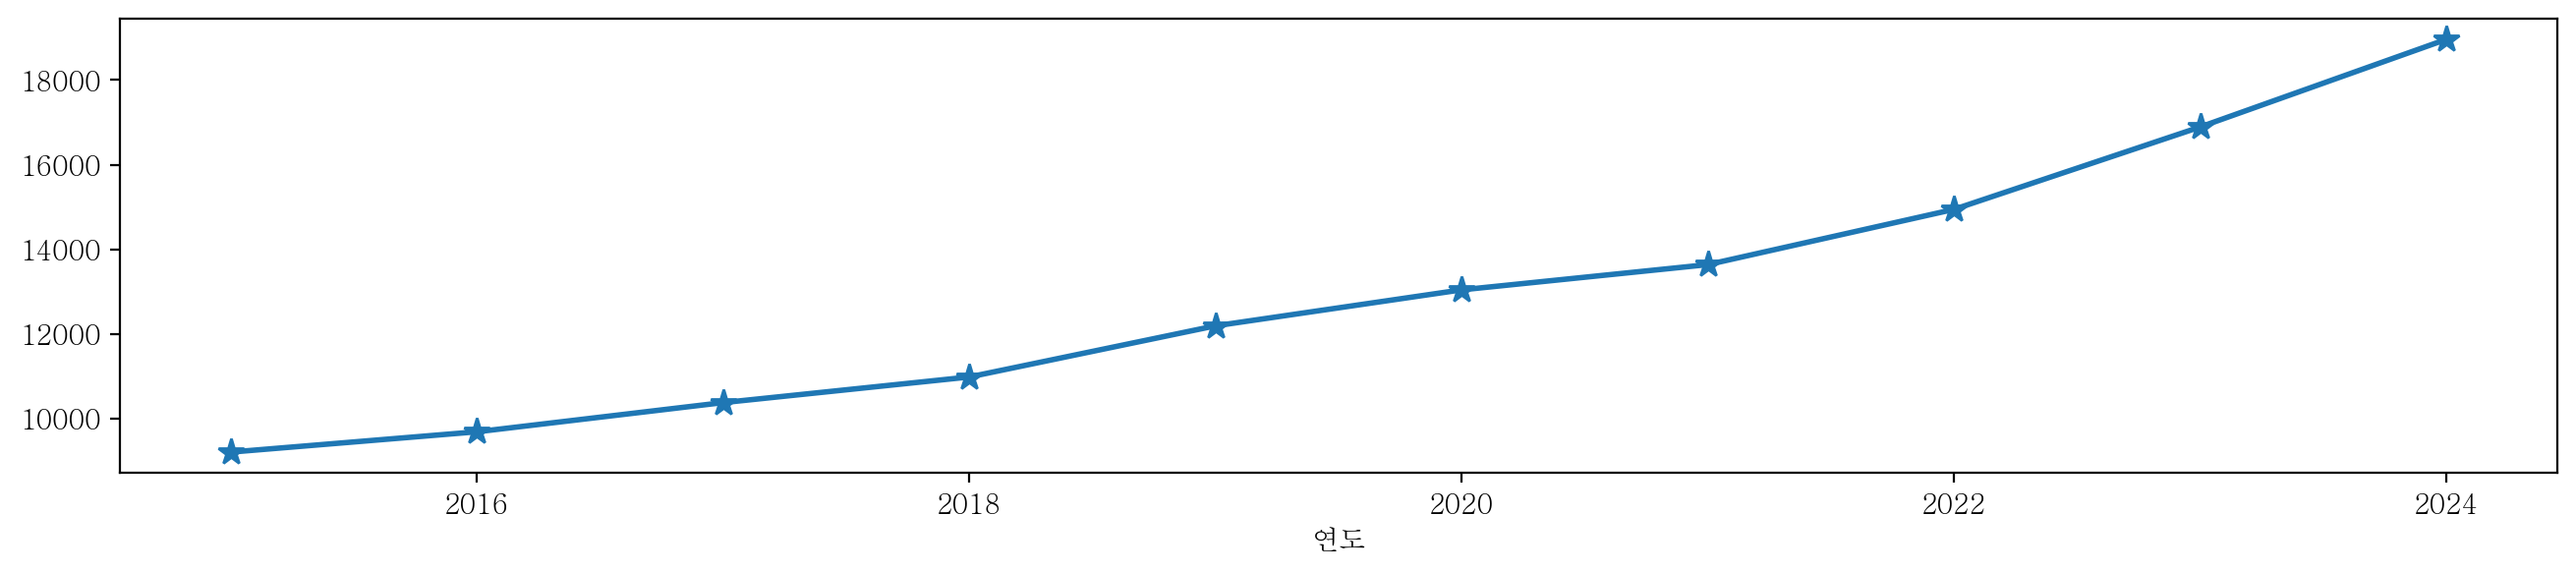

In [92]:
line_df = df_map.groupby('연도')['평당분양가격'].mean()
liner = line_df.plot.line(figsize=(16,3),linewidth=2, marker='*', markersize=10)

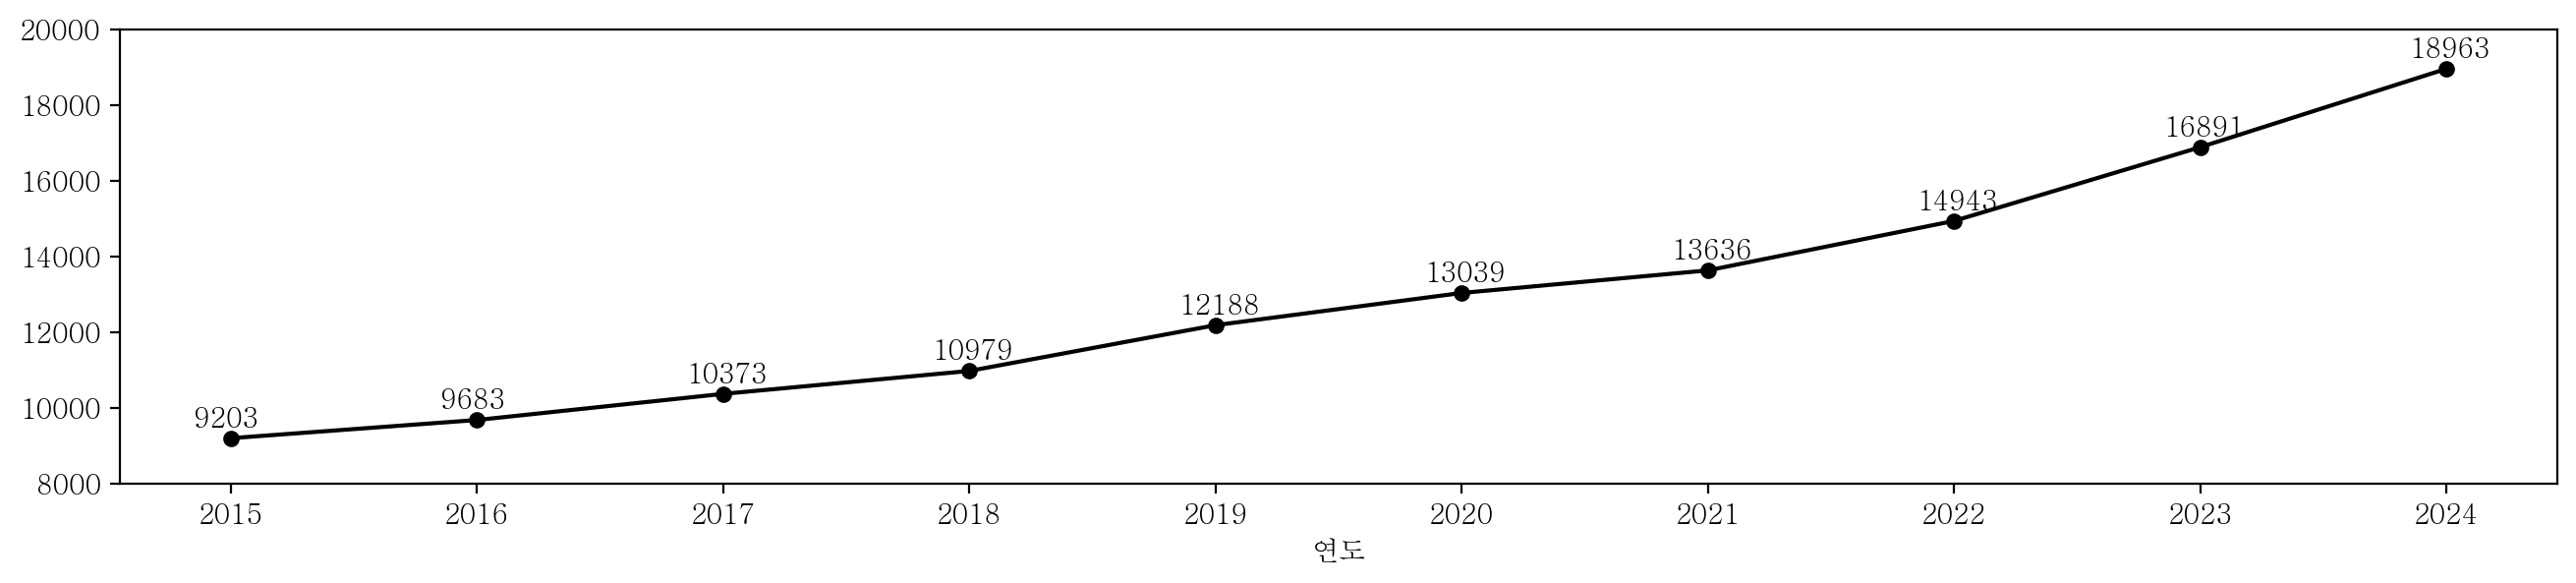

In [94]:
liner = line_df.plot.line(figsize=(16,3),linewidth=1.5, marker='o', markersize=5, color='k')
plt.ylim([8000,20000])
# plt.xlim([2015,2025]) # x축의 구간
plt.xticks(range(2015,2025))
for year, val in line_df.items() :
    plt.text(year - 0.15, round(val)+300, round(val))
plt.show()

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [95]:
sns.set(style='white', rc={'figure.figsize':(12,3)})
plt.rc('font', family='Batang') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

<Axes: xlabel='지역명', ylabel='평당분양가격'>

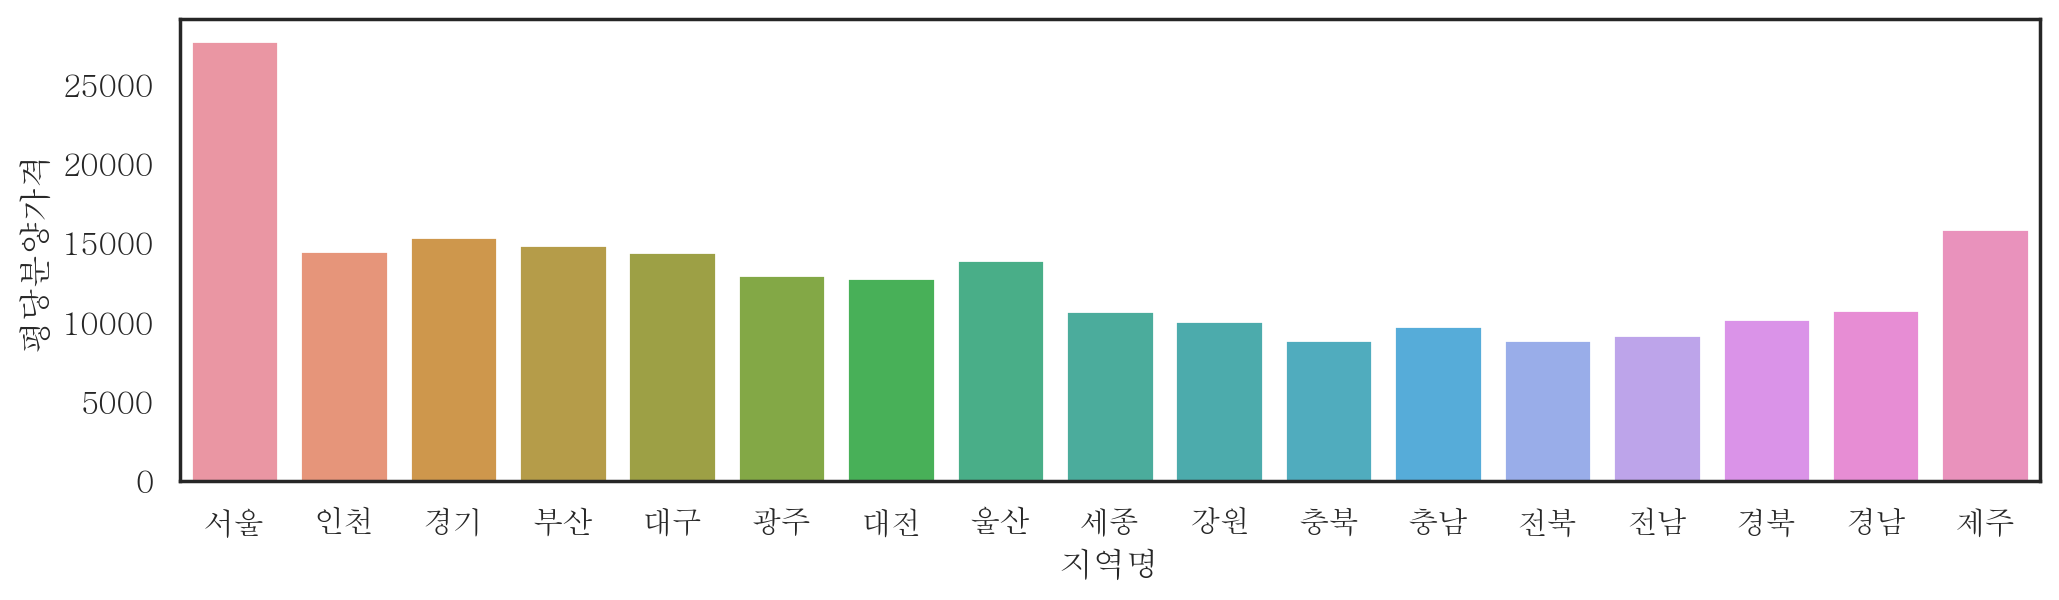

In [96]:
sns.barplot(data = df_map,
            x = '지역명',
            y = '평당분양가격',
            errorbar = None) # errorbar = 기본값 95% 신뢰구간, 'sd' :표준편차

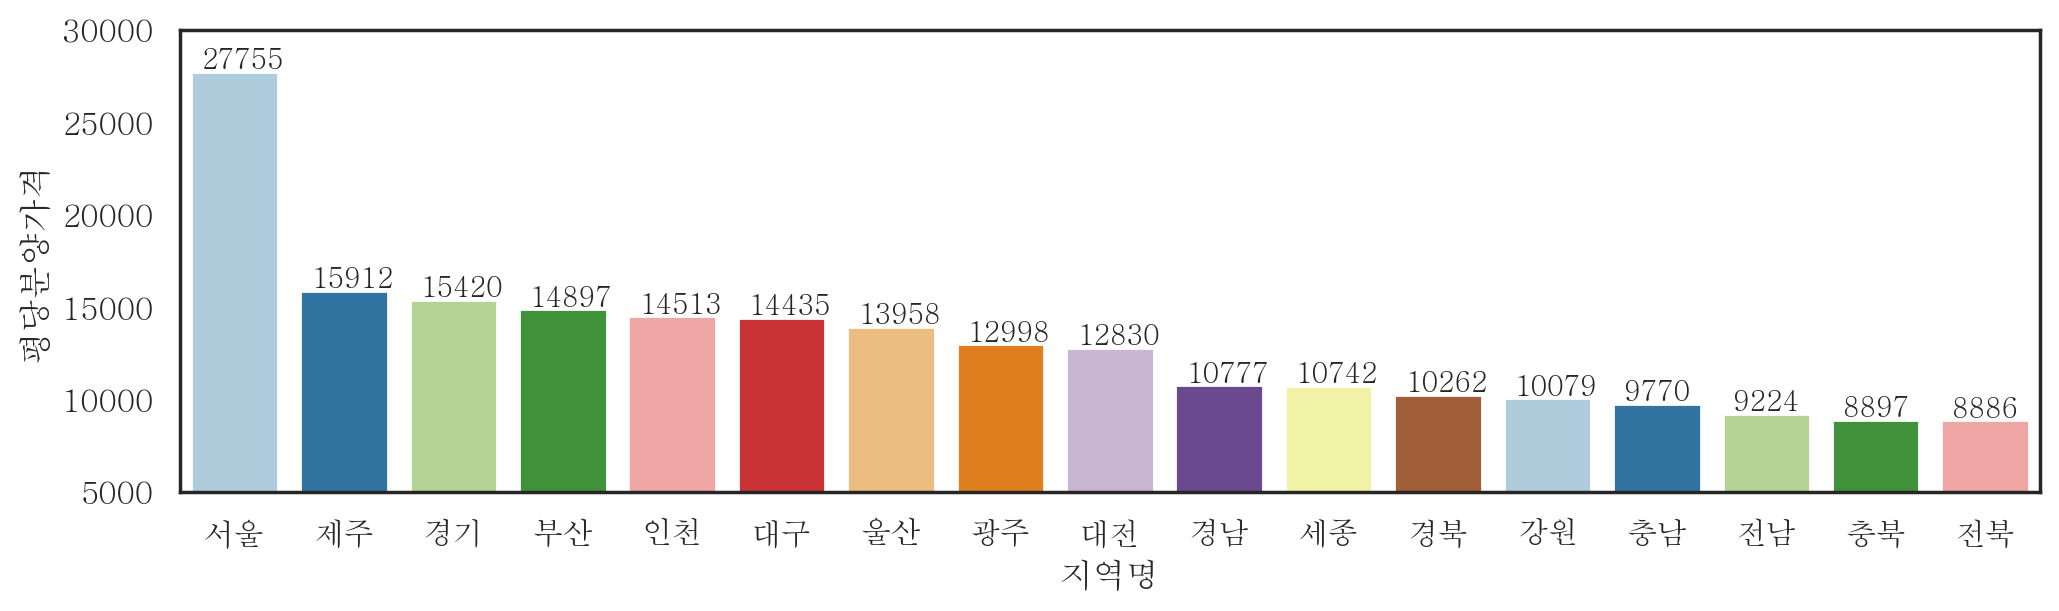

In [97]:
# 위의 barplot + sort + 값 annot
result = df_map.groupby('지역명')['평당분양가격'].mean().sort_values(ascending = False)
result.index
ax = sns.barplot(data = df_map,x='지역명',y='평당분양가격',
           order = result.index,
           errorbar = None,
           palette = 'Paired')
plt.ylim([5000,30000])
for idx, val in enumerate(result) :
    plt.text(idx-0.3,val+200,round(val), fontsize = 10)

In [98]:
for idx, val in enumerate(result) :
    print(idx, val)

0 27755.404554079694
1 15912.434624145786
2 15420.03028037383
3 14896.949155722325
4 14513.23220338983
5 14434.519999999999
6 13958.197974683544
7 12998.215999999999
8 12829.565060240964
9 10776.95581395349
10 10741.830806845965
11 10261.553424657533
12 10078.71739961759
13 9769.541279069766
14 9224.326627218934
15 8896.58330206379
16 8886.201923076924


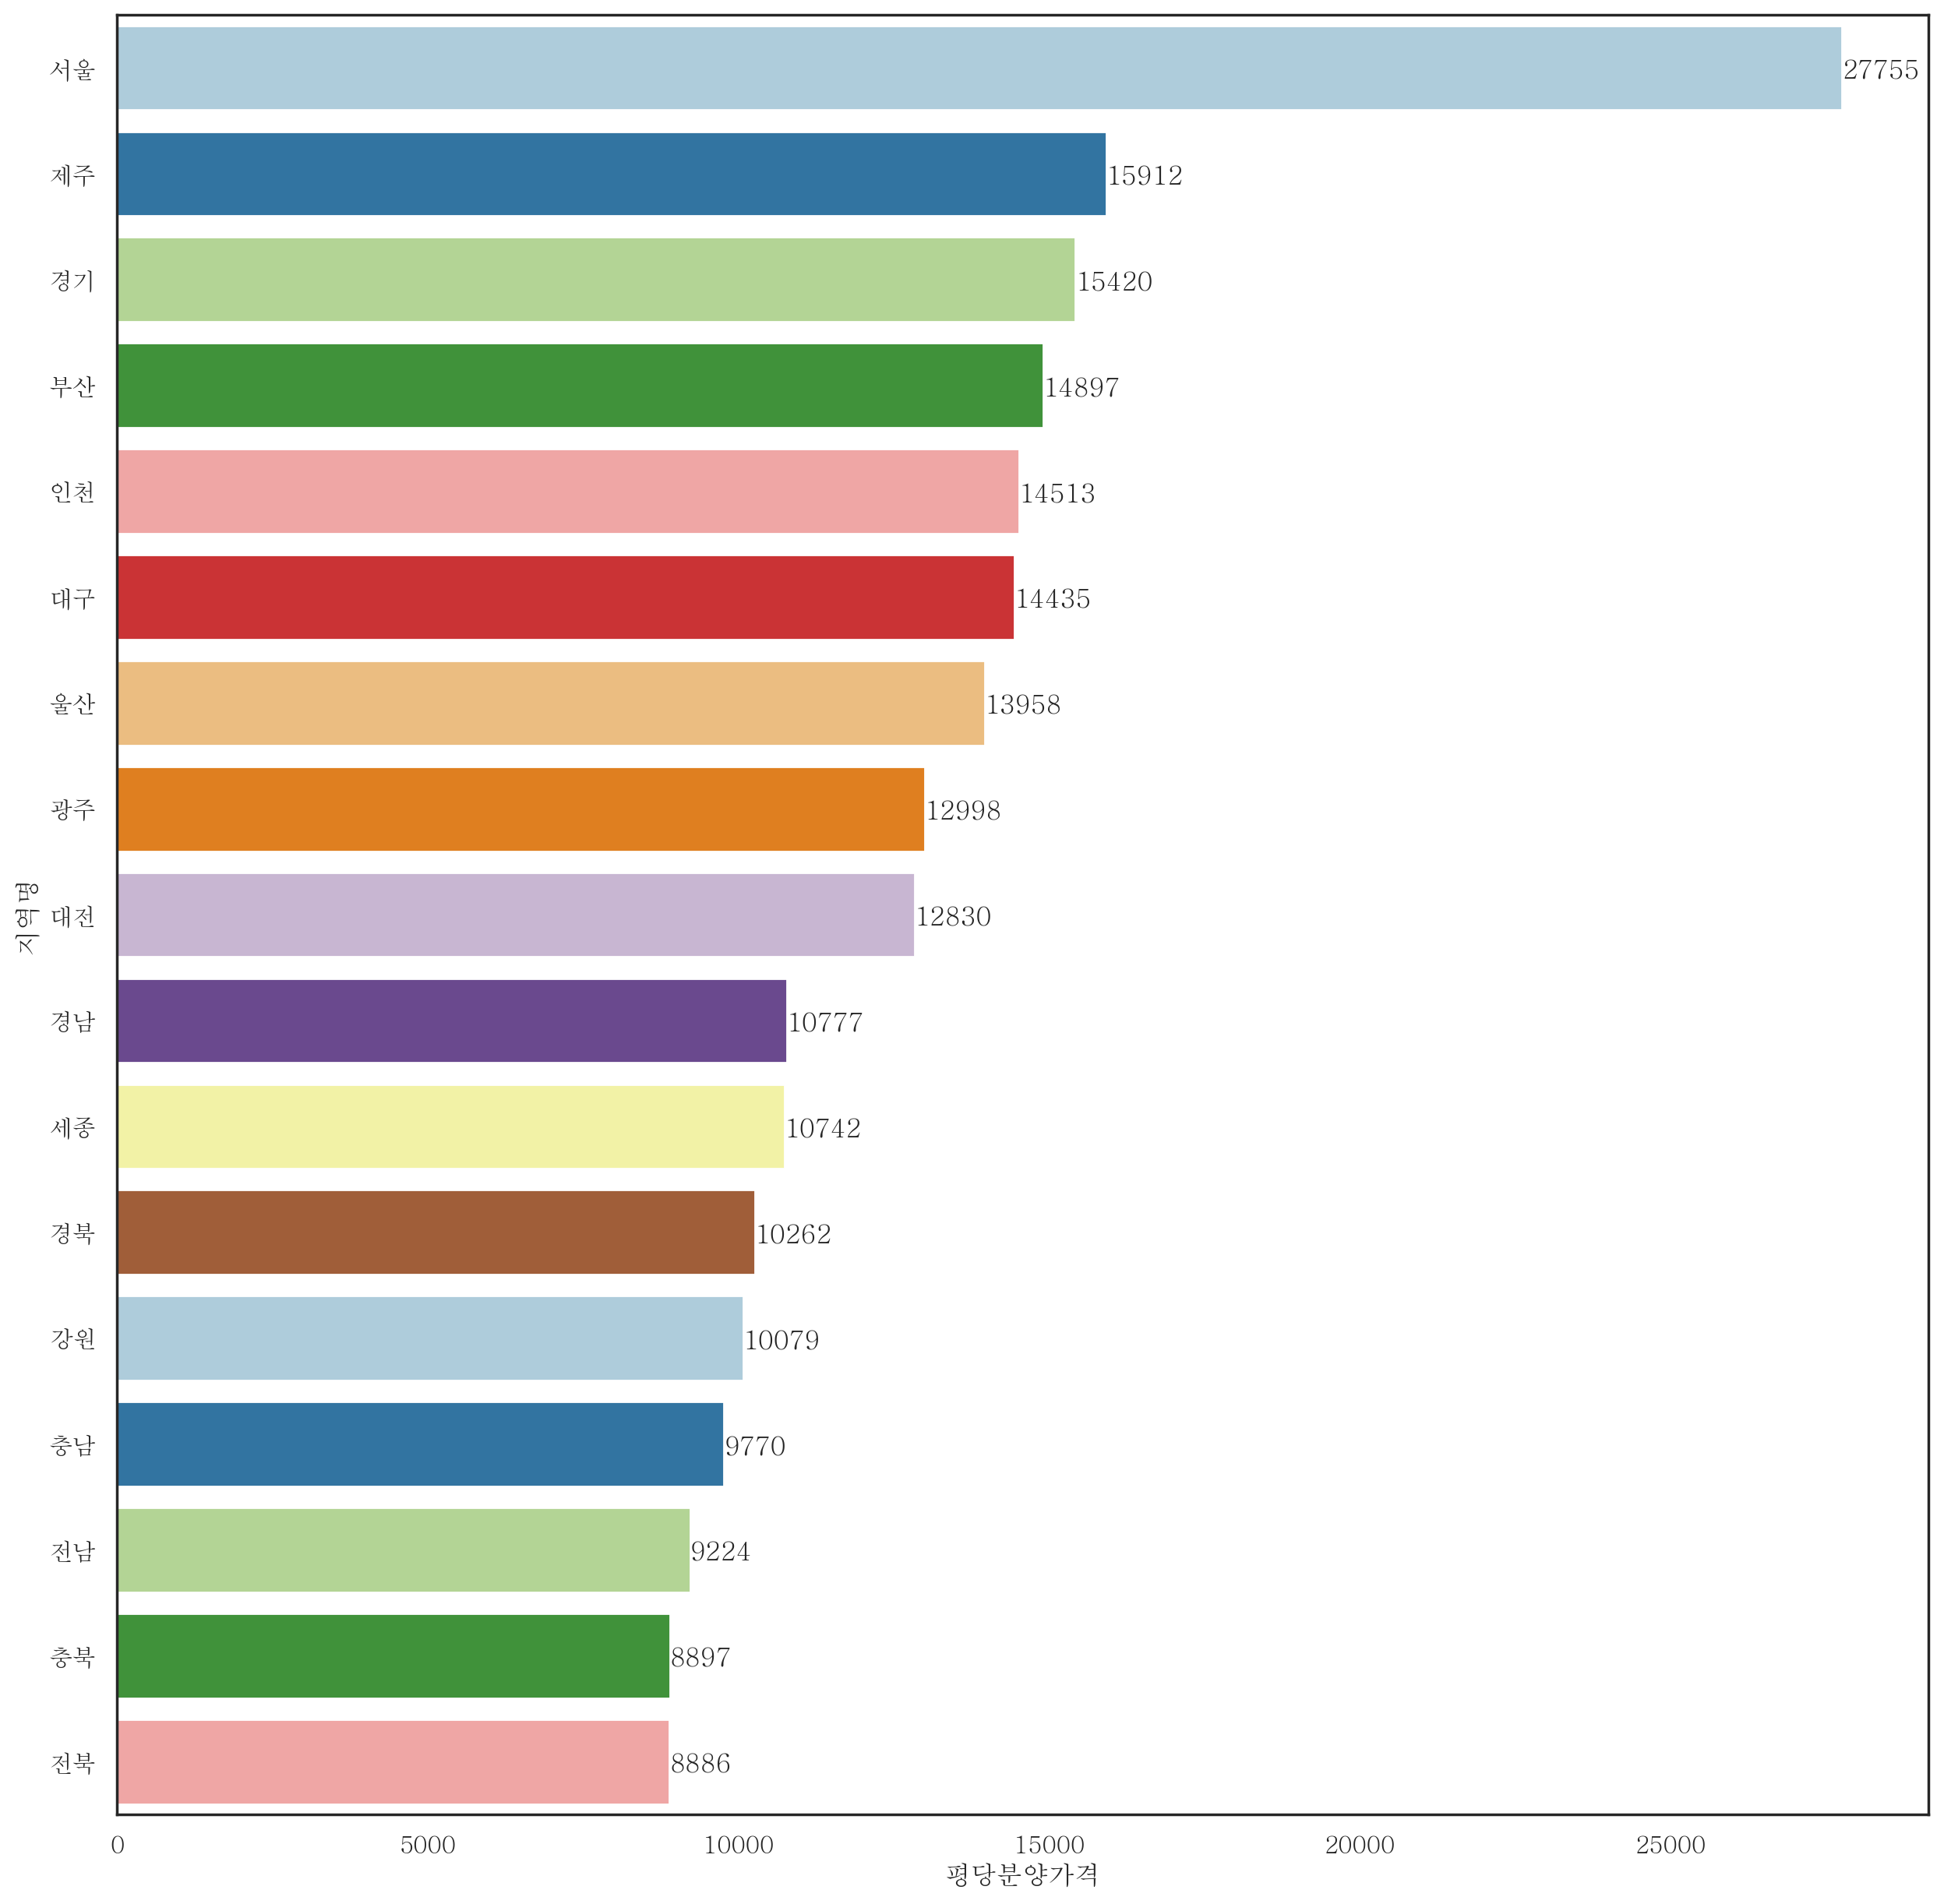

In [603]:
# 가로
# 위의 barplot + sort + 값 annot
result = df_map.groupby('지역명')['평당분양가격'].mean().sort_values(ascending = False)
plt.figure(figsize=(15,15))
result.index
ax = sns.barplot(data = df_map,y='지역명',x='평당분양가격',
           order = result.index,
           errorbar = None,
           palette = 'Paired')
for idx, val in enumerate(result) :
    plt.text(val,idx+0.1,round(val))

## (2) 연도별 평당분양가격

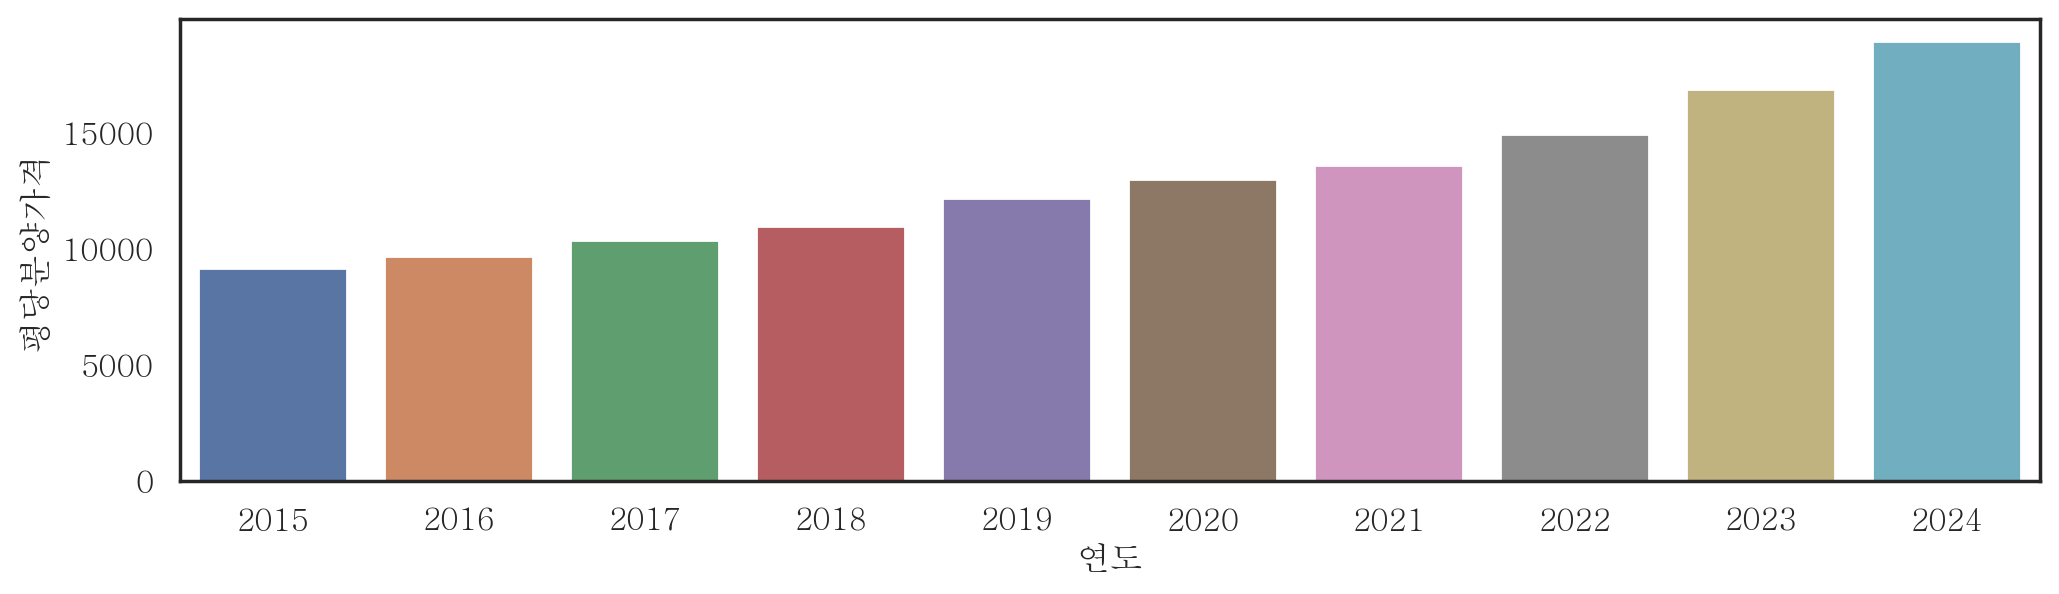

In [99]:
ax = sns.barplot(data = df_map, x = '연도', y = '평당분양가격', errorbar = None,)
# ax.text(0,10000,10000)
plt.show()

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

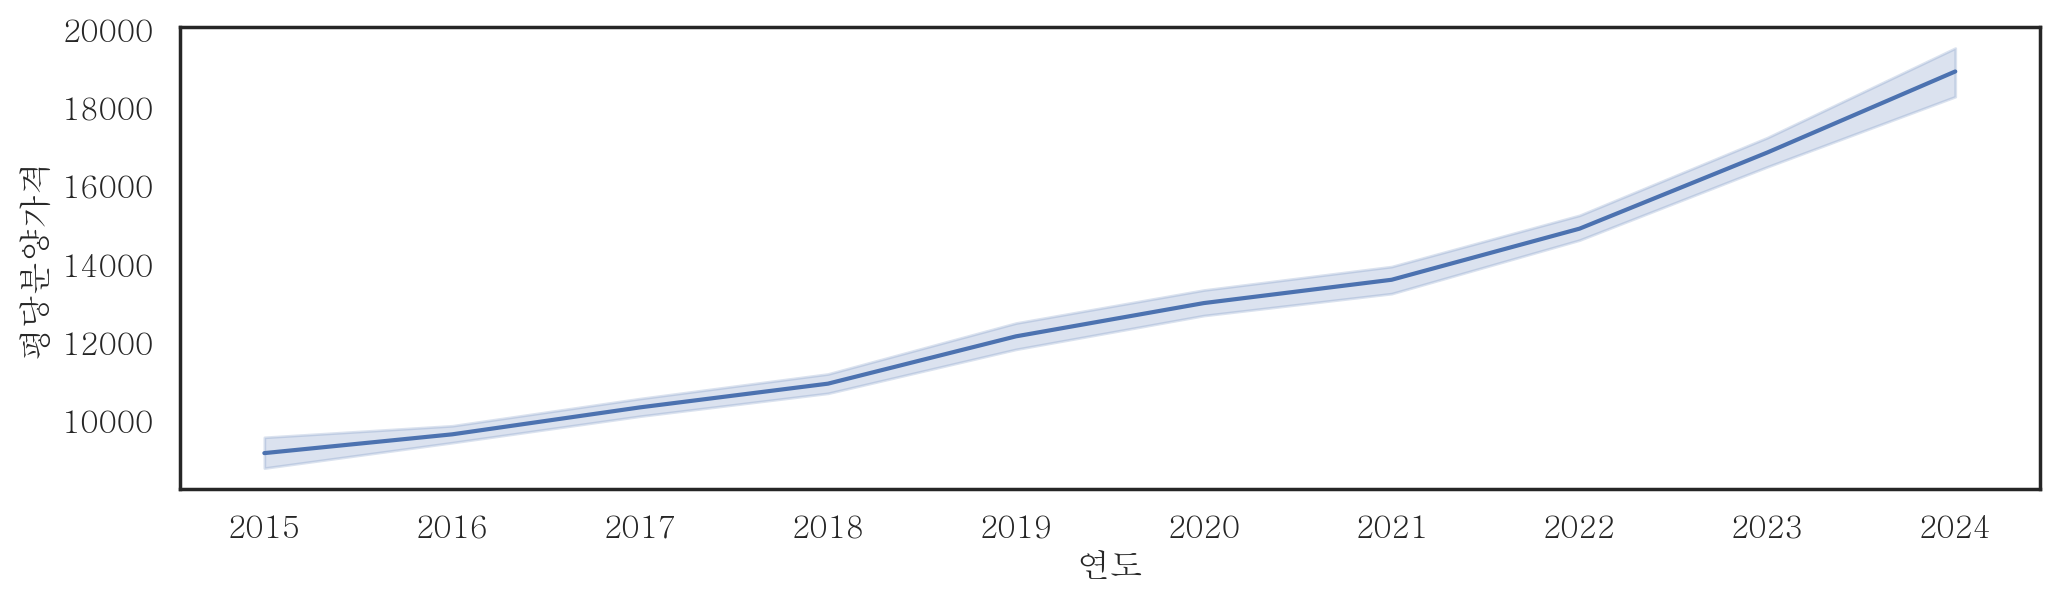

In [100]:
# 연도별 평당 분양 가격의 추이 => lineplot
sns.lineplot(data=df_map, x = '연도',y='평당분양가격')
plt.xticks(range(2015,2025))
plt.show()

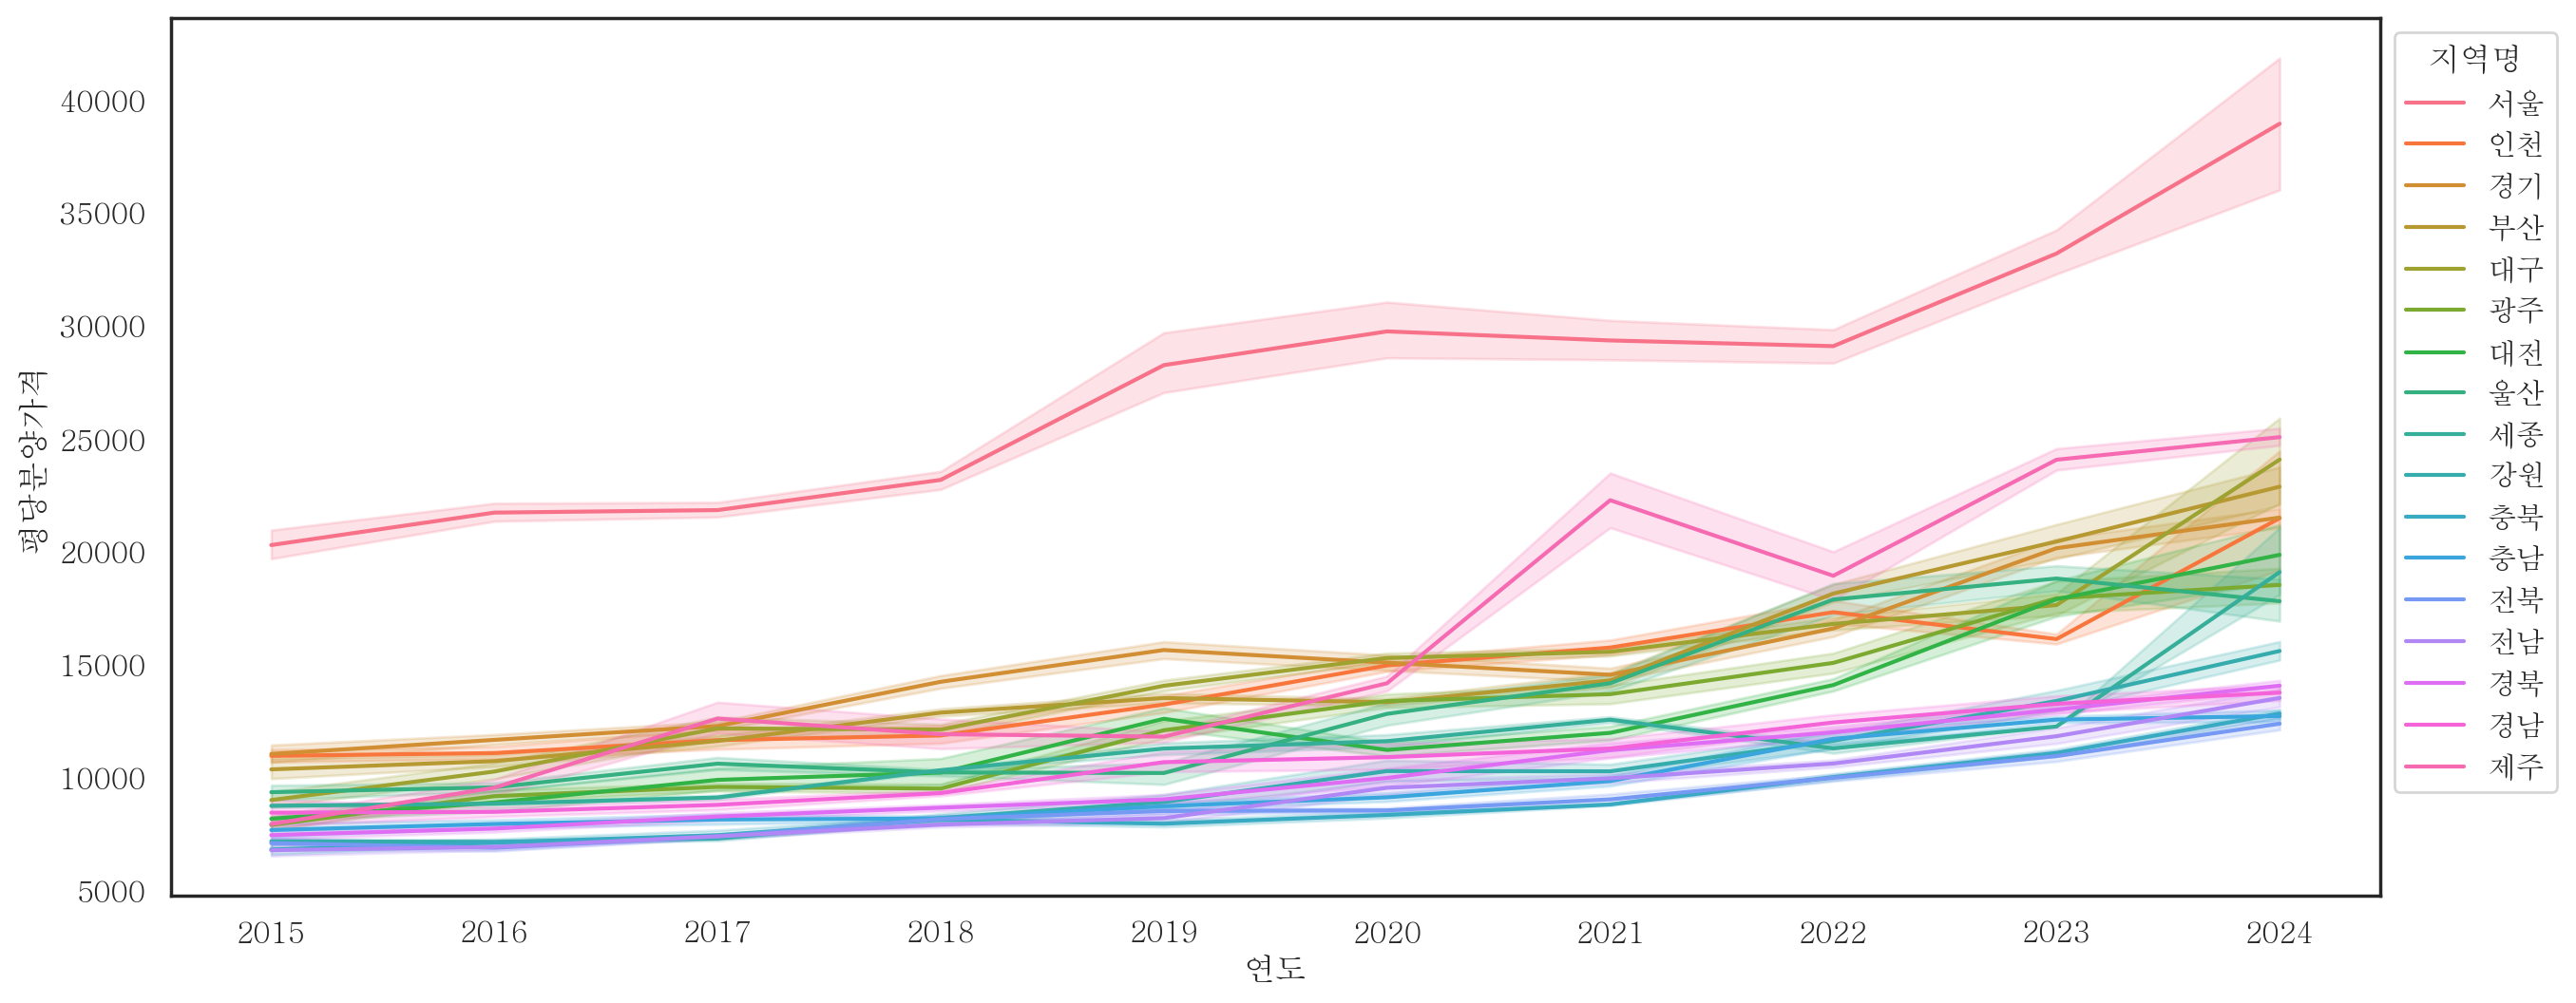

In [101]:
# 연도별 평당 분양 가격의 추이_ 지역별 lineplot
plt.figure(figsize=(15,6))
ab = sns.lineplot(data=df_map, x = '연도',y='평당분양가격',hue = '지역명')
plt.xticks(range(2015,2025))
sns.move_legend(ab, "upper left", bbox_to_anchor=(1, 1))
plt.show()

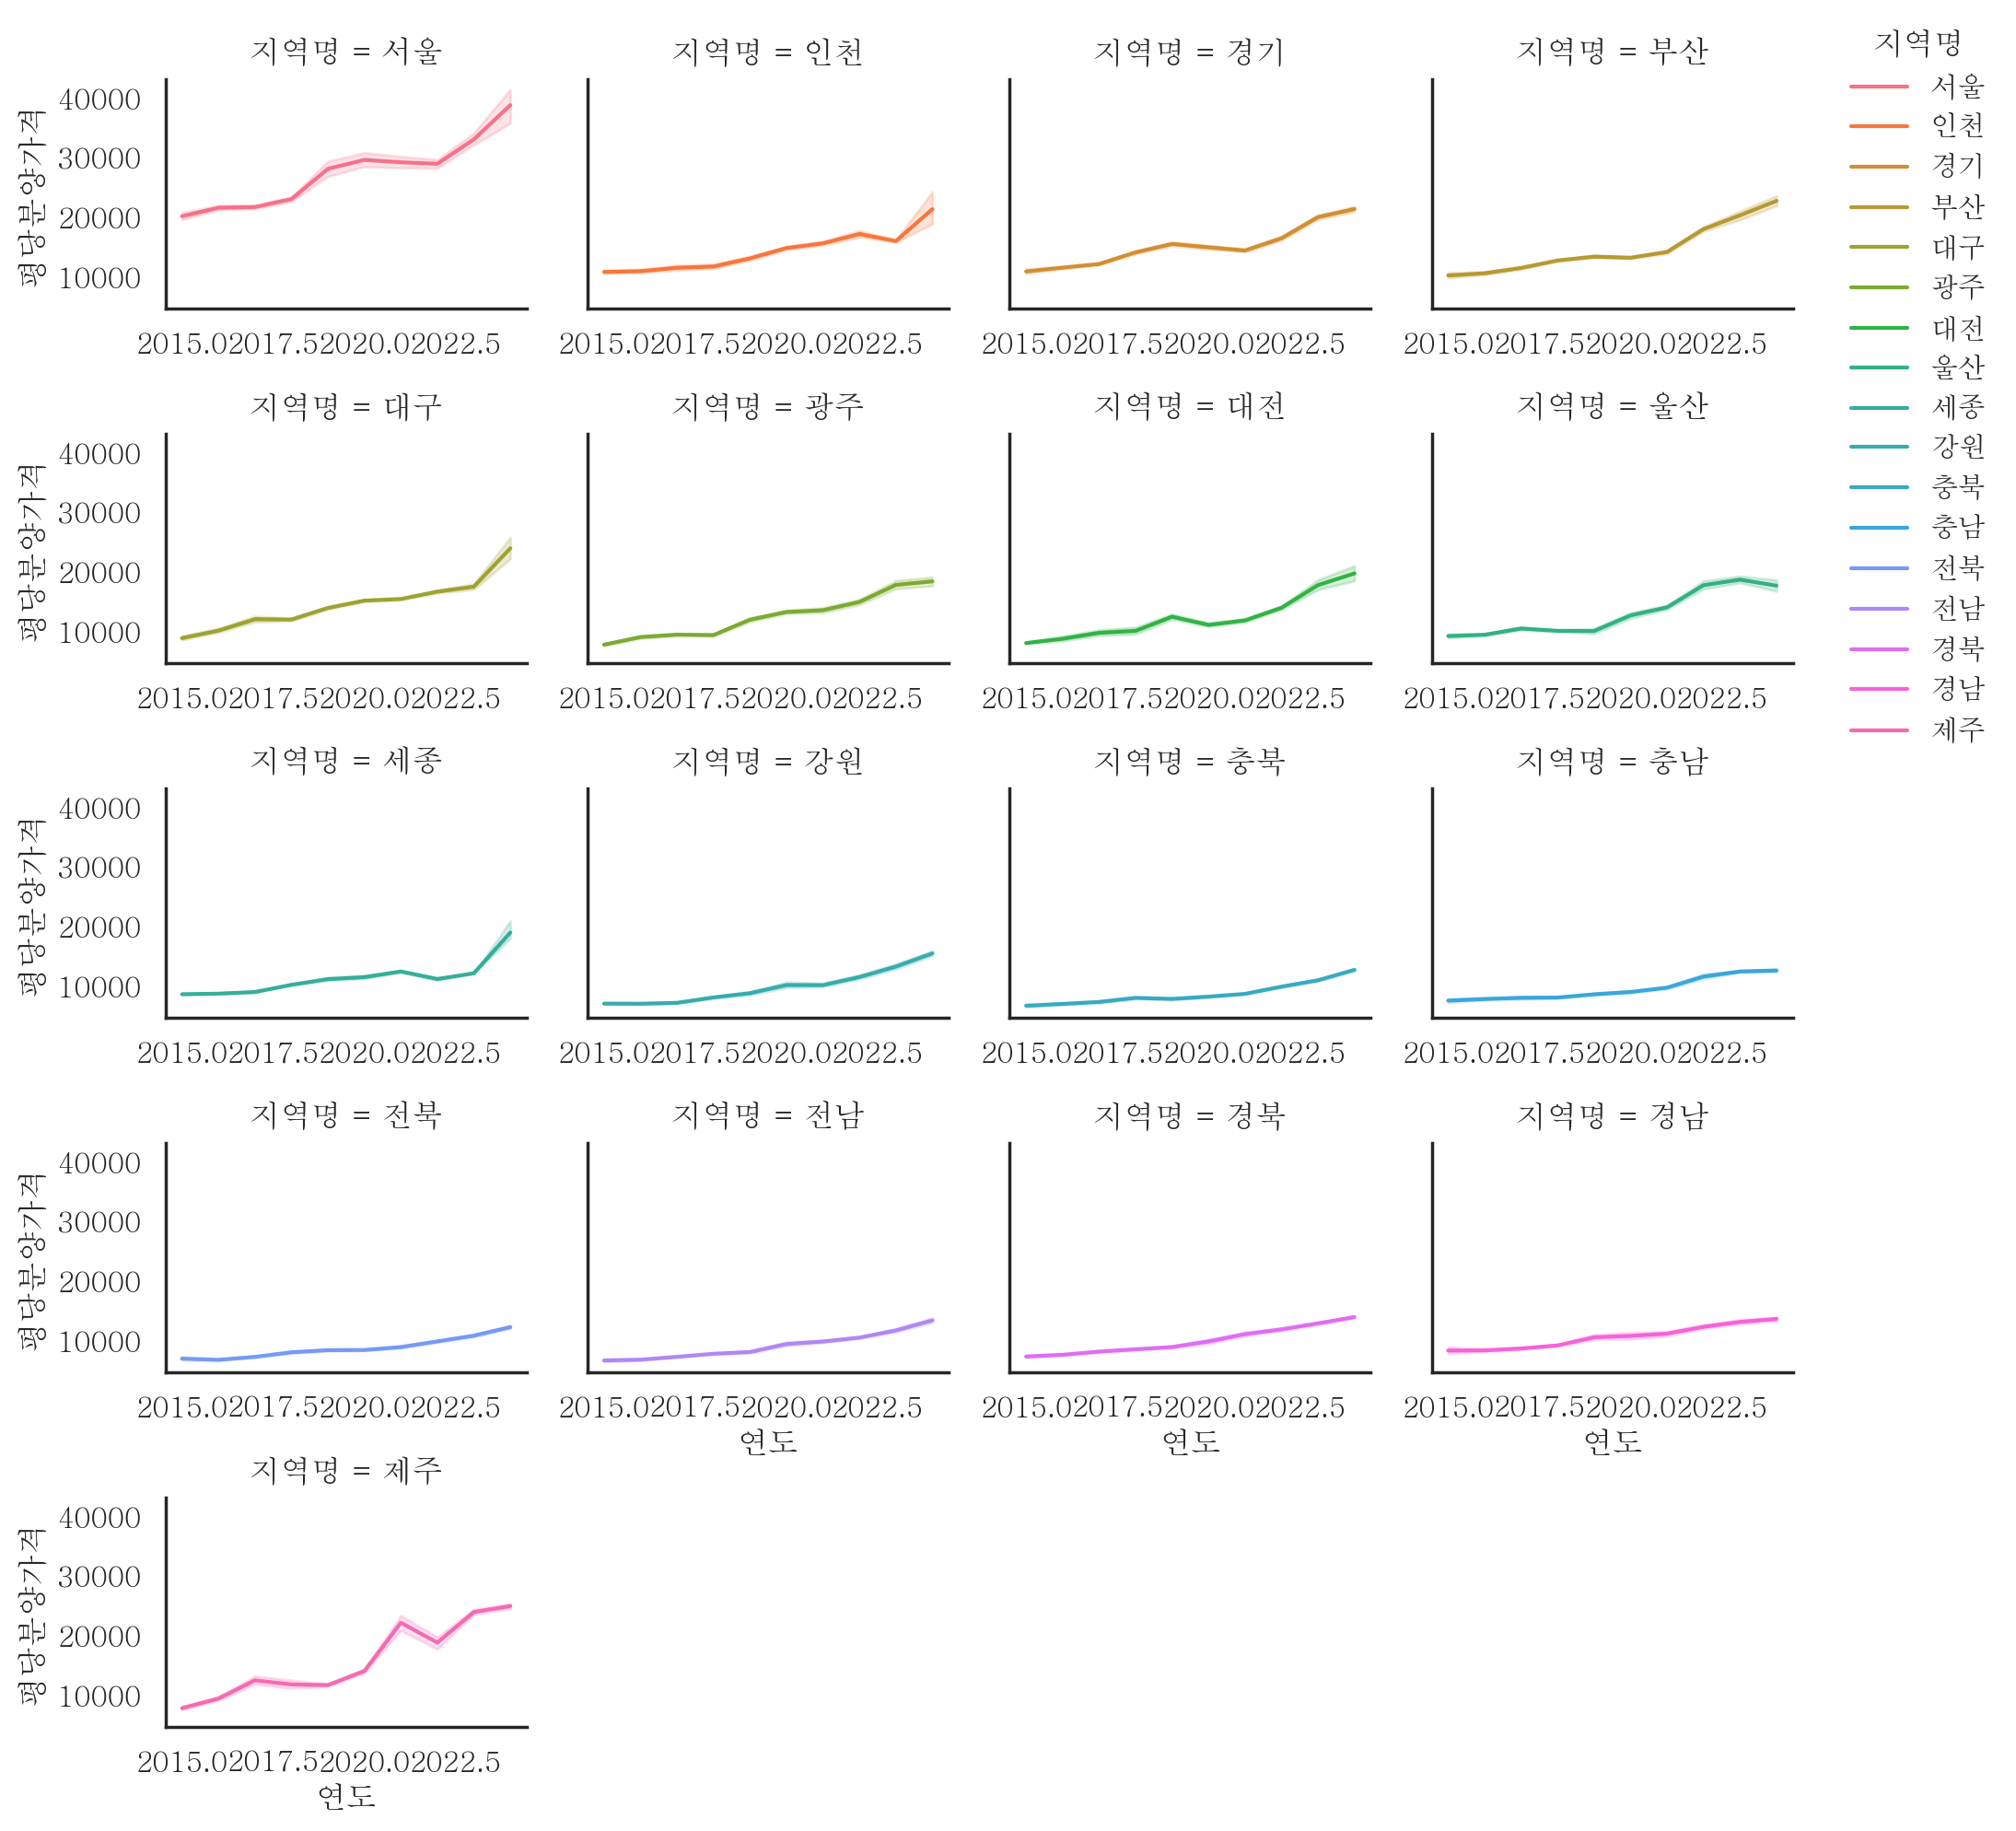

In [102]:
# 연도별 평당 분양 가격의 추이_ 지역별 서브플롯 lineplot => relplot
ax = sns.relplot(data = df_map, x = '연도', y = '평당분양가격', hue = '지역명', kind = 'line', col = '지역명', col_wrap=4, facet_kws = {'sharex' : False, 'sharey' : True})
ax.fig.set_size_inches(10,10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout() # 서브플롯 레이아웃 타이트하게 조정

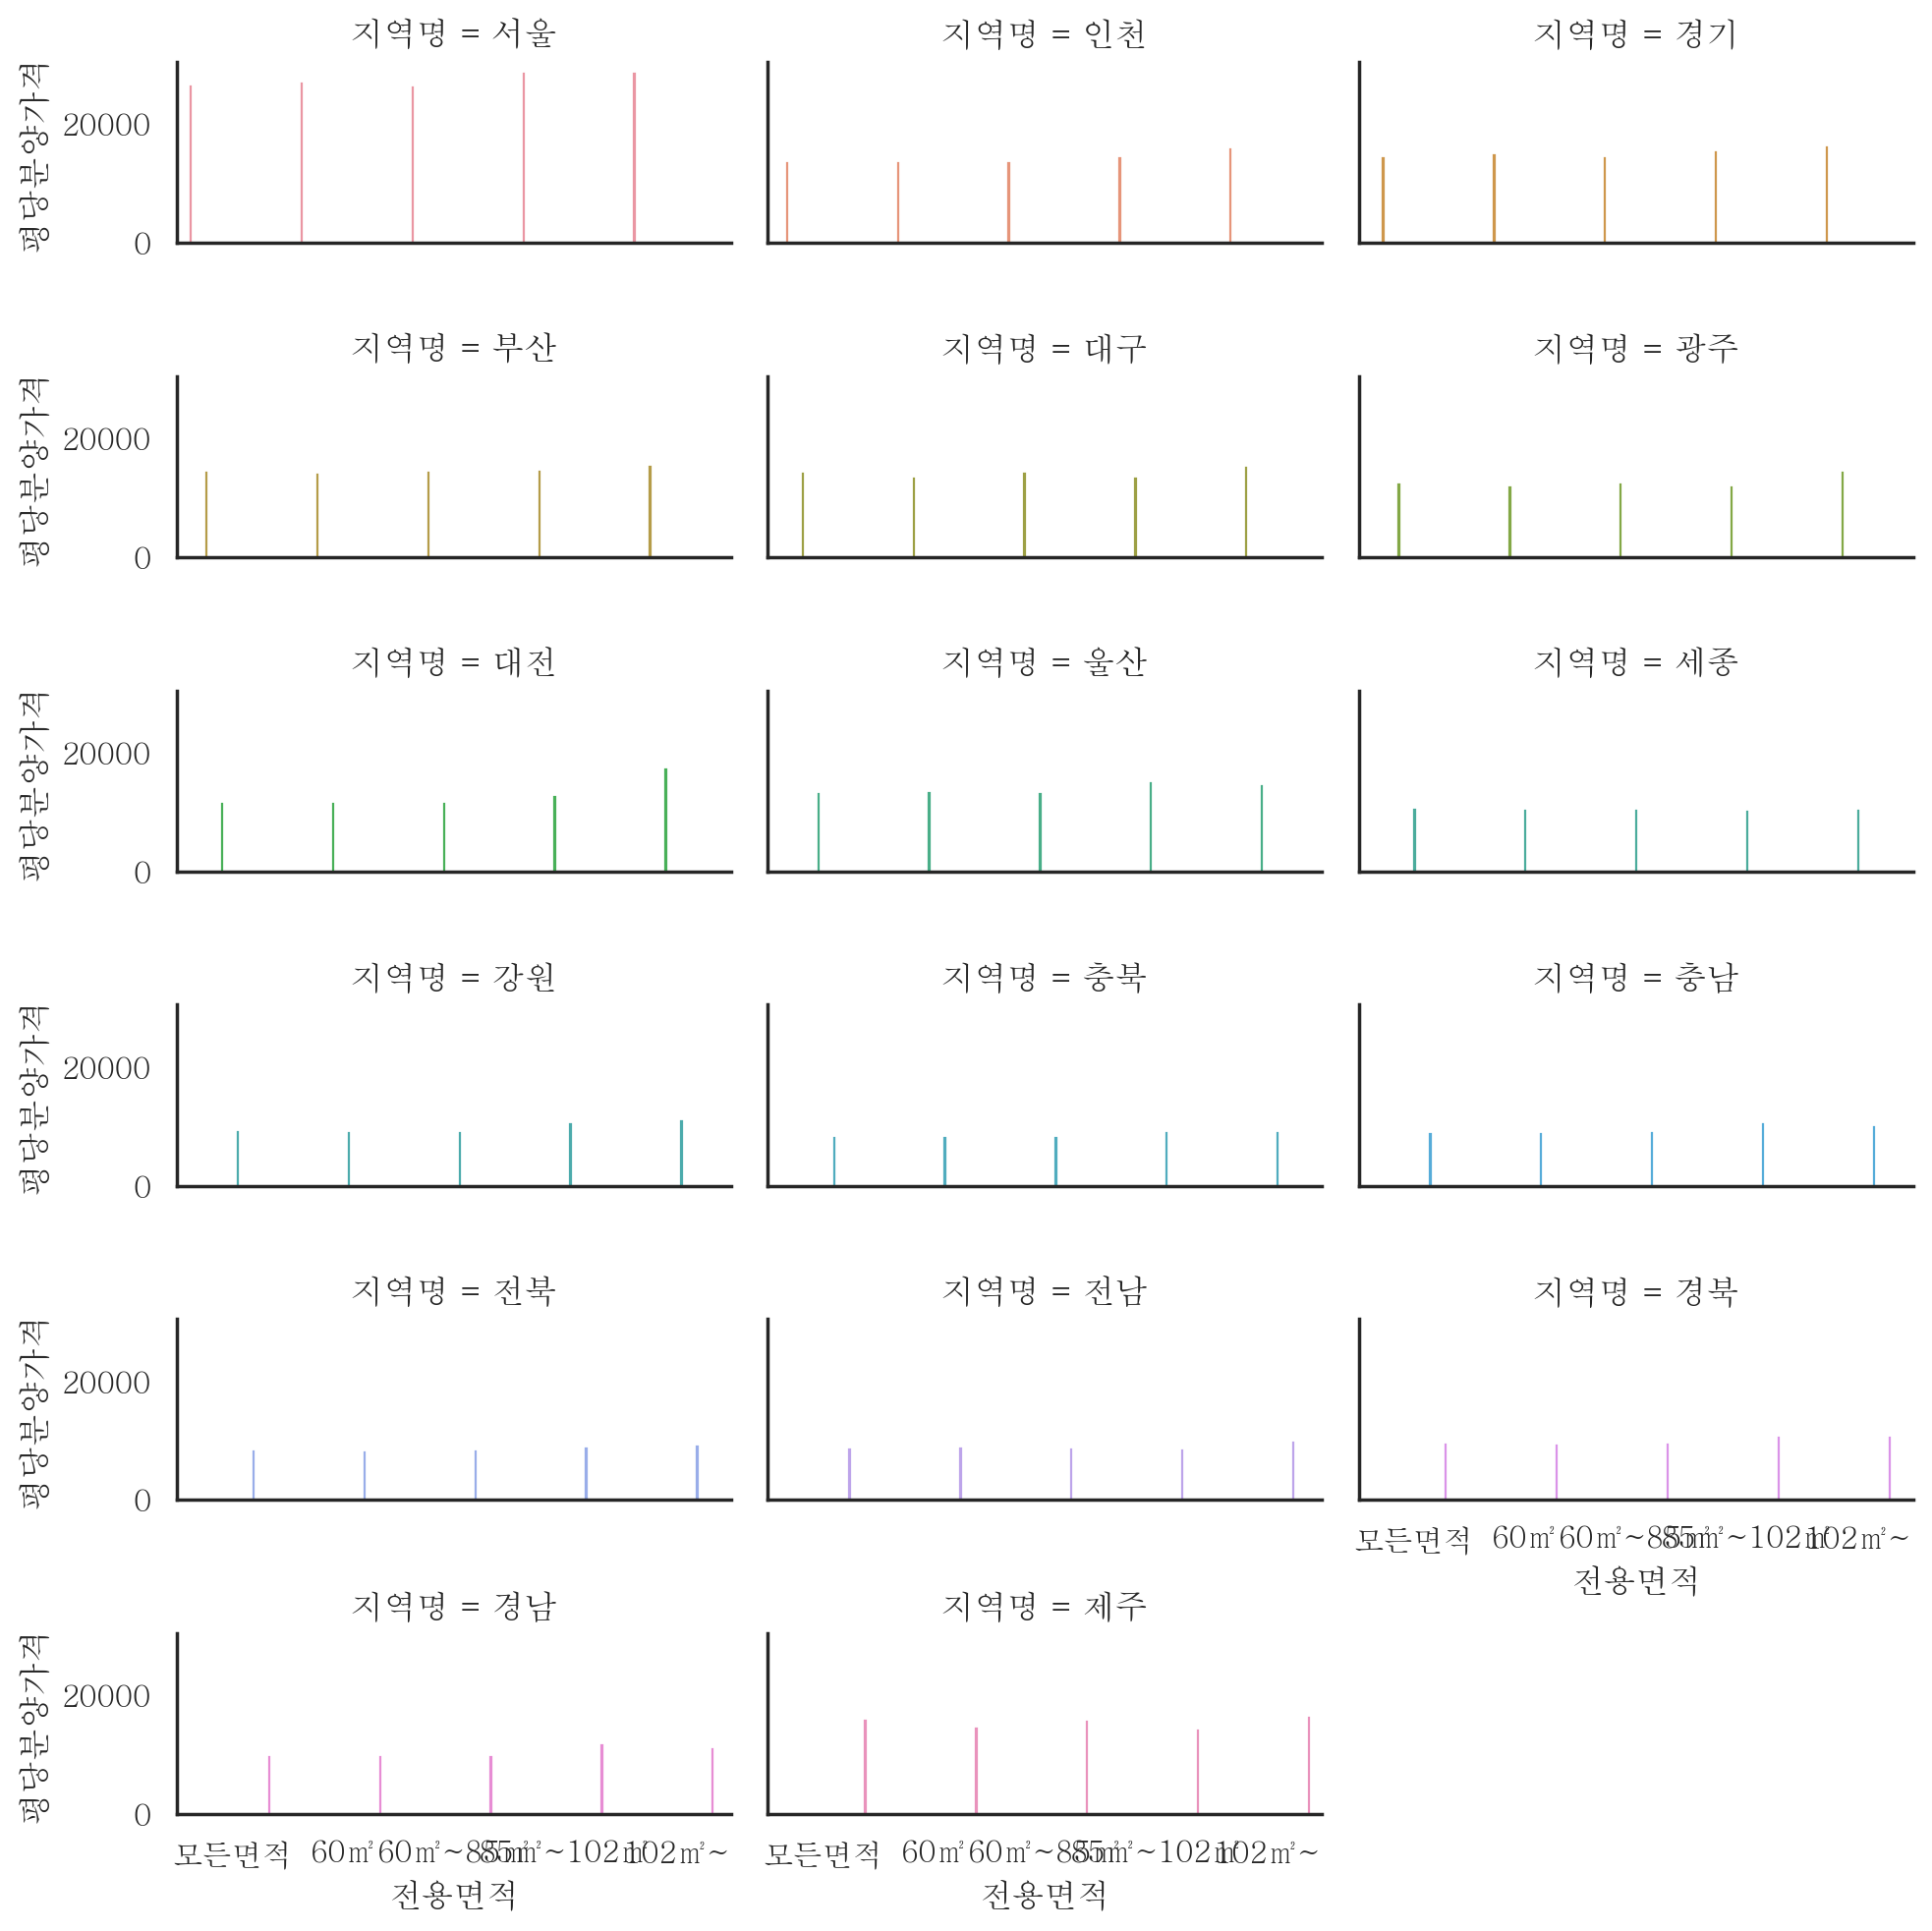

In [648]:
# 연도별 평당 분양 가격의 추이_ 지역별 서브플롯 barplot => catplot
ax = sns.catplot(data = df_map, x = '전용면적', y = '평당분양가격', hue = '지역명', kind = 'bar', col = '지역명', col_wrap=3, errorbar = None)
ax.fig.set_size_inches(10,10)
plt.tight_layout() # 서브플롯 레이아웃 타이트하게 조정

<Axes: xlabel='연도', ylabel='평당분양가격'>

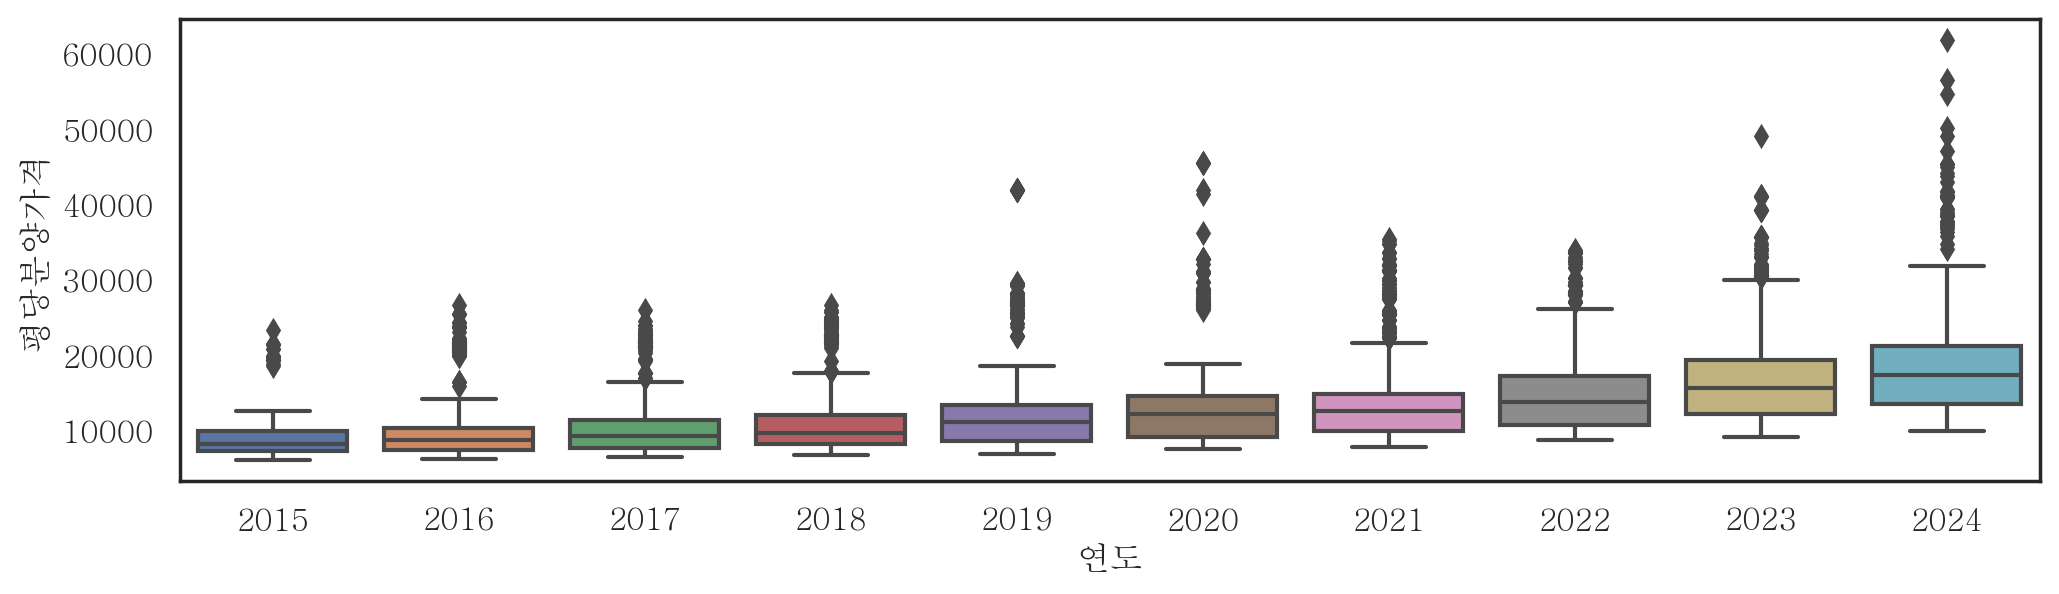

In [103]:
# boxplot으로 이상치 보기
sns.boxplot(data = df_map, x = '연도',y='평당분양가격') 

<Axes: xlabel='연도', ylabel='평당분양가격'>

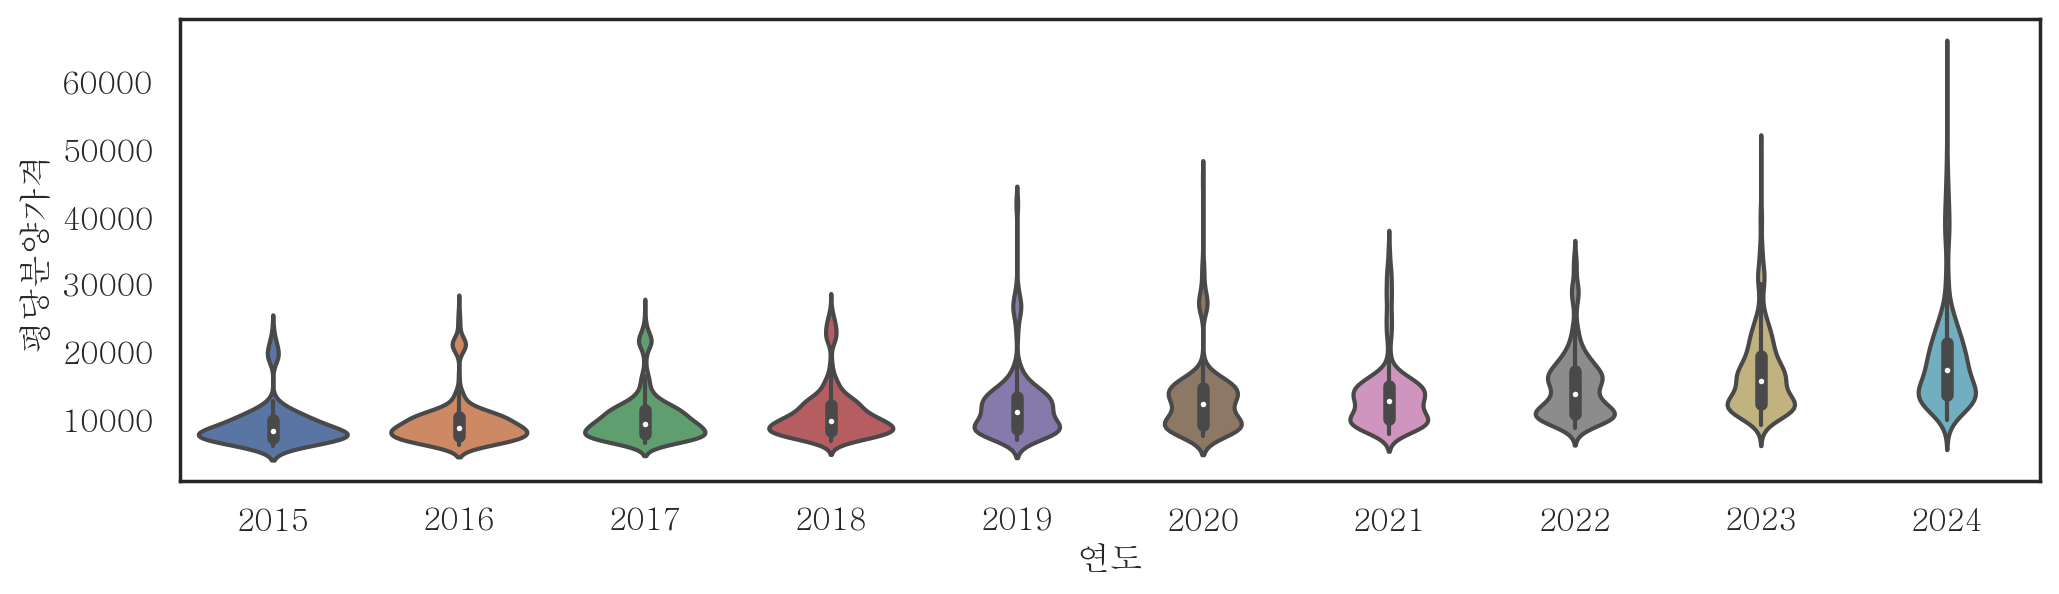

In [104]:
# violinplot => 이상치, 중위수 근처의 밀도 보기 가능(값 체크가 아니라 시각화)
sns.violinplot(data = df_map, x = '연도',y='평당분양가격') 

<Axes: xlabel='연도', ylabel='평당분양가격'>

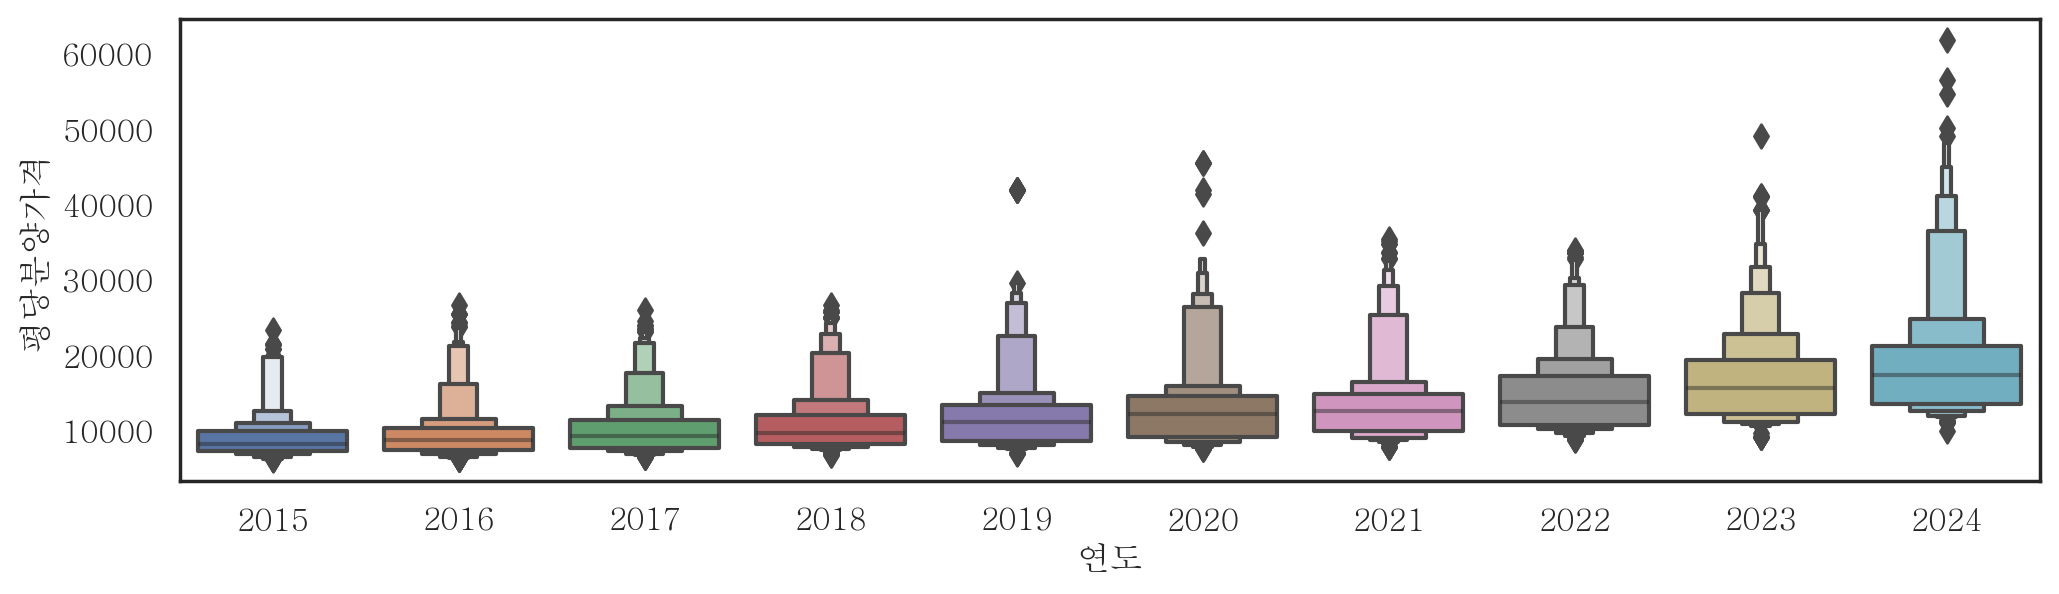

In [105]:
# boxenplot => 이상치, 중위수 근처의 밀도를 색으로 보기 가능(값 체크가 아니라 시각화)
sns.boxenplot(data = df_map, x = '연도',y='평당분양가격') 

### =5월8일 사전 세팅=

In [170]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import warnings

%config InlineBackend.figure_format = "retina" # 그래프 선명도
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')
sns.set(style = 'darkgrid', rc = {'figure.figsize' :(15,3)}) # sns 기본 세팅
plt.rc('font', family='Batang') # 폰트 설정

warnings.filterwarnings(action='ignore') # 경고 메세지 무시
df_last = pd.read_csv('data/df_last.csv')

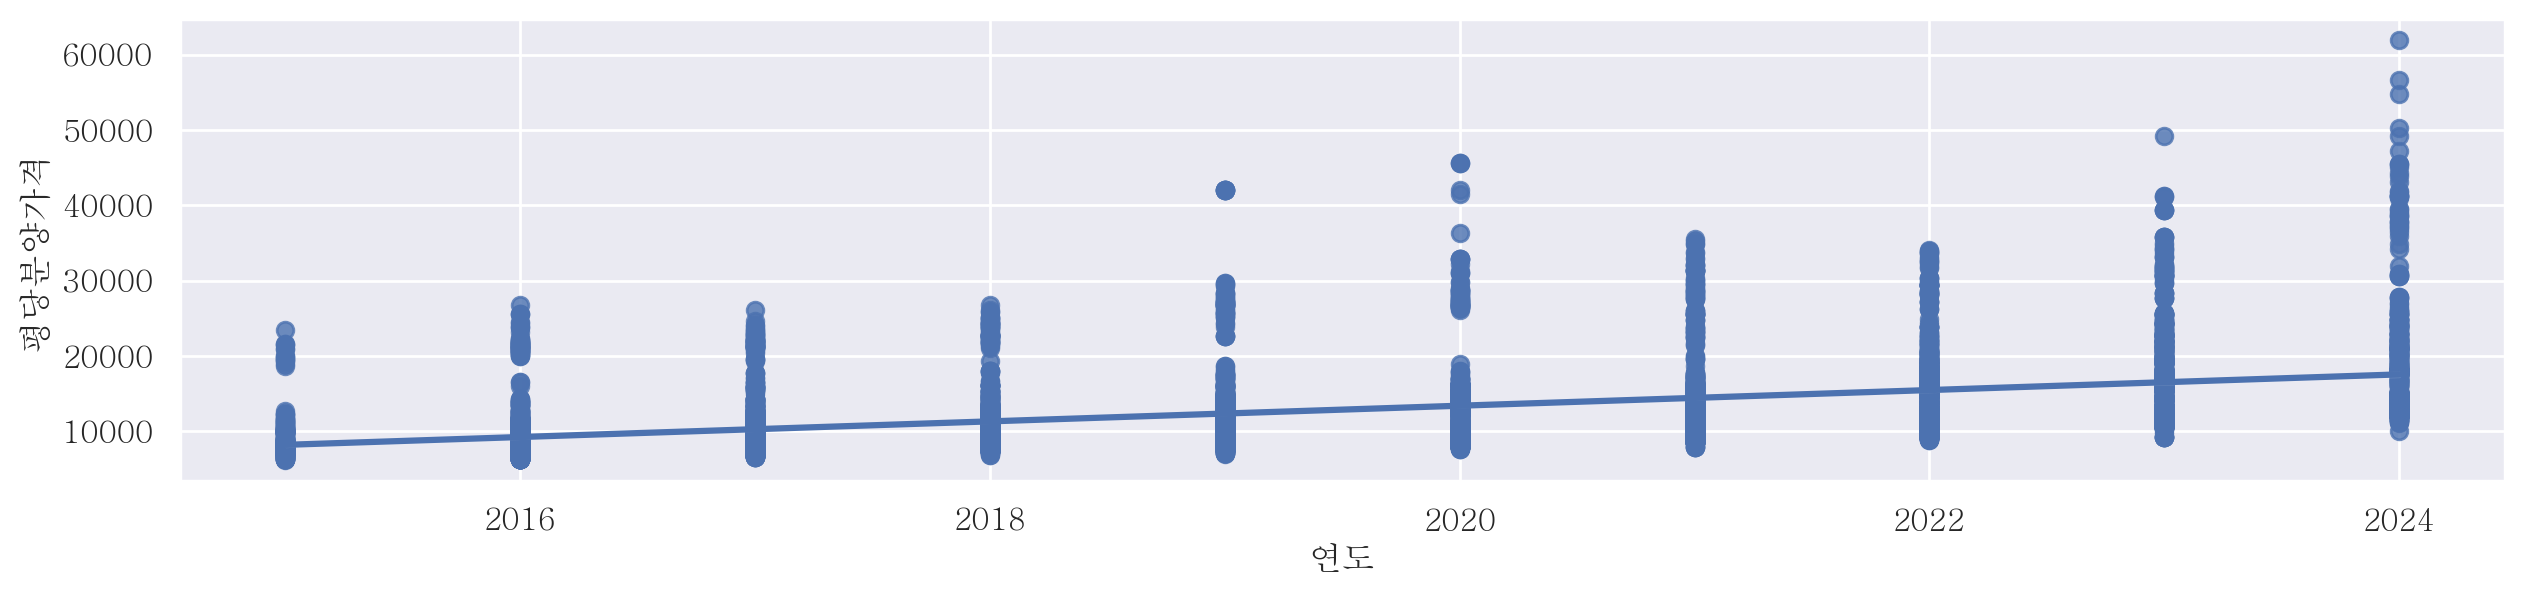

In [131]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화 : regplot
sns.regplot(data = df_map, x = '연도', y = '평당분양가격') # hue X
plt.show()

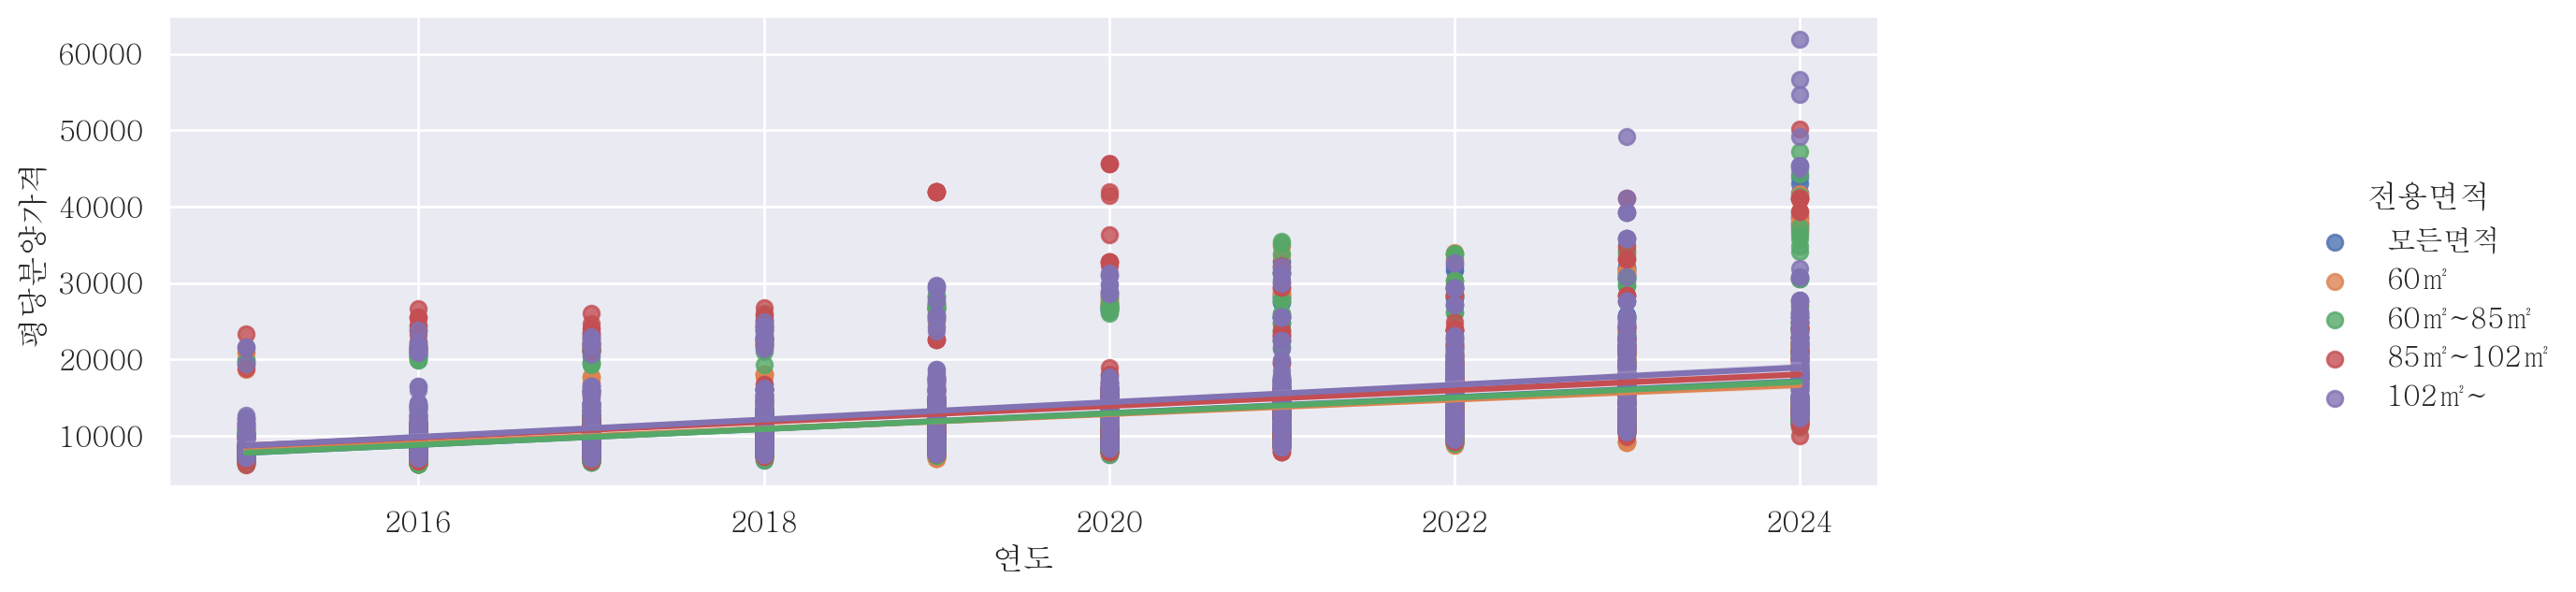

In [142]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화 : regplot => lmplot
ax = sns.lmplot(data = df_map, x = '연도', y = '평당분양가격', hue = '전용면적') # hue X
ax.fig.set_size_inches(16,3)
plt.show()

In [140]:
%%time
# 분포를 나타내는 swarmpplot
# 모든 점을 나타내는 산점도로 실행에 시간이 많이 요함
sns.swarmplot(data = df_map, x = '연도', y = '평당분양가격', hue = '전용면적')
plt.show()

CPU times: total: 0 ns
Wall time: 0 ns


3

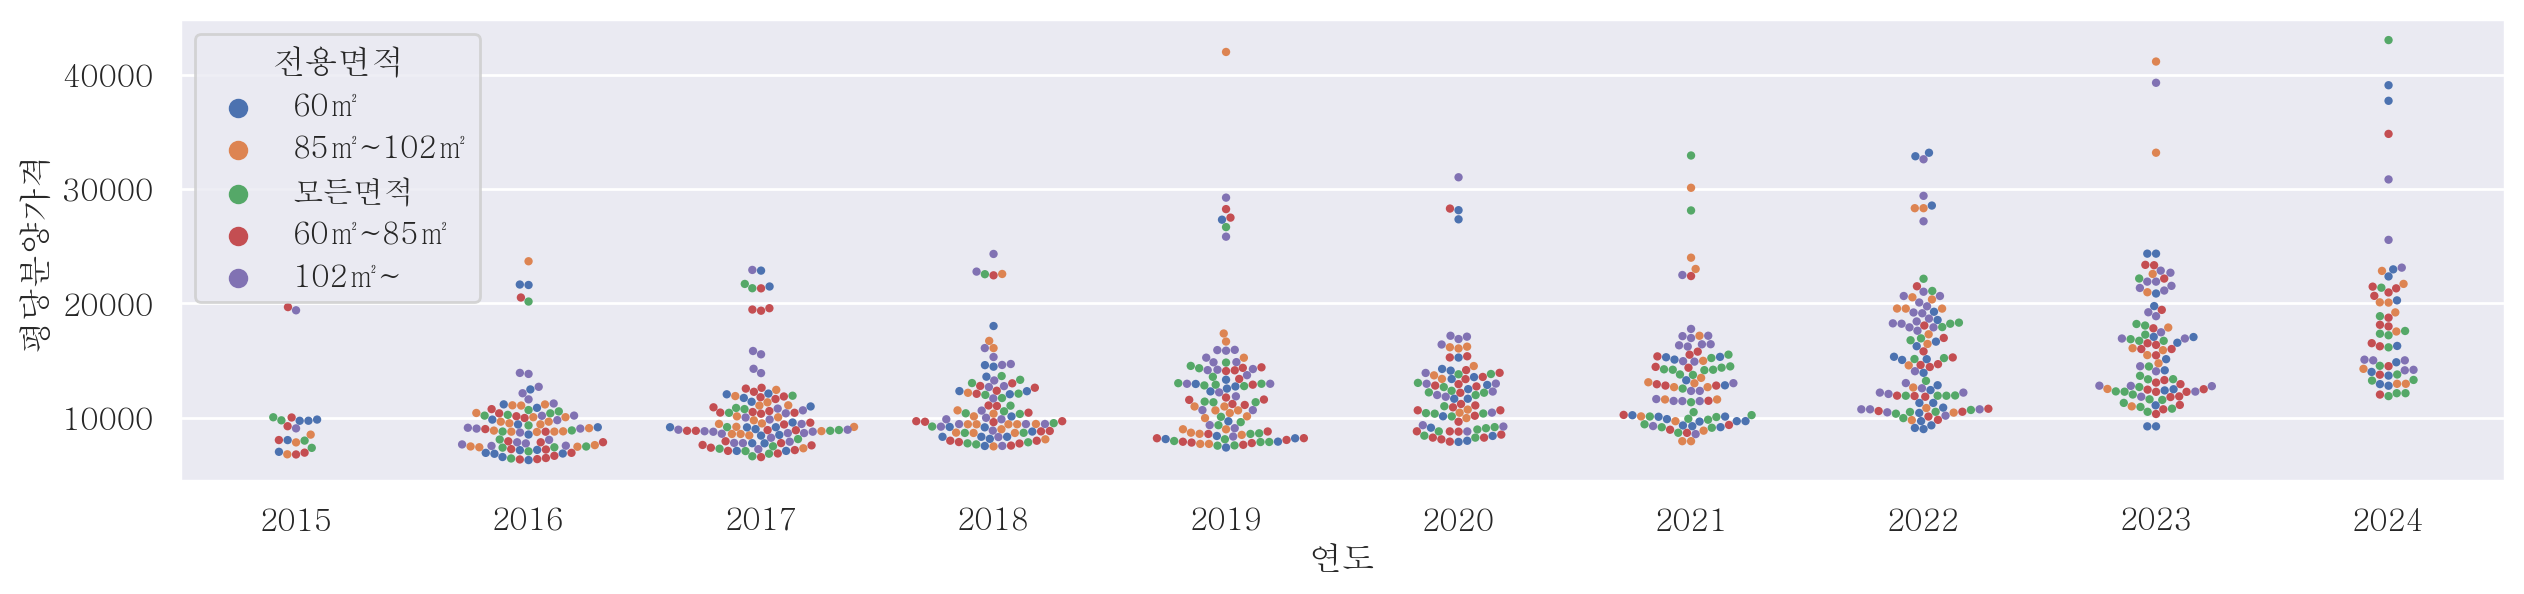

CPU times: total: 1.34 s
Wall time: 1.42 s


In [157]:
%%time
# 분포를 나타내는 swarmpplot
# 데이터 샘플링하여 활용
df_sample = df_map.sample(frac = 0.1, random_state = 12)
sns.swarmplot(data = df_sample, x = '연도', y = '평당분양가격', hue = '전용면적', size = 3)
plt.show()

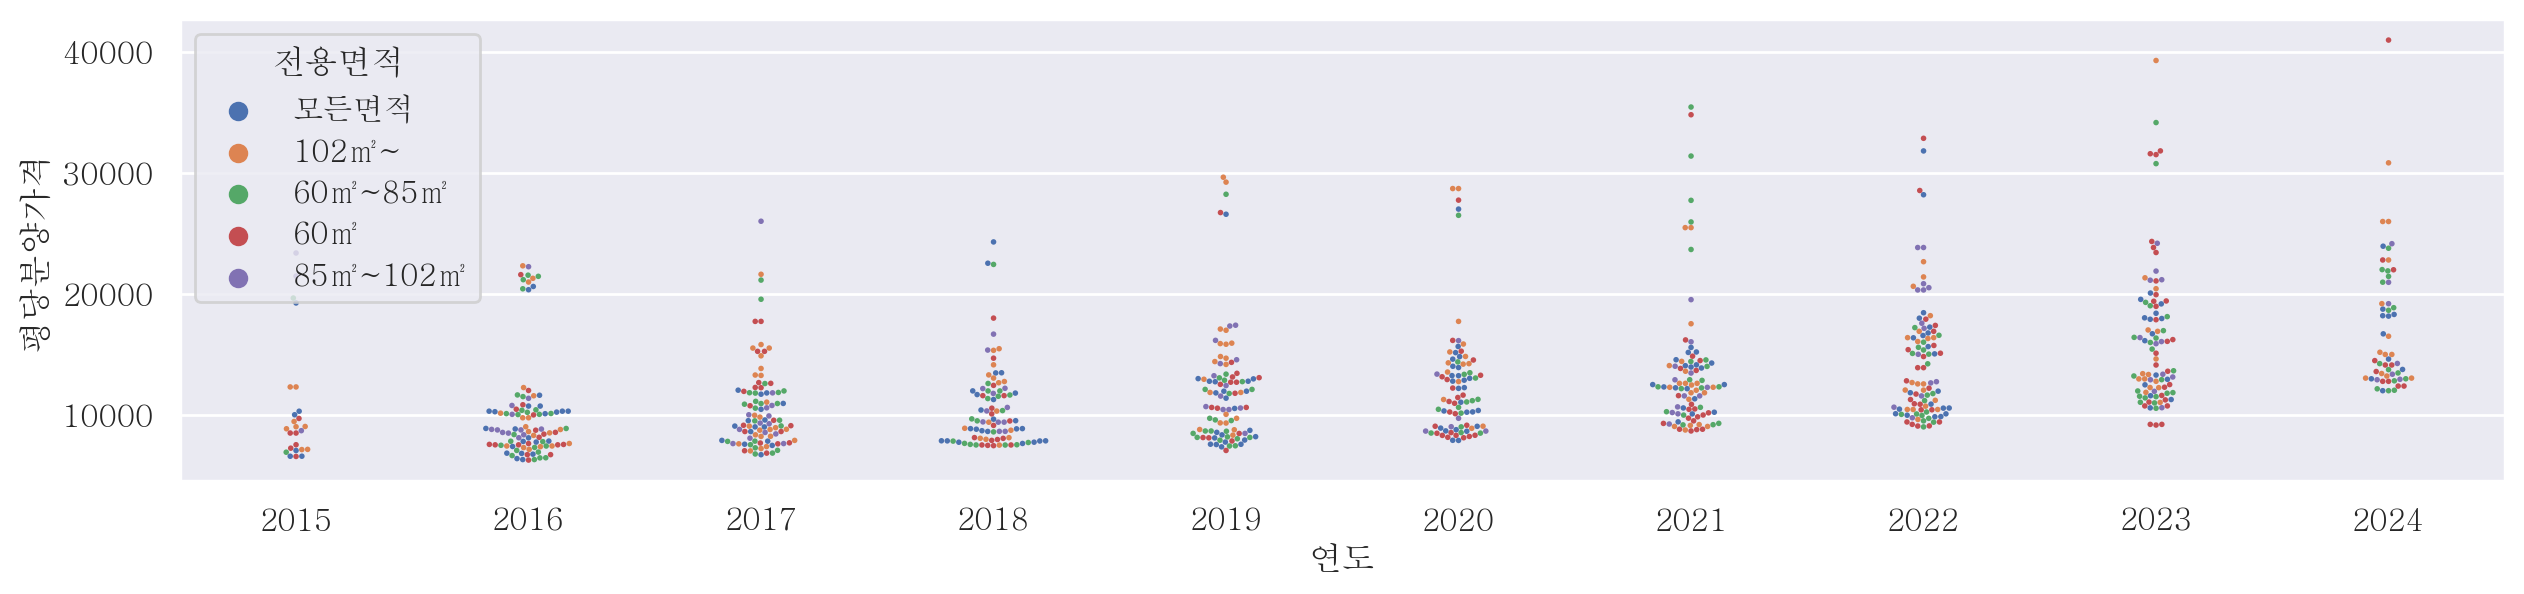

CPU times: total: 1.06 s
Wall time: 1.12 s


In [163]:
%%time
# 분포를 나타내는 swarmpplot(많은 데이터 -> 층화샘플링)
from sklearn.model_selection import train_test_split
_,df_sample = train_test_split(df_map,
                              test_size = 0.1,
                              stratify=df_map.연도)
sns.swarmplot(data = df_sample, x= '연도', y = '평당분양가격', hue = '전용면적', size = 2)
plt.show()

<Axes: >

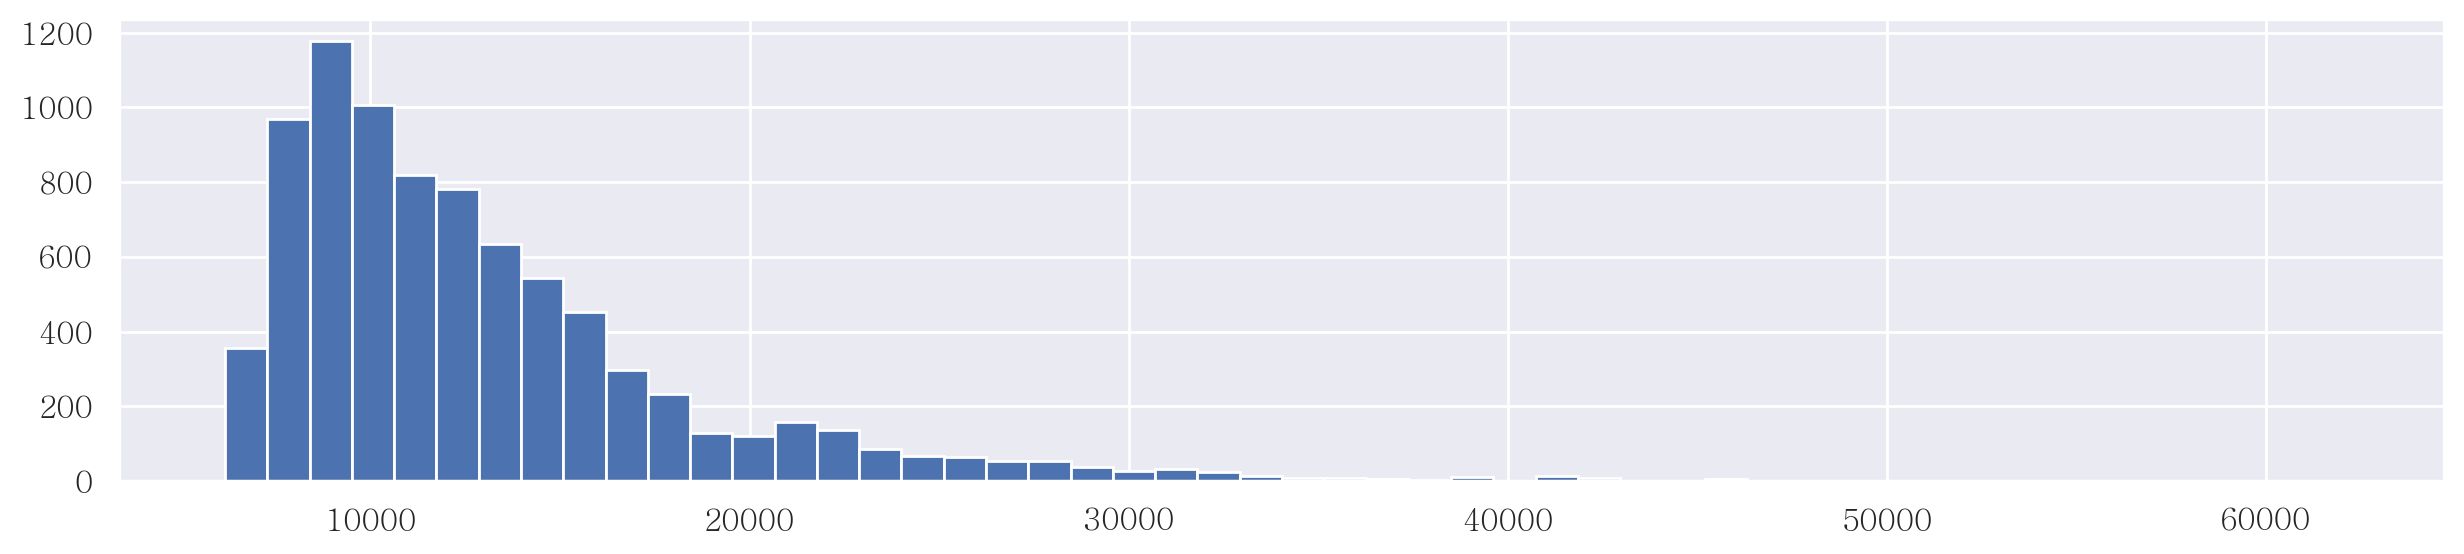

In [164]:
df_map['평당분양가격'].hist(bins=50)

<Axes: xlabel='평당분양가격', ylabel='Count'>

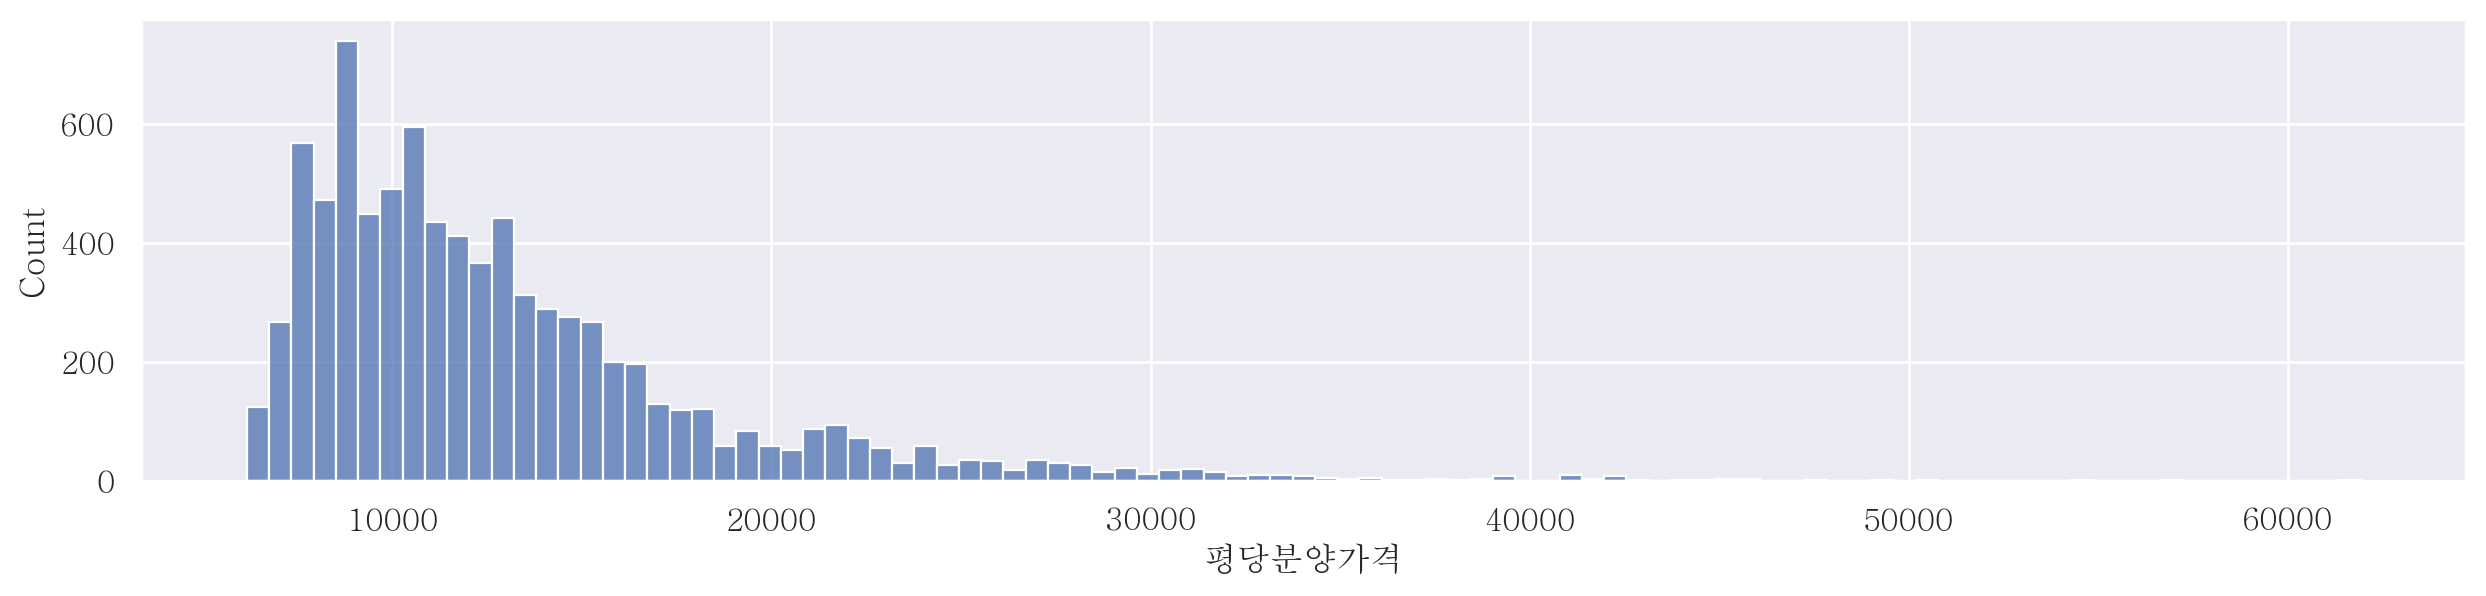

In [165]:
sns.histplot(data = df_map, x = '평당분양가격')

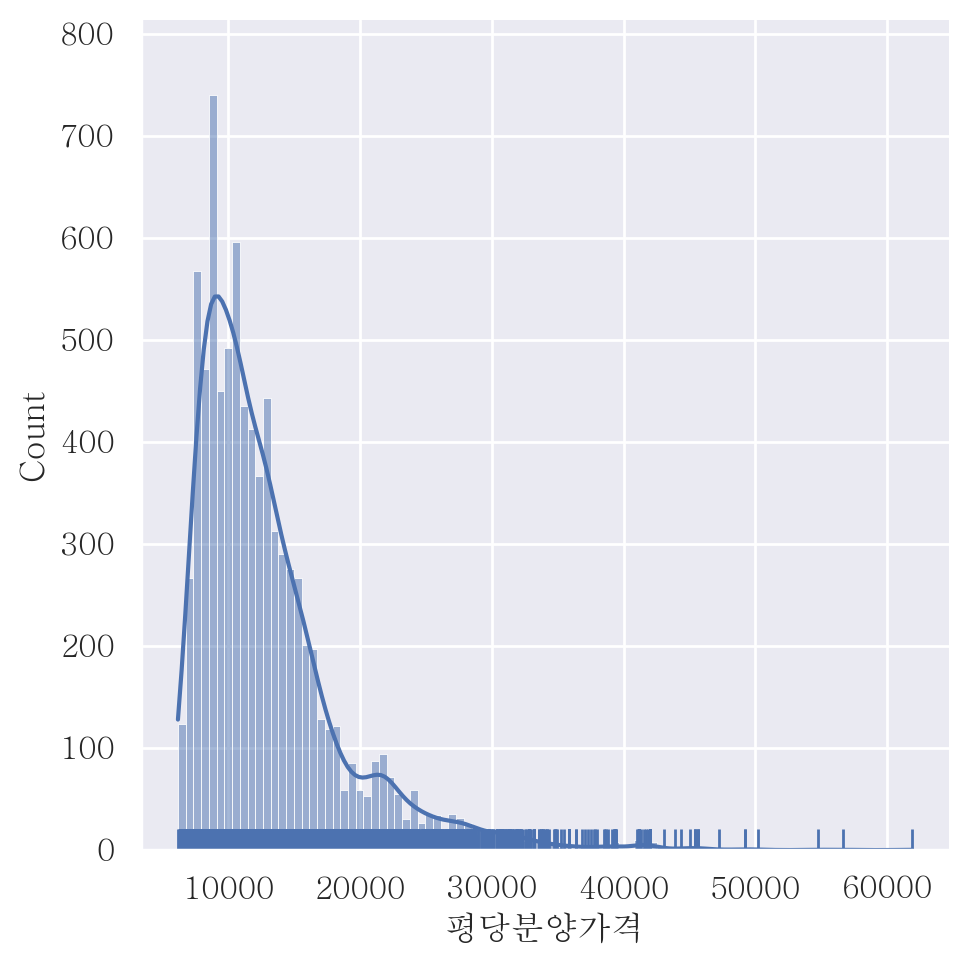

In [166]:
sns.displot(data = df_map, x = '평당분양가격', kde = True, rug = True)

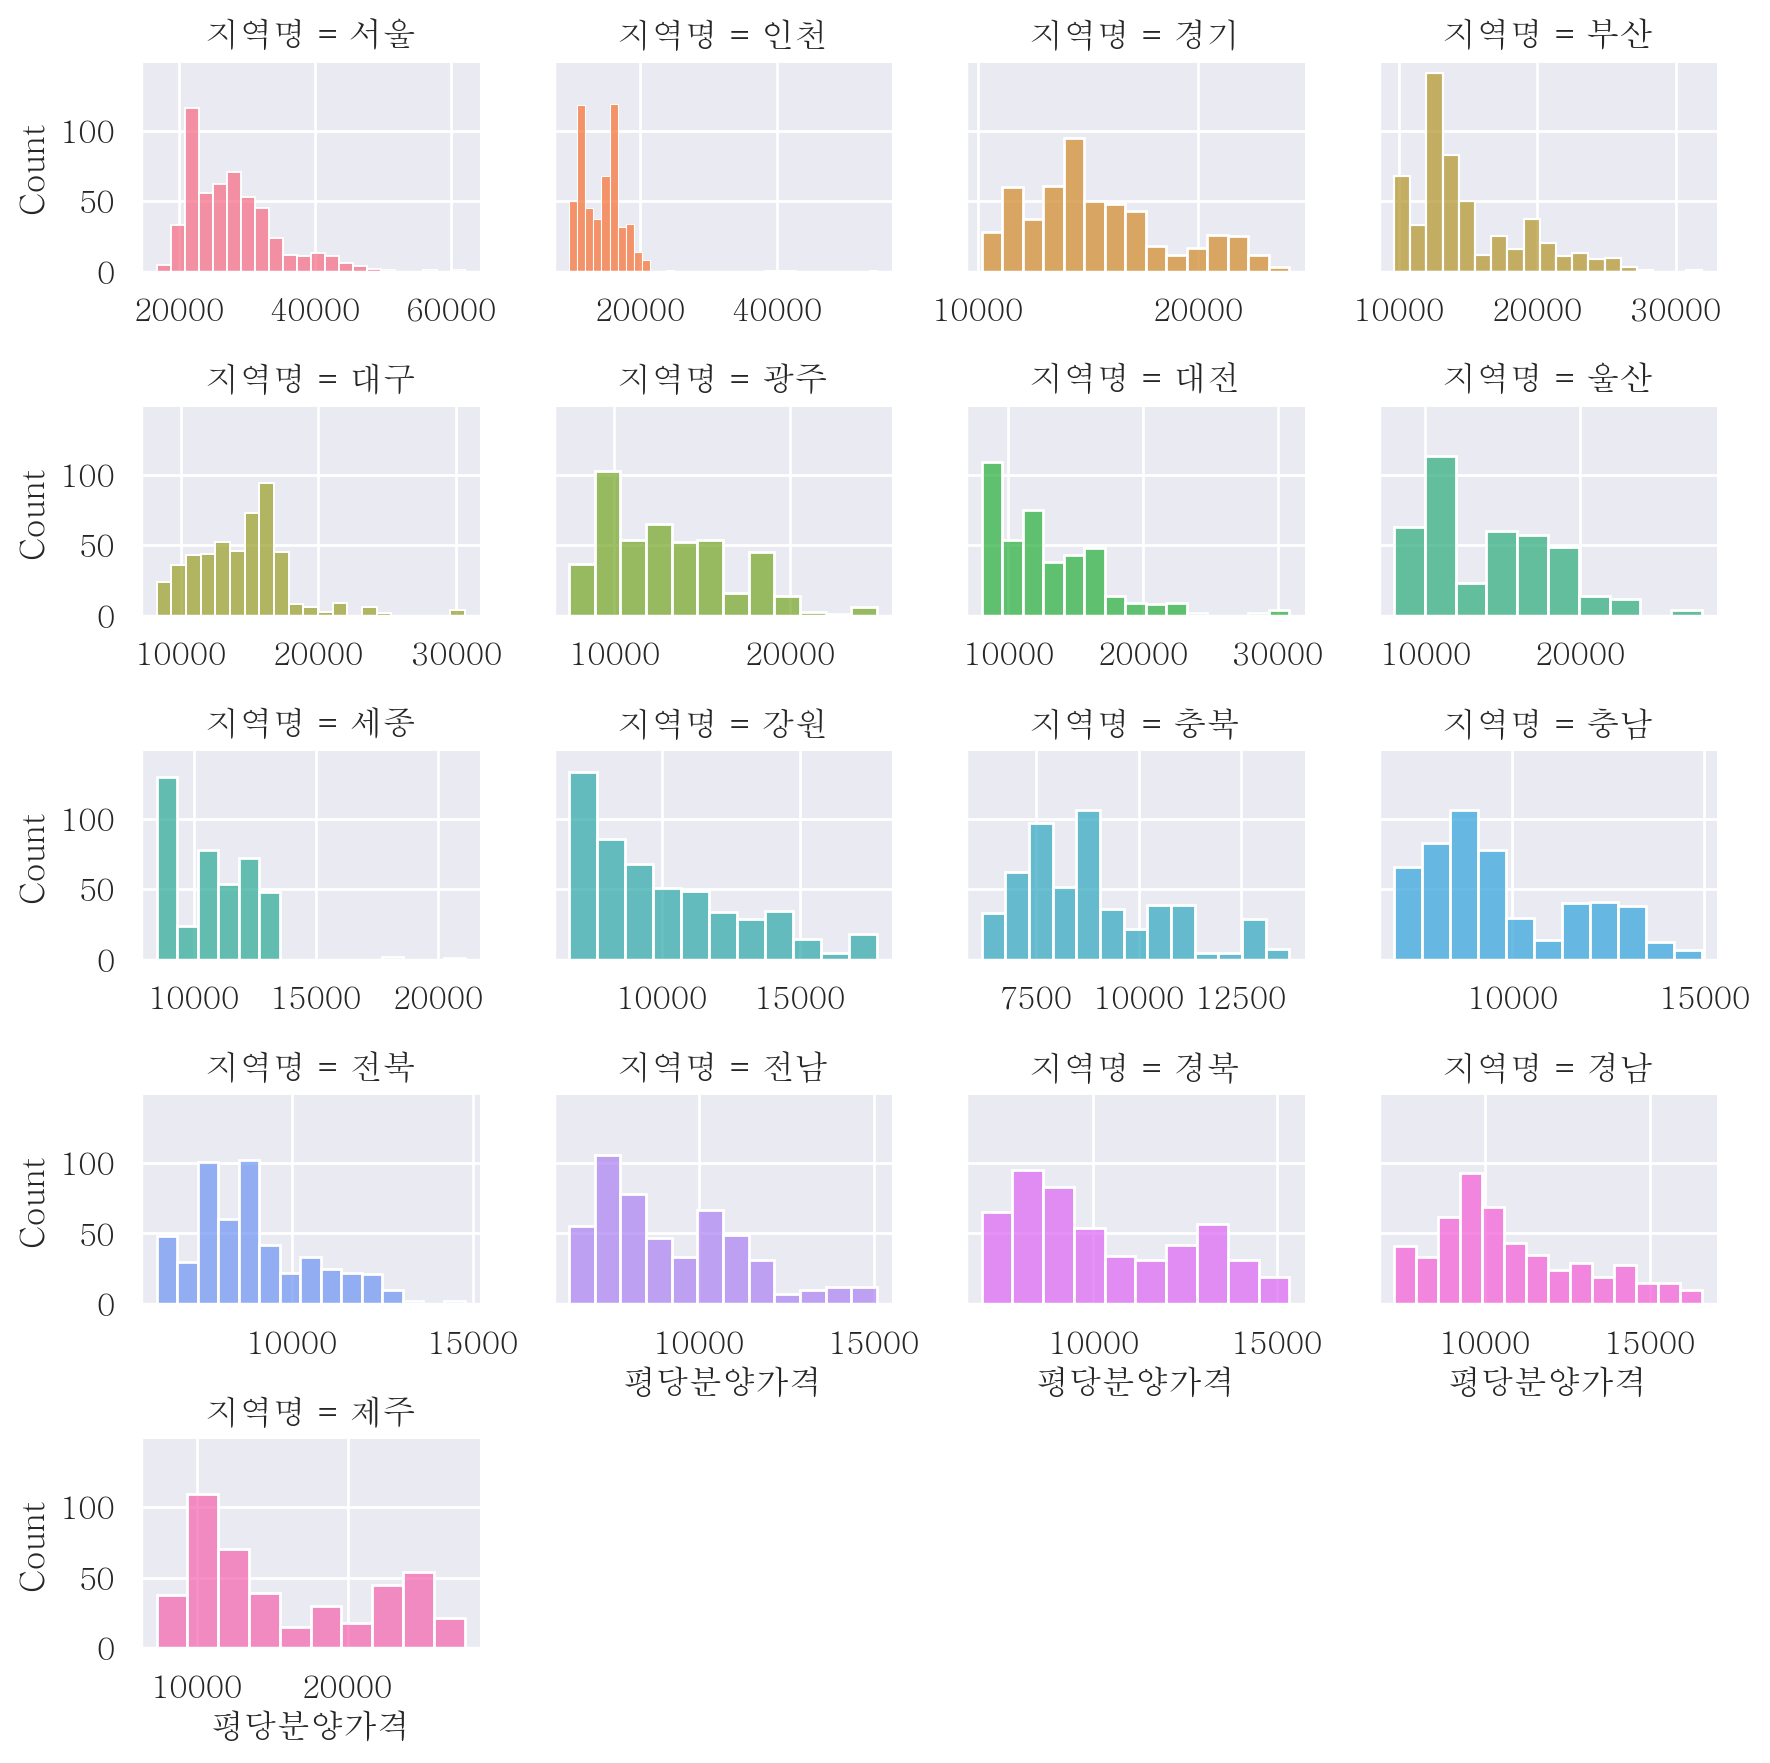

In [174]:
g = sns.FacetGrid(df_last, hue = '지역명', col ='지역명', col_wrap = 4, sharex = False)
g.map(sns.histplot, '평당분양가격')
g.fig.set_size_inches(9,9) # size 조정
plt.tight_layout() # 서브플롯 tight하게 배치
plt.show()

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first : df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

In [323]:
# new_first 먼저 만들기
df_first = pd.read_csv('C:/ai_x/download/sharedata/부동산_250213/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
# airquality_melted = airquality.melt(id_vars = [고정할 열], var_name='변수명', # default variable, value_name='값') # default : value
df_first.melt(id_vars = '지역',var_name = '연도월', value_name = '평당분양가격')

,지역,연도월,평당분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098
...,...,...,...
352,전북,2015년8월,6580
353,전남,2015년8월,6289
354,경북,2015년8월,7037
355,경남,2015년8월,7665


In [324]:
new_first = df_first.melt(id_vars = '지역',var_name = '연도월', value_name = '평당분양가격')
new_first.sample()

,지역,연도월,평당분양가격
268,전남,2015년3월,5825


In [325]:
def parse_date(row) :
    row['연도'] = int(row['연도월'].split('년')[0])
    row['월'] =int(row['연도월'].split('년')[1][:-1])
    return row
print(parse_date(new_first.iloc[0]))
new_first = new_first.apply(parse_date, axis = 1).drop('연도월',axis=1)

지역              서울
연도월       2013년12월
평당분양가격       18189
연도            2013
월               12
Name: 0, dtype: object


In [326]:
new_first['지역명'] = new_first.지역

In [327]:
new_first.drop('지역',axis = 1, inplace=True)
new_first

,평당분양가격,연도,월,지역명
0,18189,2013,12,서울
1,8111,2013,12,부산
2,8080,2013,12,대구
3,10204,2013,12,인천
4,6098,2013,12,광주
...,...,...,...,...
352,6580,2015,8,전북
353,6289,2015,8,전남
354,7037,2015,8,경북
355,7665,2015,8,경남


In [328]:
new_first = new_first[['지역명','연도','월','평당분양가격']]
new_first # new_first concat 준비 완료

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189
1,부산,2013,12,8111
2,대구,2013,12,8080
3,인천,2013,12,10204
4,광주,2013,12,6098
...,...,...,...,...
352,전북,2015,8,6580
353,전남,2015,8,6289
354,경북,2015,8,7037
355,경남,2015,8,7665


In [329]:
df_last.head(1)
new_last = df_last[df_last.전용면적 == '모든면적'].copy()
new_last.drop('전용면적', axis = 1, inplace=True)
new_last.tail(1) # new_last concat 준비 완료

,지역명,연도,월,평당분양가격
9090,제주,2024,8,25419.9


In [330]:
all(new_last.columns == new_first.columns) # 두 데이터프레임의 컬럼명이 같은 지 체크

True

In [331]:
df = pd.concat([new_first,new_last], axis = 0) # 활용 데이터 완성

In [332]:
df.reset_index(drop =True, inplace=True)
df

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189.0
1,부산,2013,12,8111.0
2,대구,2013,12,8080.0
3,인천,2013,12,10204.0
4,광주,2013,12,6098.0
...,...,...,...,...
2171,전북,2024,8,12058.2
2172,전남,2024,8,13120.8
2173,경북,2024,8,13827.0
2174,경남,2024,8,13252.8


In [333]:
df.head(1)

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189.0


## (2) 결측치 대체(연도별, 지역별 중위값)

In [346]:
# df[df['평당분양가격'].isna()] Boolian 인덱싱
df[df.isnull().any(axis=1)].head(1) # index = 1010(번째 행)

,지역명,연도,월,평당분양가격
1010,울산,2018,12,NaN


In [347]:
# 연도별 지역별 중앙값으로 결측치 대체 방법 1
fill_na_value = df.groupby(['연도','지역명'])['평당분양가격'].median().unstack()
fill_na_value = df.pivot_table(index = '연도', columns='지역명',values = '평당분양가격', aggfunc='median')
fill_na_value
# 결측치의 연도, 지역명 => fillnavalue[연도, 지역명]으로 할당

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2013,6230.00,10855.00,6473.00,6168.00,6098.00,8080.00,8321.00,8111.00,18189.00,7601.0,8090.00,10204.00,5678.00,6282.00,7674.00,6365.00,6589.00
2014,6350.00,10449.00,6611.50,6555.00,7617.00,8317.00,8327.00,9233.00,19070.50,8067.0,8153.00,10018.00,5716.00,6335.00,7900.00,6724.50,6593.50
2015,6986.00,10518.00,7665.00,7006.00,7914.00,8542.00,8079.00,9515.00,19275.30,8669.0,9192.00,10443.00,6243.00,6583.00,7365.60,6975.00,6705.60
2016,6964.65,11342.10,7865.55,7385.40,8987.55,10335.60,8380.35,10414.80,20654.70,8860.5,10127.70,10531.95,6491.10,6369.00,9329.10,7377.15,6801.30
2017,7057.05,11919.60,8052.00,7835.85,9551.85,11231.55,9035.40,11851.95,21402.15,9018.9,11488.95,10875.15,7114.80,7222.05,10885.05,7448.10,6765.00
2018,7669.20,13099.35,8898.45,8667.45,9678.90,12178.65,9807.60,12926.10,22567.05,10388.4,10312.50,11233.20,7774.80,7652.70,11649.00,8030.55,7870.50
2019,8221.95,14487.00,9791.10,8723.55,12071.40,13963.95,11866.80,13061.40,26428.05,11411.4,10362.00,12827.10,7920.00,8146.05,12561.45,8598.15,7570.20
2020,9271.35,14331.90,10263.00,9929.70,12624.15,15302.10,11030.25,13266.00,26769.60,11355.3,12581.25,14648.70,8571.75,8225.25,15130.50,8863.80,7924.95
2021,9607.95,14173.50,10523.70,10338.90,14127.30,15528.15,12196.80,14460.60,29769.30,12533.4,14256.00,14950.65,9857.10,8834.10,23756.70,9306.00,8677.35


In [348]:
# result
def fillna_median(row) :
    """row.평당분양가격이 결측치라면 fill_na_value['연도', '지역명']으로 대체하고 row 리턴"""
    if pd.isnull(row.평당분양가격) :
        row.평당분양가격 = fill_na_value.loc[row.연도, row.지역명]
    return row

In [349]:
df = df.apply(fillna_median, axis = 1)

In [350]:
# 연도별 지역별 중앙값으로 결측치 대체 방법 1
df2 = pd.read_csv('data/ch_13_new_df.csv')
df2.isna().sum()

지역명        0
연도         0
월          0
평당분양가격    26
dtype: int64

In [351]:
df2['평당분양가격'] = df2.groupby(['지역명', '연도'])['평당분양가격'].transform(lambda x : x.fillna(x.median()))

In [352]:
df2.loc[1010]

지역명            울산
연도           2018
월              12
평당분양가격    10312.5
Name: 1010, dtype: object

,지역명,연도,월,평당분양가격
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True
4,True,True,True,True
...,...,...,...,...
2171,True,True,True,True
2172,True,True,True,True
2173,True,True,True,True
2174,True,True,True,True


## (3) df.csv파일로 출력

In [353]:
df.to_csv('data/ch_13_new_df_결측치중위값대체.csv', index = False )

In [356]:
df2.to_csv('C:/ai_x/download/sharedata/부동산_250213/최종전국평당분양가격_결측치제외.csv', encoding='cp949', index = False)

In [358]:
df_check = pd.read_csv('C:/ai_x/download/sharedata/부동산_250213/최종전국평당분양가격_결측치제외.csv', encoding = 'cp949')
df_check

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189.0
1,부산,2013,12,8111.0
2,대구,2013,12,8080.0
3,인천,2013,12,10204.0
4,광주,2013,12,6098.0
...,...,...,...,...
2171,전북,2024,8,12058.2
2172,전남,2024,8,13120.8
2173,경북,2024,8,13827.0
2174,경남,2024,8,13252.8


## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

In [363]:
df.groupby('지역명')['평당분양가격'].count()

지역명
강원    128
경기    128
경남    128
경북    128
광주    128
대구    128
대전    128
부산    128
서울    128
세종    128
울산    128
인천    128
전남    128
전북    128
제주    128
충남    128
충북    128
Name: 평당분양가격, dtype: int64

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [364]:
# 평균
df.groupby('지역명')['평당분양가격'].mean()

지역명
강원     9035.030469
경기    14035.542969
경남     9642.546094
경북     9337.025000
광주    11952.633594
대구    13674.428906
대전    11331.642969
부산    13852.528906
서울    25545.817188
세종    10851.086719
울산    12450.221875
인천    13278.530469
전남     8456.272656
전북     8298.753125
제주    14922.654688
충남     8764.862500
충북     8237.684375
Name: 평당분양가격, dtype: float64

In [365]:
# 최대값
df.groupby('지역명')['평당분양가격'].max()

지역명
강원    15120.6
경기    21591.9
경남    14543.1
경북    13827.0
광주    23964.6
대구    30600.9
대전    18767.1
부산    27017.1
서울    43939.5
세종    18126.9
울산    18932.1
인천    41830.8
전남    13401.3
전북    12487.2
제주    27574.8
충남    12823.8
충북    13011.9
Name: 평당분양가격, dtype: float64

In [366]:
# 요약통계
df.groupby('지역명')['평당분양가격'].describe()

,count,mean,std,min,25%,50%,75%,max
지역명,,,,,,,,
강원,128.0,9035.030469,2581.361744,6141.0,7016.250,8131.20,10355.400,15120.6
경기,128.0,14035.542969,3146.644392,10124.0,11501.325,13831.95,15061.200,21591.9
경남,128.0,9642.546094,2017.119966,6473.0,7877.100,9690.45,10944.450,14543.1
경북,128.0,9337.025000,2263.474310,6168.0,7425.825,8713.65,10880.100,13827.0
광주,128.0,11952.633594,3665.696607,6098.0,9023.025,11267.85,14545.575,23964.6
대구,128.0,13674.428906,4318.886394,8077.0,10340.550,13414.50,15988.500,30600.9
대전,128.0,11331.642969,3003.475781,8038.0,8454.600,11053.35,12600.225,18767.1
부산,128.0,13852.528906,3999.865650,8111.0,10479.975,13035.00,16800.300,27017.1
서울,128.0,25545.817187,5715.838690,17925.0,20670.900,25667.40,28733.925,43939.5


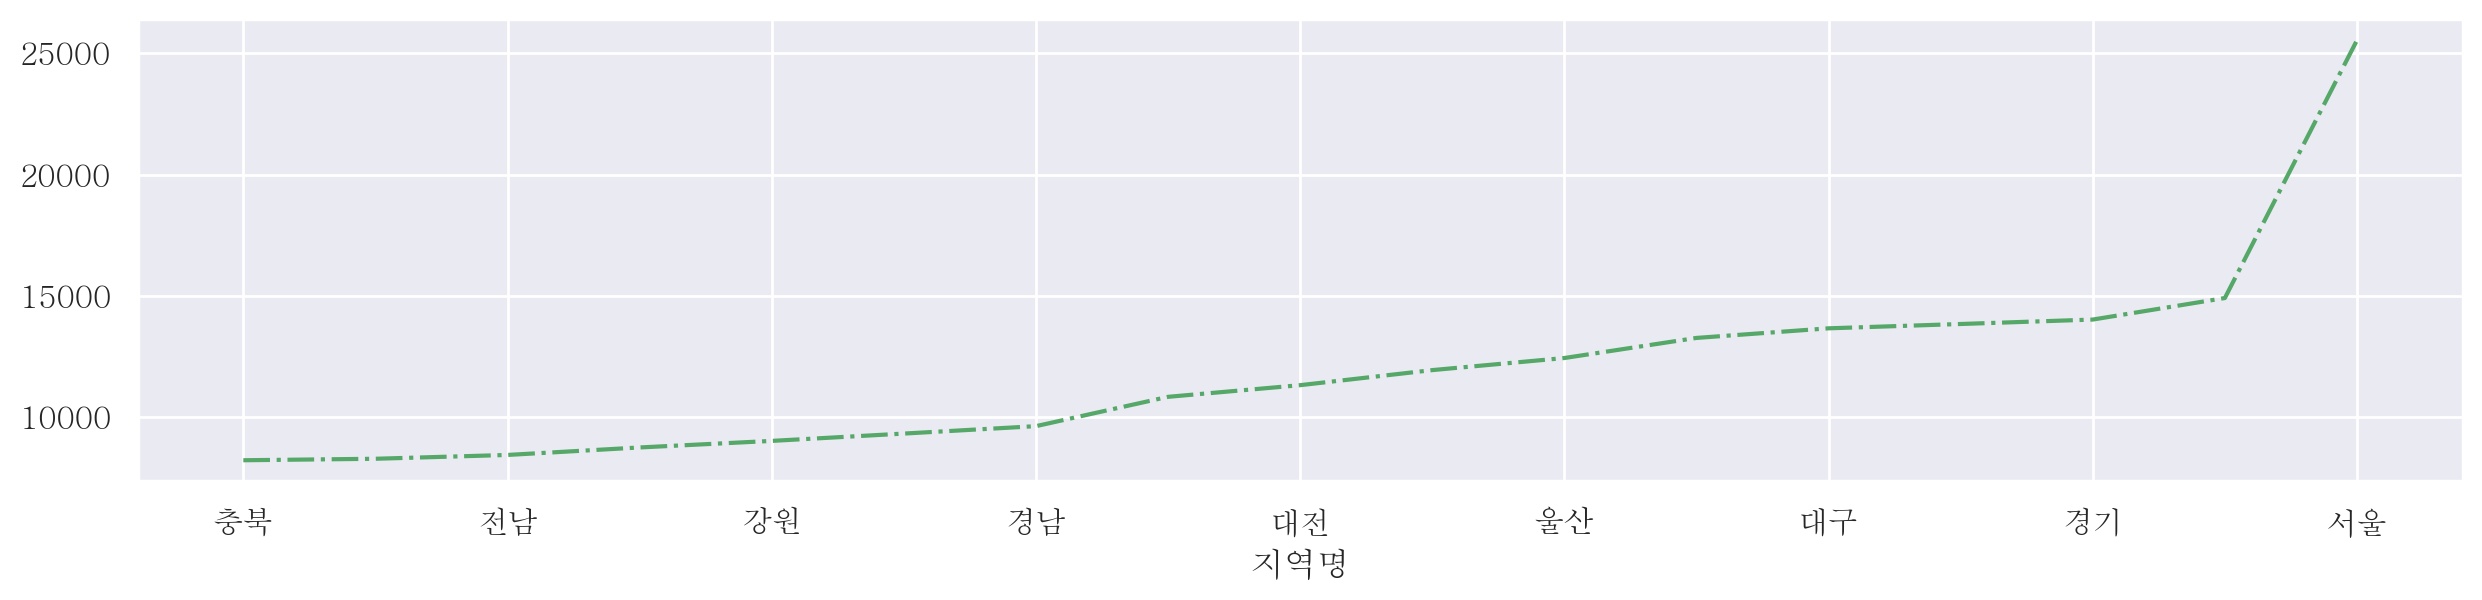

In [380]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)
df_mean = df.groupby('지역명')['평당분양가격'].mean()
sns.set(style = 'darkgrid', palette = 'Set1')
plt.rc('font', family = 'Batang')
ax = df_mean.sort_values().plot.line(x='지역명', y = '평당분양가격', color = 'g', linestyle = '-.')
plt.show()
# 지역명이 17개로 모두 표기하면 가독성이 현저히 저하되어 기본값 활용

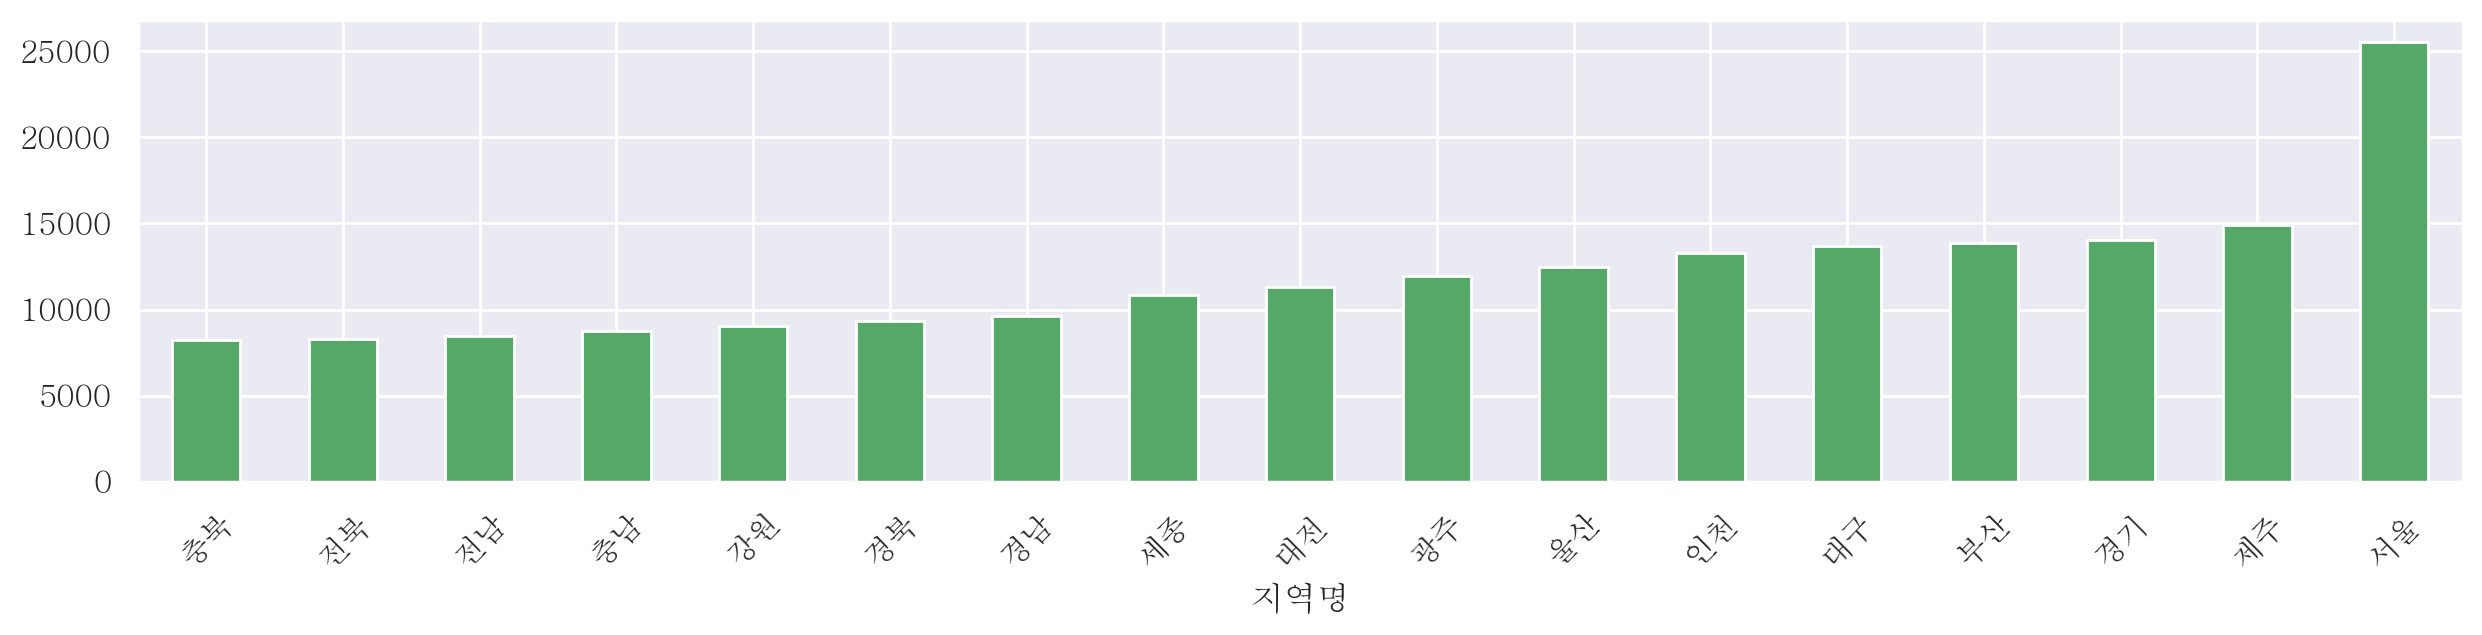

In [385]:
ax = df_mean.sort_values().plot.bar(x='지역명', color = 'g')
plt.xticks(rotation = 45)
plt.show()

<Axes: xlabel='지역명', ylabel='평당분양가격'>

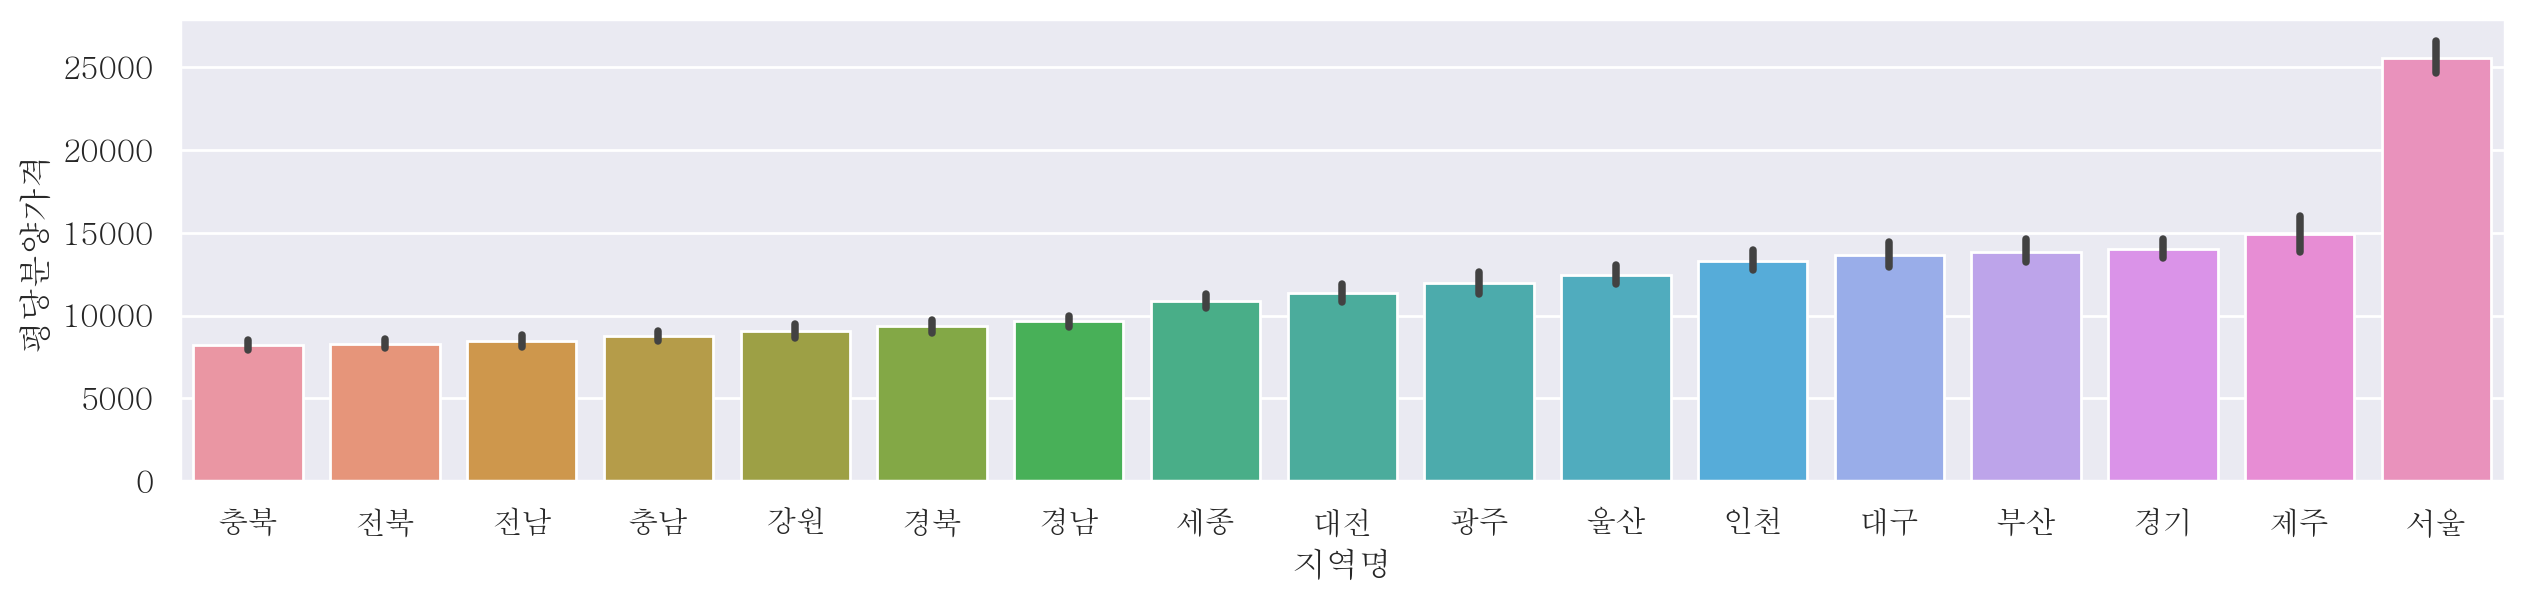

In [396]:
sns.barplot(data = df, x = '지역명', y = '평당분양가격', order = df_mean.sort_values().index)

### ③ 연도별 평당분양가격(평균)

In [399]:
df.groupby('연도')['평당분양가격'].mean().round(2)

연도
2013     8059.29
2014     8362.25
2015     8694.00
2016     9293.04
2017     9927.32
2018    10674.04
2019    11554.06
2020    12289.41
2021    13706.89
2022    14690.34
2023    16319.68
2024    18499.61
Name: 평당분양가격, dtype: float64

<Axes: xlabel='연도'>

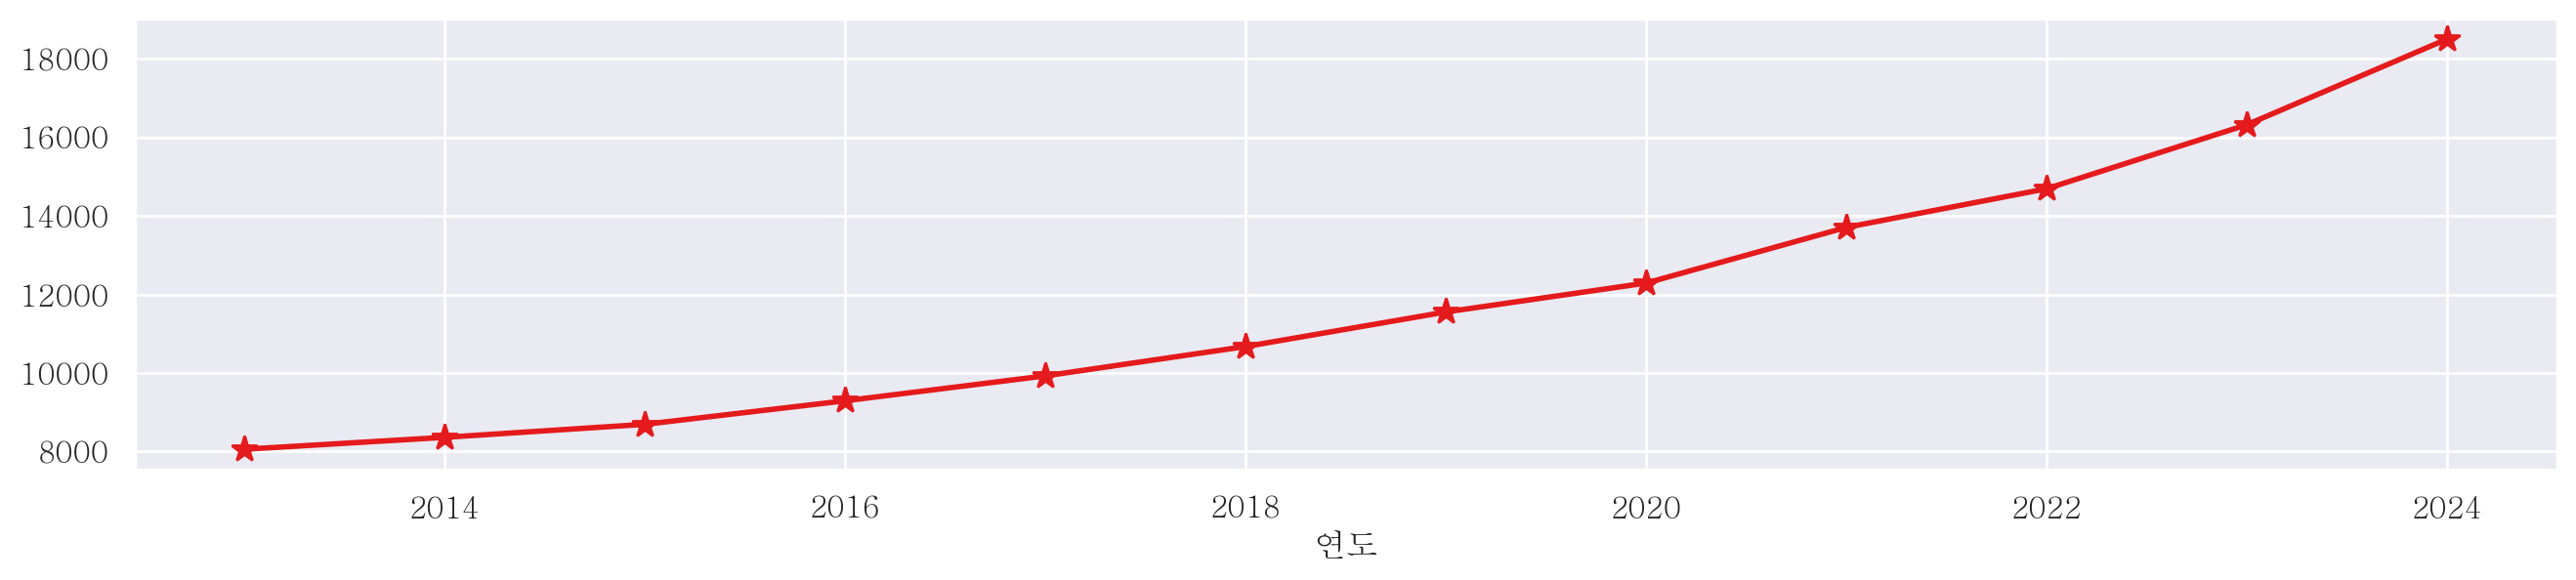

In [409]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)
df.groupby('연도')['평당분양가격'].mean().plot.line(figsize=(16,3),linewidth=2, marker='*', markersize=10)

<BarContainer object of 2176 artists>

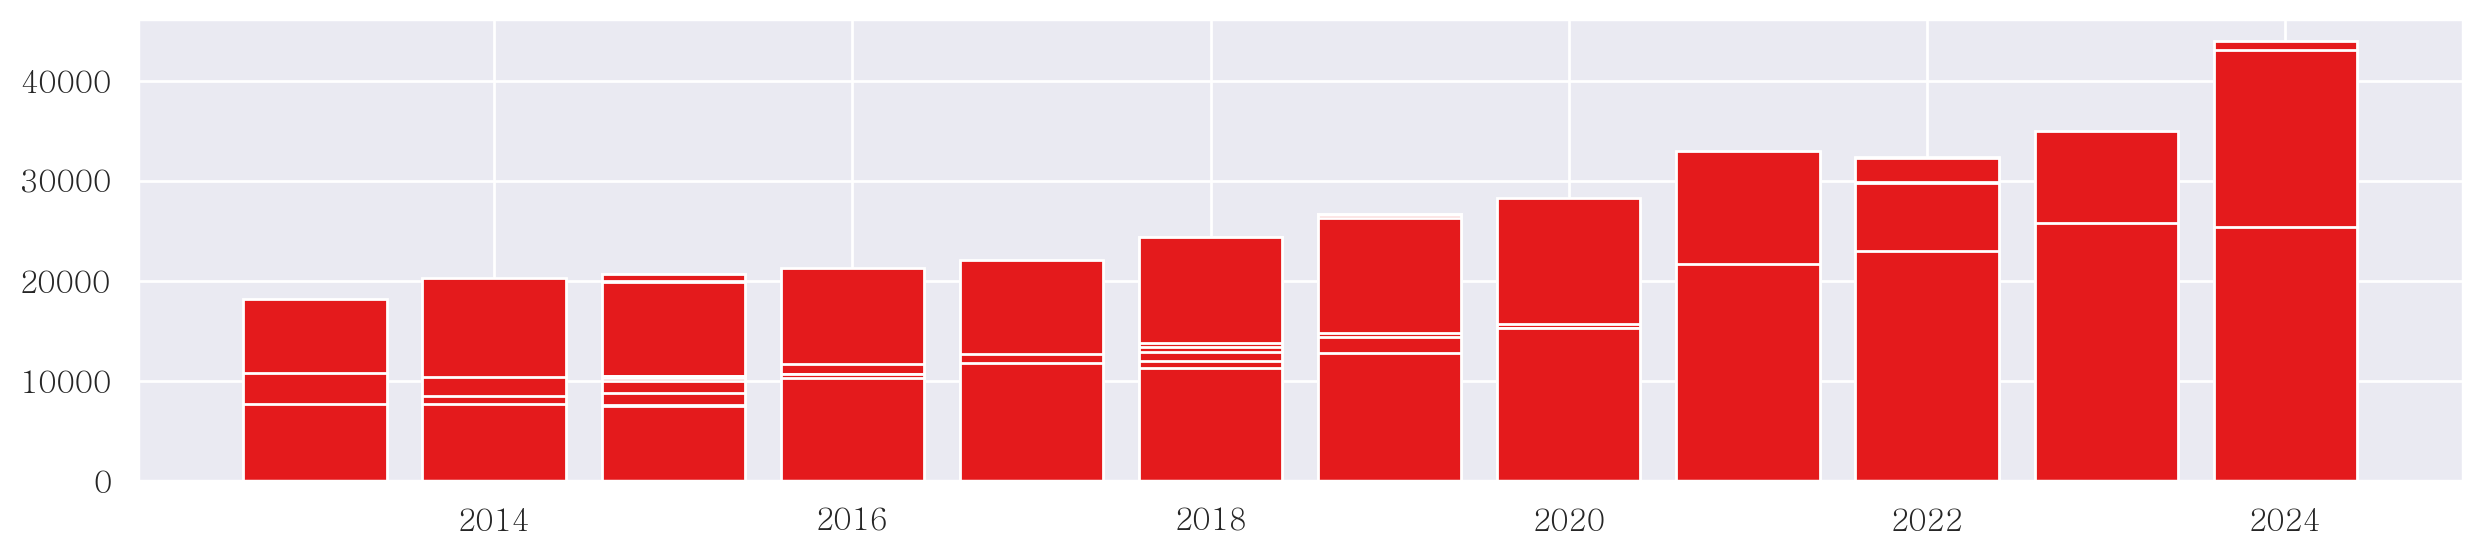

In [413]:
plt.bar(x = df['연도'], height = df['평당분양가격'])

<Axes: xlabel='연도', ylabel='평당분양가격'>

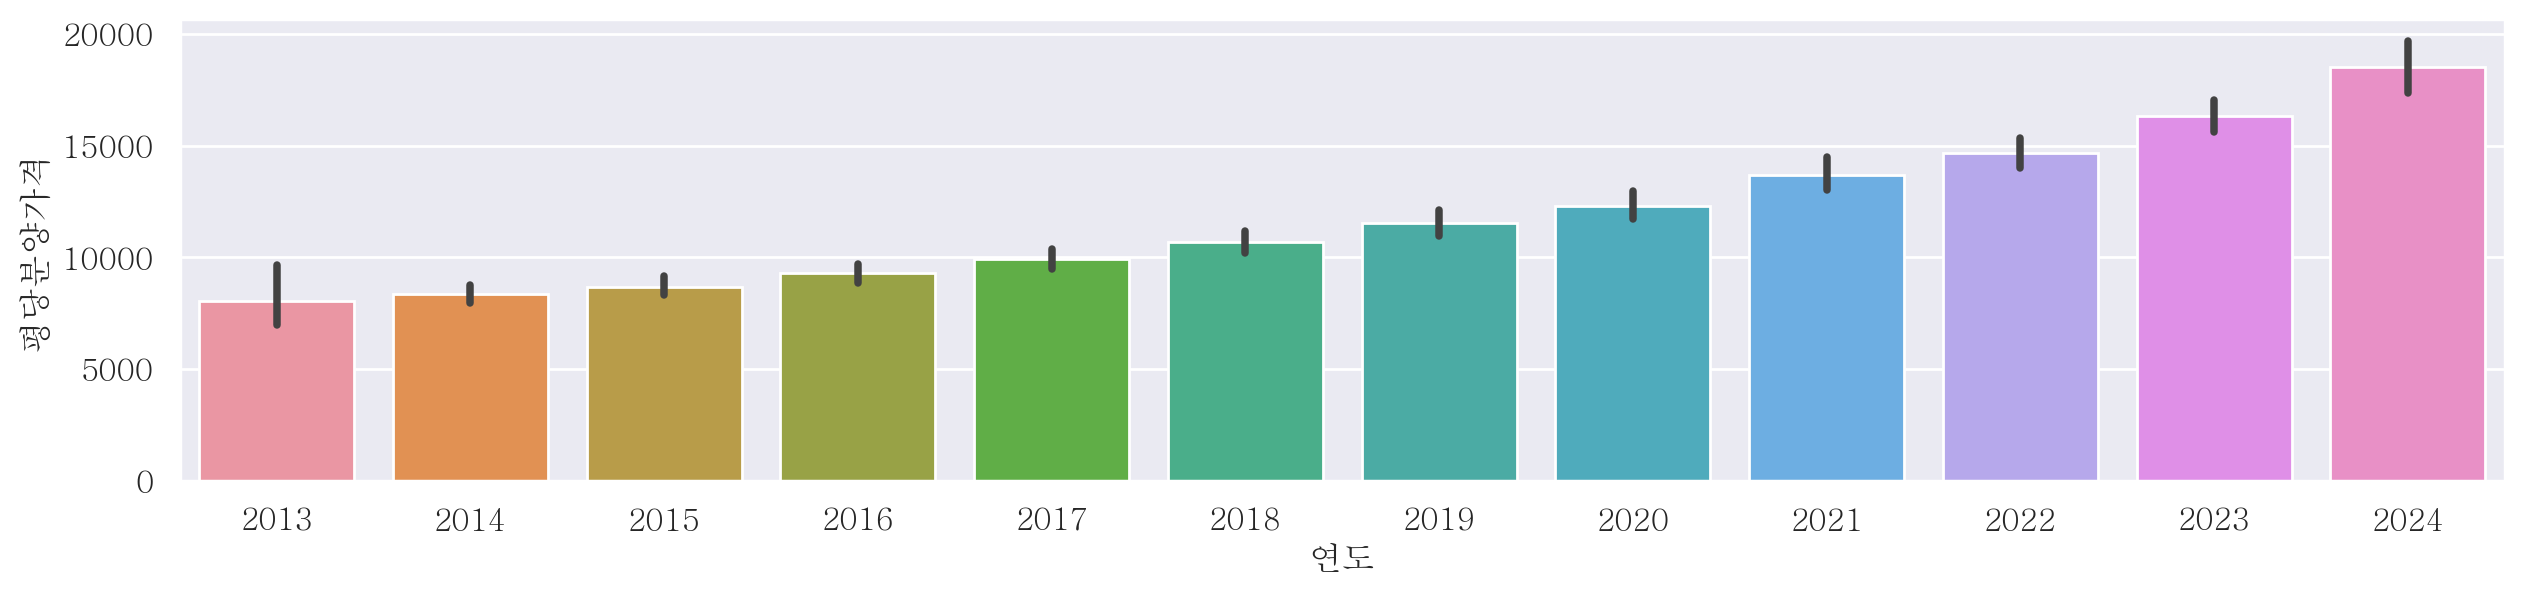

In [416]:
sns.barplot(data=df, x= '연도', y = '평당분양가격')

### ④ 연도, 지역별 평당분양가격(평균)

In [466]:
df.groupby(['연도','지역명'])['평당분양가격'].mean().unstack()

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2013,6230.000000,10855.000000,6473.000000,6168.000000,6098.000000,8080.000000,8321.000000,8111.000000,18189.0000,7601.000000,8090.000000,10204.000000,5678.000000,6282.000000,7674.000000,6365.000000,6589.000000
2014,6332.500000,10509.083333,6728.750000,6536.500000,7587.833333,8286.083333,8240.333333,9180.166667,18997.2500,8085.333333,8361.666667,10074.833333,5718.916667,6362.333333,7855.166667,6681.583333,6620.000000
2015,6831.154545,10489.109091,7646.163636,7035.063636,7956.090909,8706.718182,8104.509091,9633.272727,19282.6000,8641.227273,9273.336364,10276.845455,6109.263636,6623.290909,7465.327273,7024.490909,6699.572727
2016,7011.125000,11220.000000,7847.950000,7360.650000,8898.725000,10310.025000,8501.625000,10429.925000,20663.5000,8860.500000,10208.550000,10532.500000,6488.625000,6417.950000,9129.175000,7330.675000,6770.225000
2017,7170.625000,11840.675000,8163.925000,7802.575000,9471.000000,11507.100000,9056.025000,11663.575000,21425.2500,9133.025000,11327.525000,10749.475000,7245.700000,7074.650000,10907.325000,7455.800000,6770.225000
2018,7680.750000,13185.975000,9019.450000,8505.200000,9855.725000,12075.800000,10180.225000,12997.875000,22889.3500,10354.850000,10247.325000,11273.900000,7789.100000,7625.750000,11890.725000,8012.675000,7874.075000
2019,8141.650000,14468.850000,9870.850000,8856.650000,11822.800000,13852.025000,11777.700000,13116.400000,26131.0500,11078.925000,10248.700000,12634.875000,7902.400000,8196.650000,12137.950000,8606.950000,7574.600000
2020,9331.300000,14383.325000,10160.700000,9544.975000,12500.125000,15145.075000,11094.050000,13247.575000,26910.1250,11355.300000,12202.850000,14674.000000,8696.875000,8317.100000,14540.900000,8856.100000,7959.600000
2021,9716.850000,14183.125000,10505.000000,10333.400000,14020.875000,15558.125000,11914.100000,14645.675000,30115.2500,12561.175000,14274.975000,14991.625000,9907.700000,8838.500000,23423.950000,9345.600000,8681.200000


지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2013,6230.000000,10855.000000,6473.000000,6168.000000,6098.000000,8080.000000,8321.000000,8111.000000,18189.0000,7601.000000,8090.000000,10204.000000,5678.000000,6282.000000,7674.000000,6365.000000,6589.000000
2014,6332.500000,10509.083333,6728.750000,6536.500000,7587.833333,8286.083333,8240.333333,9180.166667,18997.2500,8085.333333,8361.666667,10074.833333,5718.916667,6362.333333,7855.166667,6681.583333,6620.000000
2015,6831.154545,10489.109091,7646.163636,7035.063636,7956.090909,8706.718182,8104.509091,9633.272727,19282.6000,8641.227273,9273.336364,10276.845455,6109.263636,6623.290909,7465.327273,7024.490909,6699.572727
2016,7011.125000,11220.000000,7847.950000,7360.650000,8898.725000,10310.025000,8501.625000,10429.925000,20663.5000,8860.500000,10208.550000,10532.500000,6488.625000,6417.950000,9129.175000,7330.675000,6770.225000
2017,7170.625000,11840.675000,8163.925000,7802.575000,9471.000000,11507.100000,9056.025000,11663.575000,21425.2500,9133.025000,11327.525000,10749.475000,7245.700000,7074.650000,10907.325000,7455.800000,6770.225000
2018,7680.750000,13185.975000,9019.450000,8505.200000,9855.725000,12075.800000,10180.225000,12997.875000,22889.3500,10354.850000,10247.325000,11273.900000,7789.100000,7625.750000,11890.725000,8012.675000,7874.075000
2019,8141.650000,14468.850000,9870.850000,8856.650000,11822.800000,13852.025000,11777.700000,13116.400000,26131.0500,11078.925000,10248.700000,12634.875000,7902.400000,8196.650000,12137.950000,8606.950000,7574.600000
2020,9331.300000,14383.325000,10160.700000,9544.975000,12500.125000,15145.075000,11094.050000,13247.575000,26910.1250,11355.300000,12202.850000,14674.000000,8696.875000,8317.100000,14540.900000,8856.100000,7959.600000
2021,9716.850000,14183.125000,10505.000000,10333.400000,14020.875000,15558.125000,11914.100000,14645.675000,30115.2500,12561.175000,14274.975000,14991.625000,9907.700000,8838.500000,23423.950000,9345.600000,8681.200000


<Axes: xlabel='지역명', ylabel='연도'>

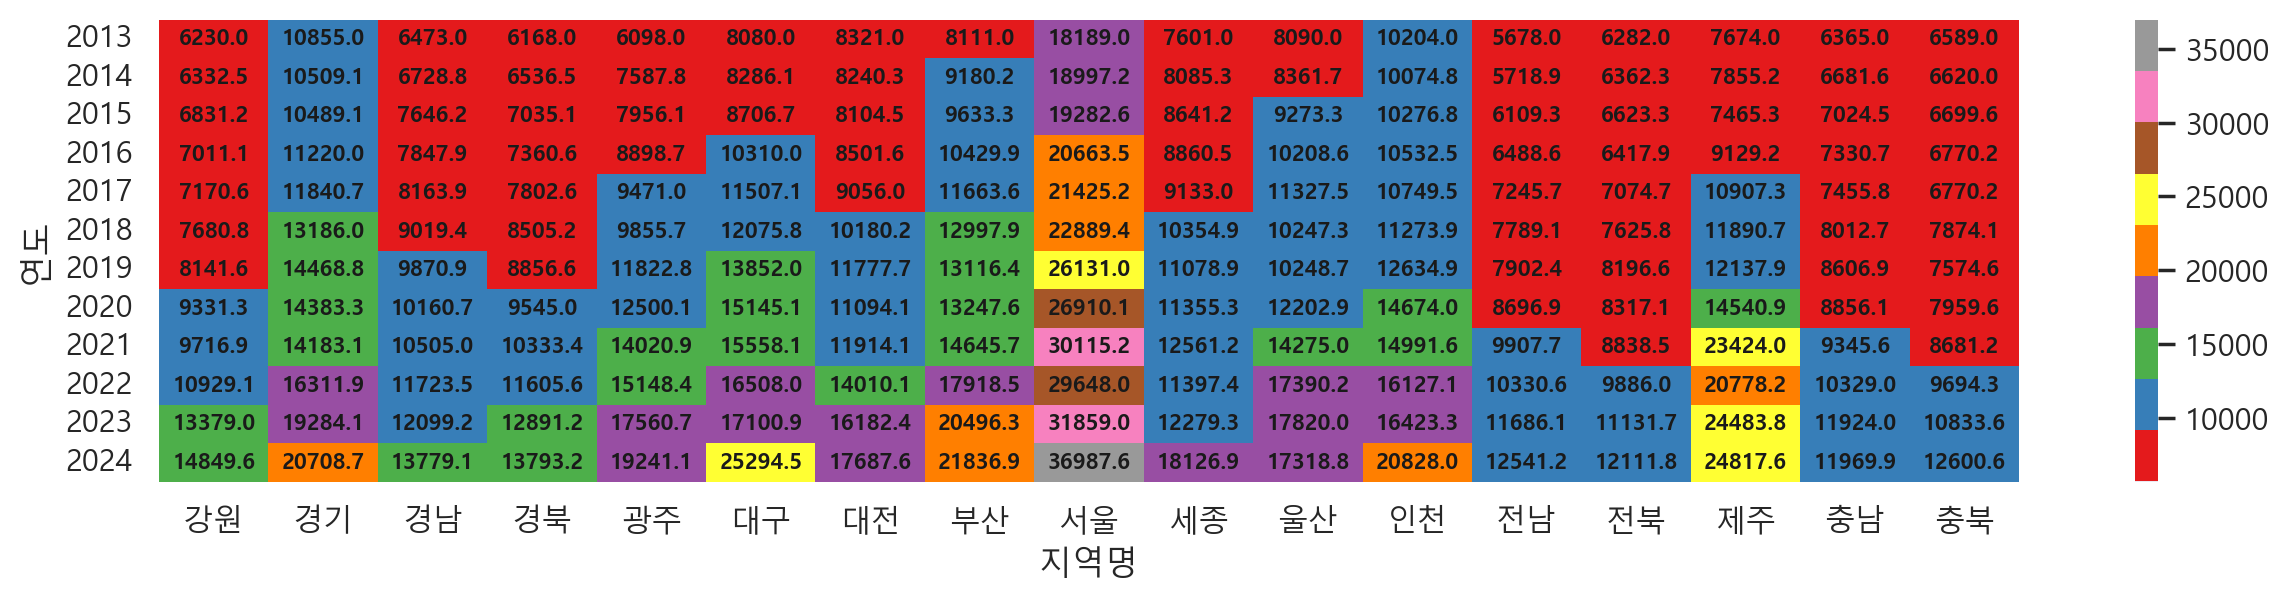

In [465]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)
sns.heatmap(data = df.groupby(['연도','지역명'])['평당분양가격'].mean().unstack(), cmap = 'Set1', annot = True, fmt = '.1f', annot_kws={'weight':'bold', 'color':'k', "size":8},)

# 다시 수행

<Axes: xlabel='연도', ylabel='평당분양가격'>

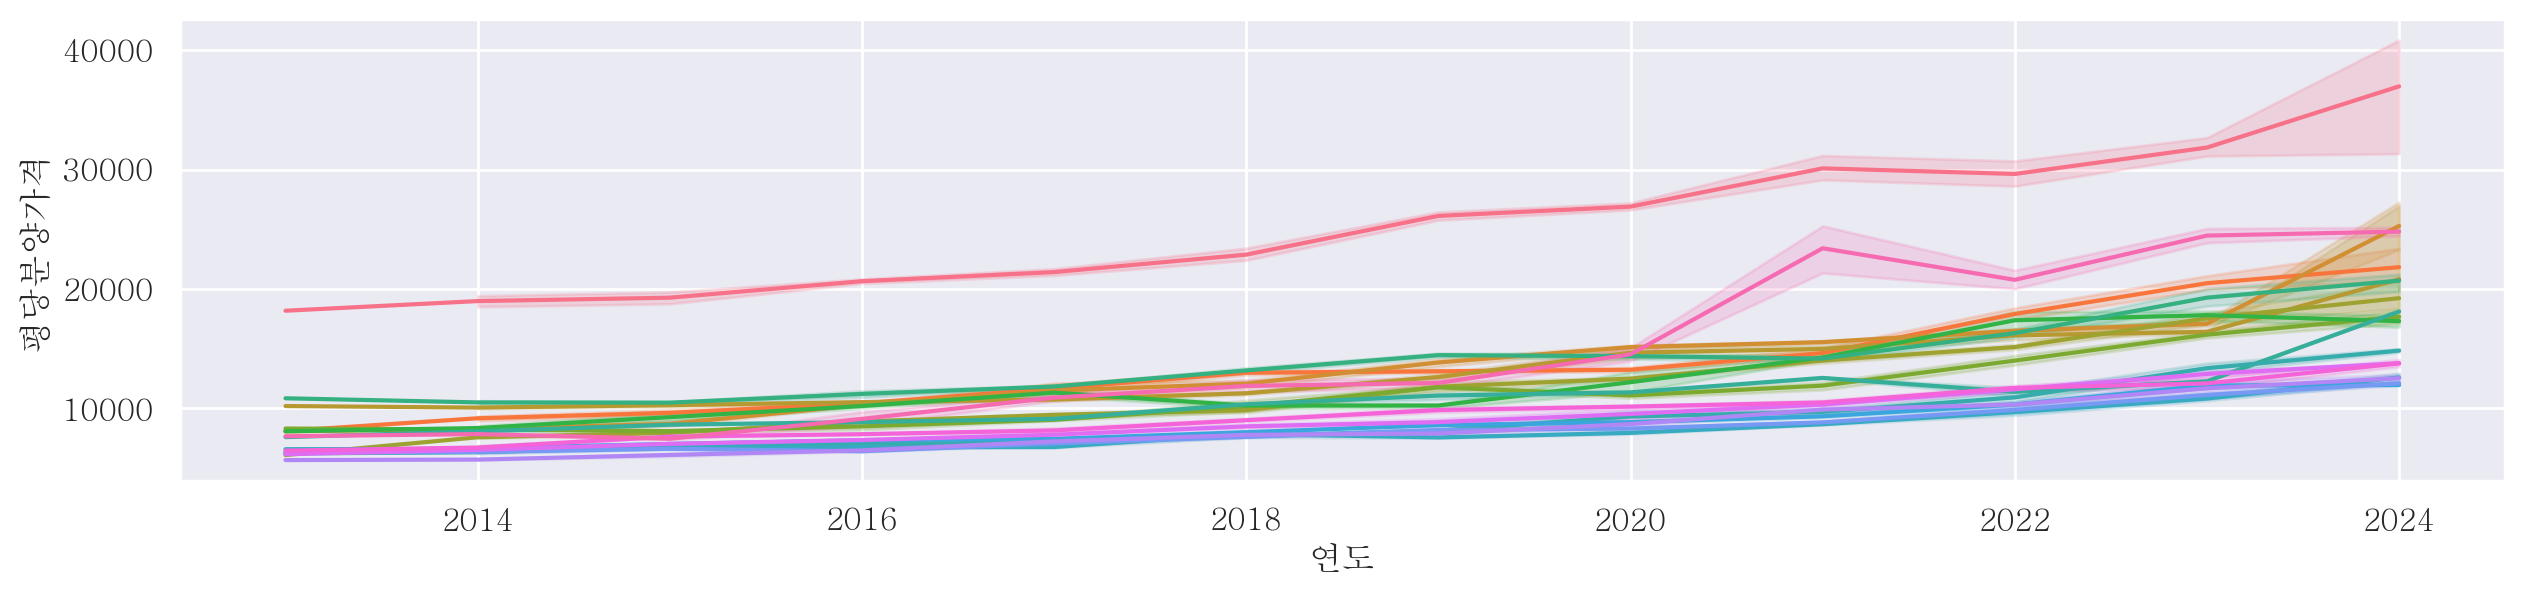

In [424]:
# 년도별 평균 평당분양가격의 추이
sns.lineplot(data = df, x='연도', y='평당분양가격', hue = '지역명', legend=False)

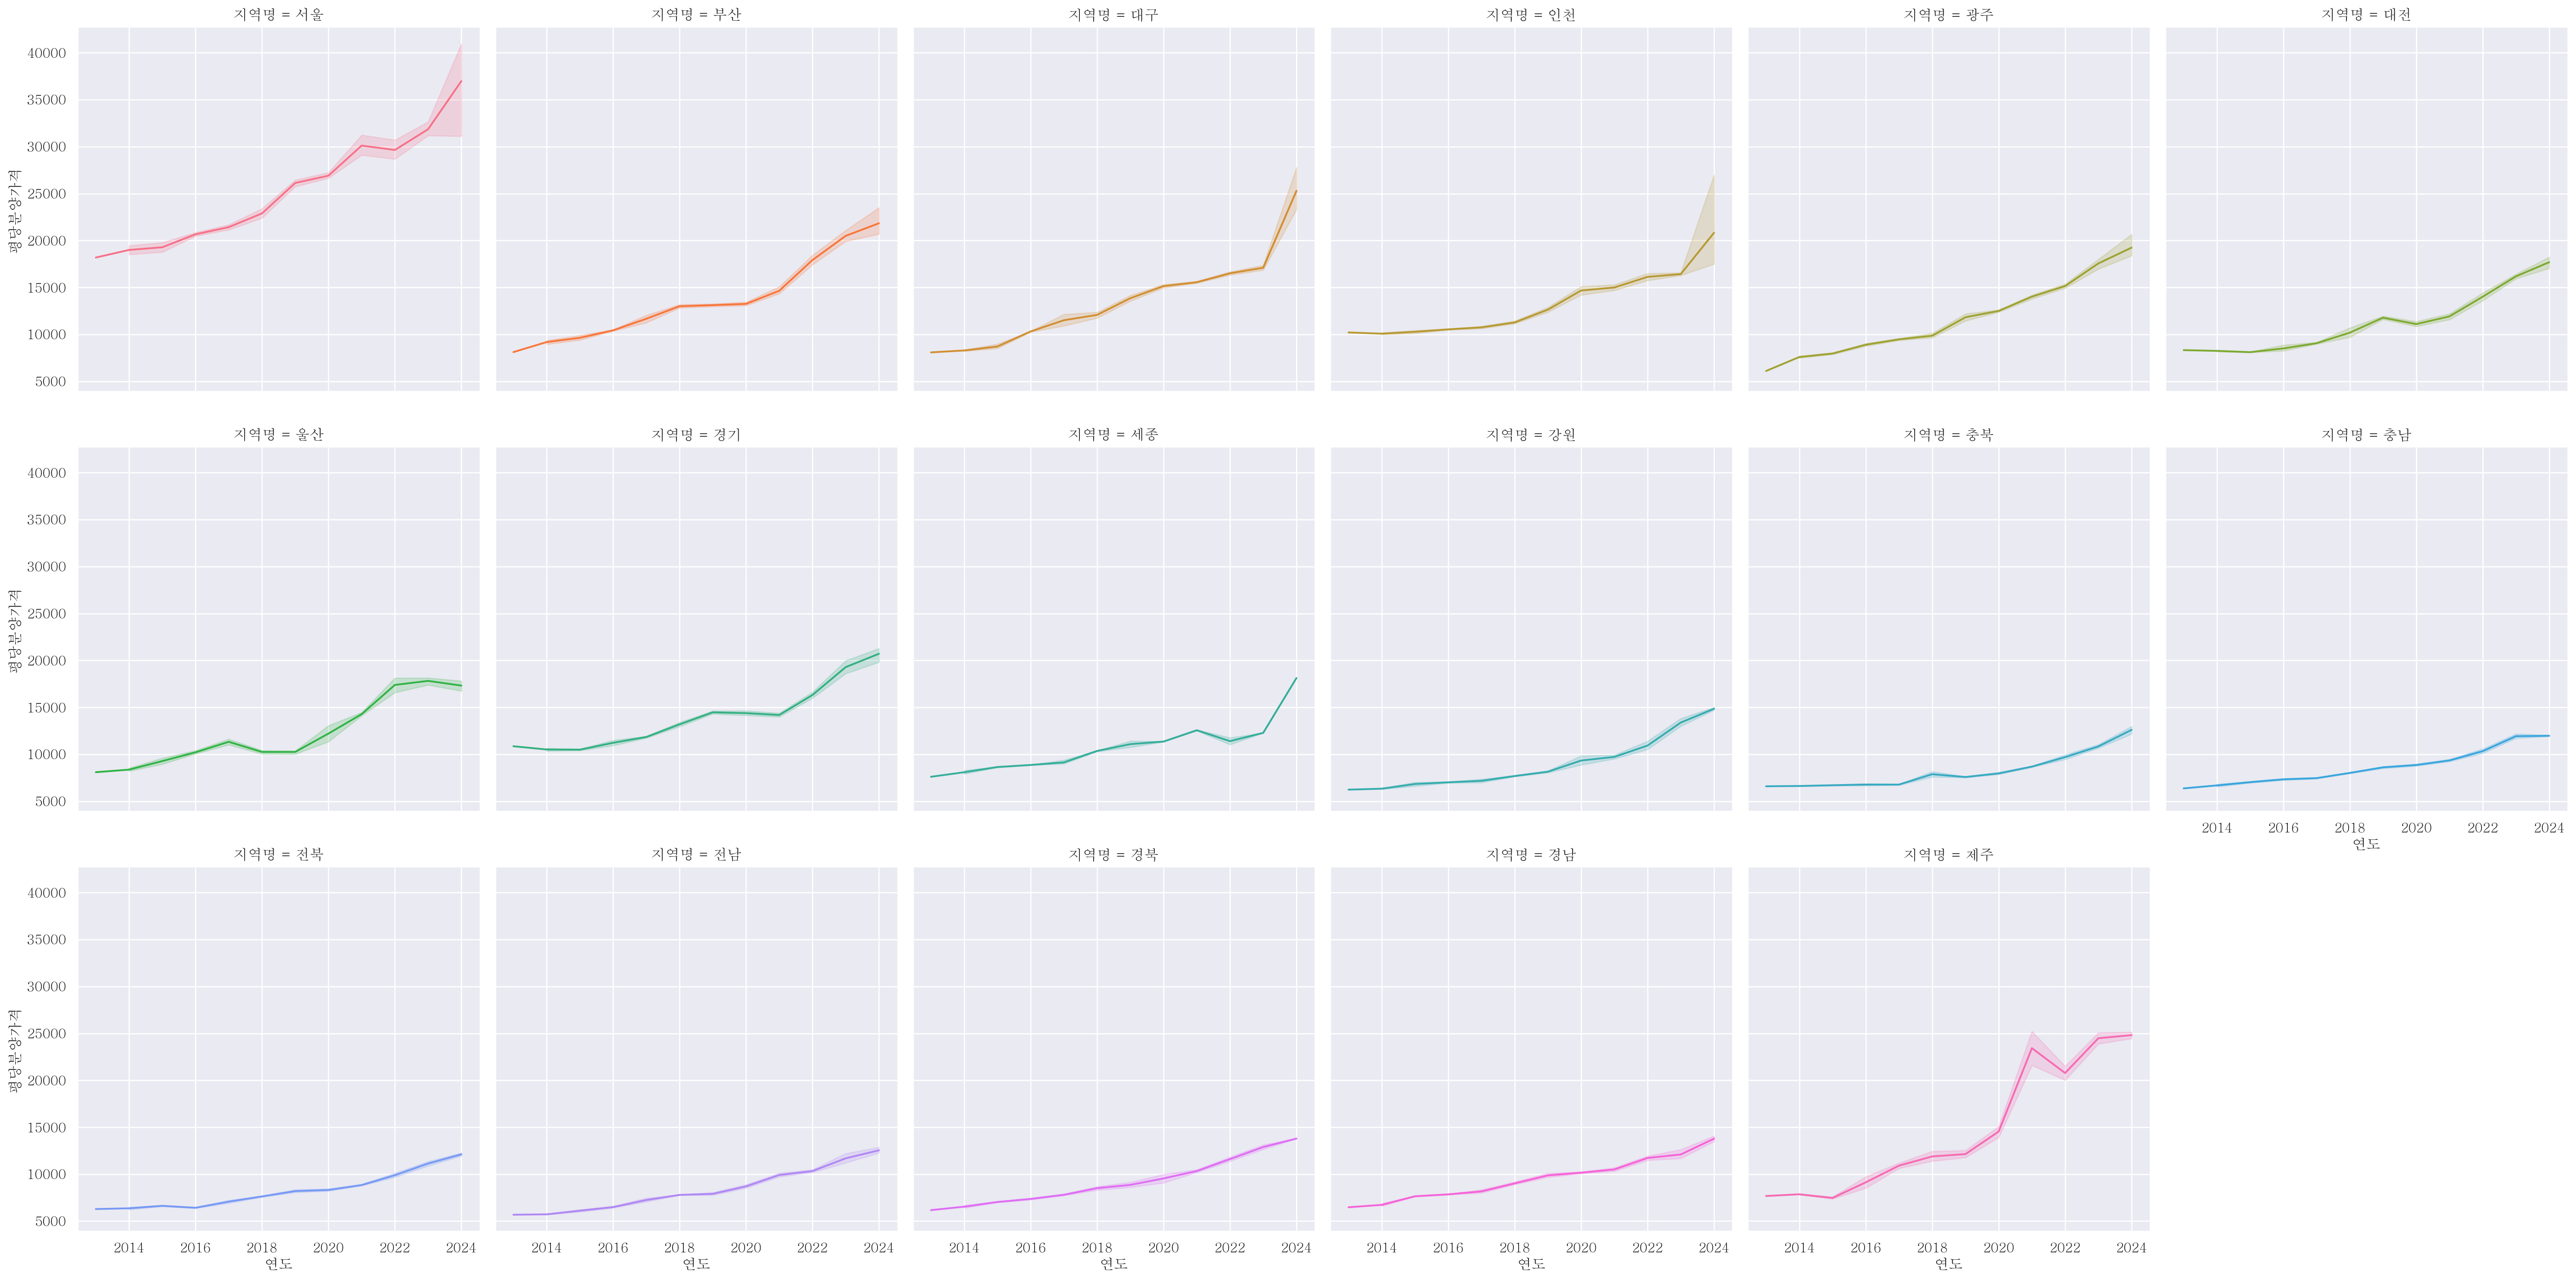

In [430]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리
sns.relplot(data = df, x='연도', y='평당분양가격', hue = '지역명', legend=False, col='지역명', kind='line', col_wrap = 6)

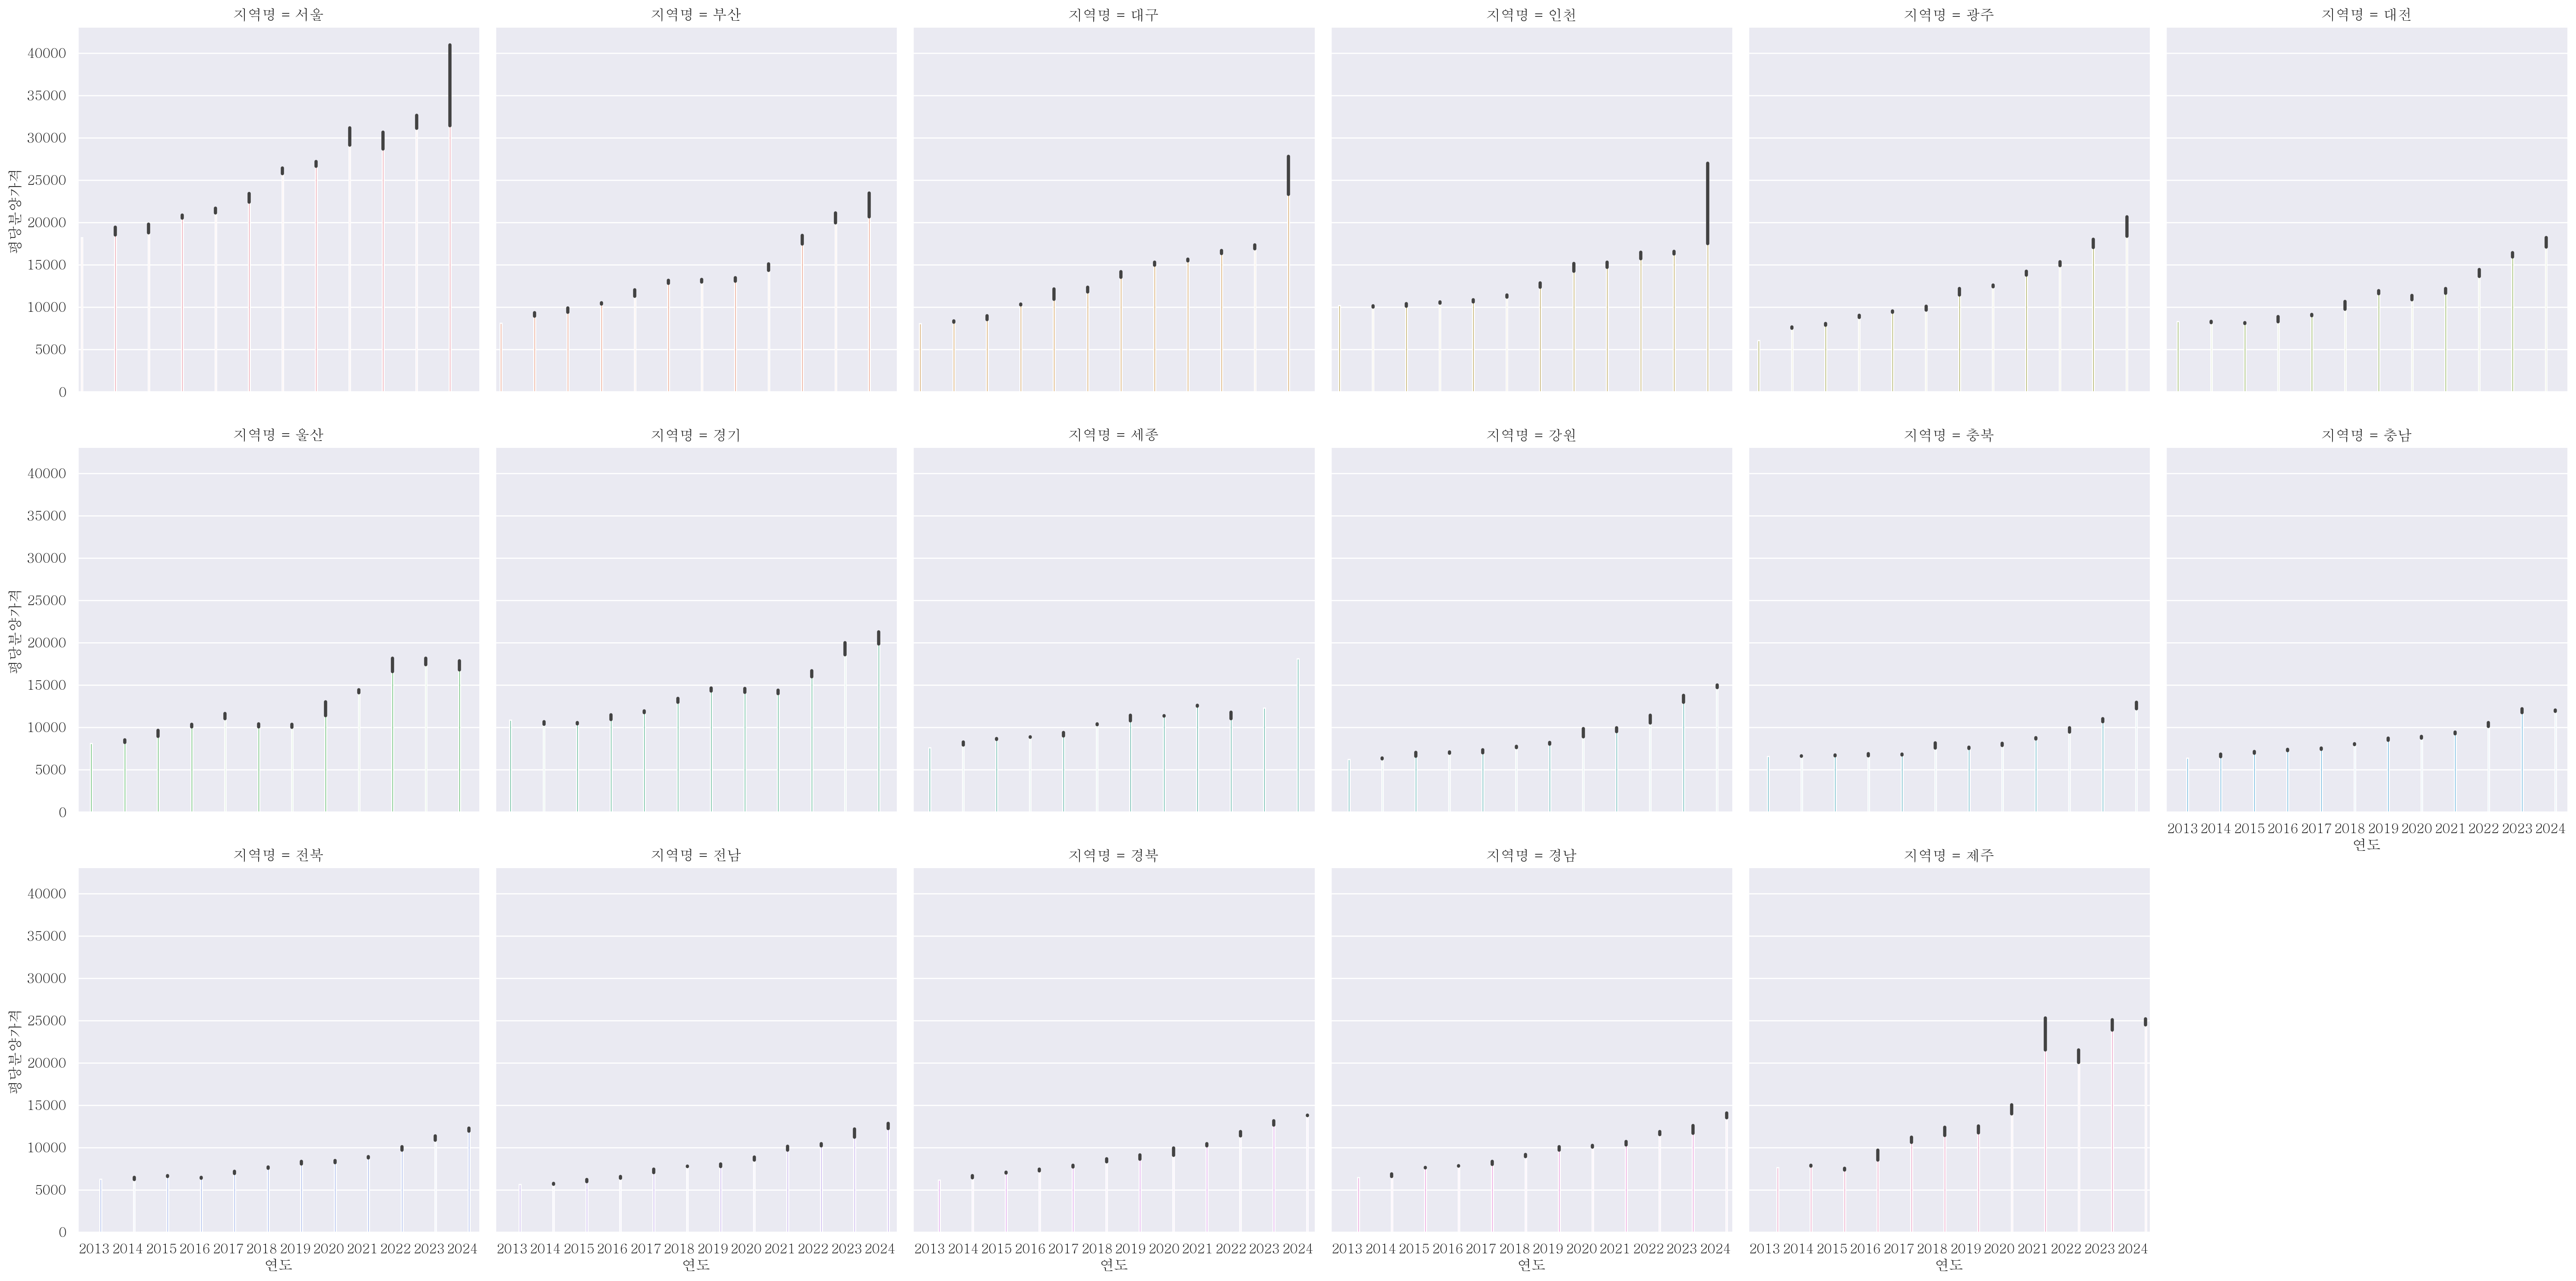

In [455]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot
sns.catplot(data = df, x='연도', y='평당분양가격', hue = '지역명', legend=False, col='지역명', kind='bar', col_wrap = 6,facet_kws={'sharex':False, 'sharey':True})

In [434]:
# 연도별 평당분양가격의 사분위수
df.groupby('연도')['평당분양가격'].quantile([0,0.25,0.5,0.75,1]).to_frame().T

연도        2013                                     2014                  \
          0.00    0.25    0.50    0.75     1.00    0.00    0.25    0.50   
평당분양가격  5678.0  6282.0  7601.0  8111.0  18189.0  5609.0  6585.5  7823.5   

연도                         2015  ...     2022     2023                    \
          0.75     1.00    0.00  ...     1.00     0.00     0.25     0.50   
평당분양가격  8568.0  20269.0  5784.0  ...  32396.1  10381.8  12031.8  16080.9   

연도                           2024                                           
           0.75     1.00     0.00       0.25      0.50       0.75     1.00  
평당분양가격  18183.0  34947.0  11540.1  13400.475  17821.65  20893.125  43939.5  

[1 rows x 60 columns]

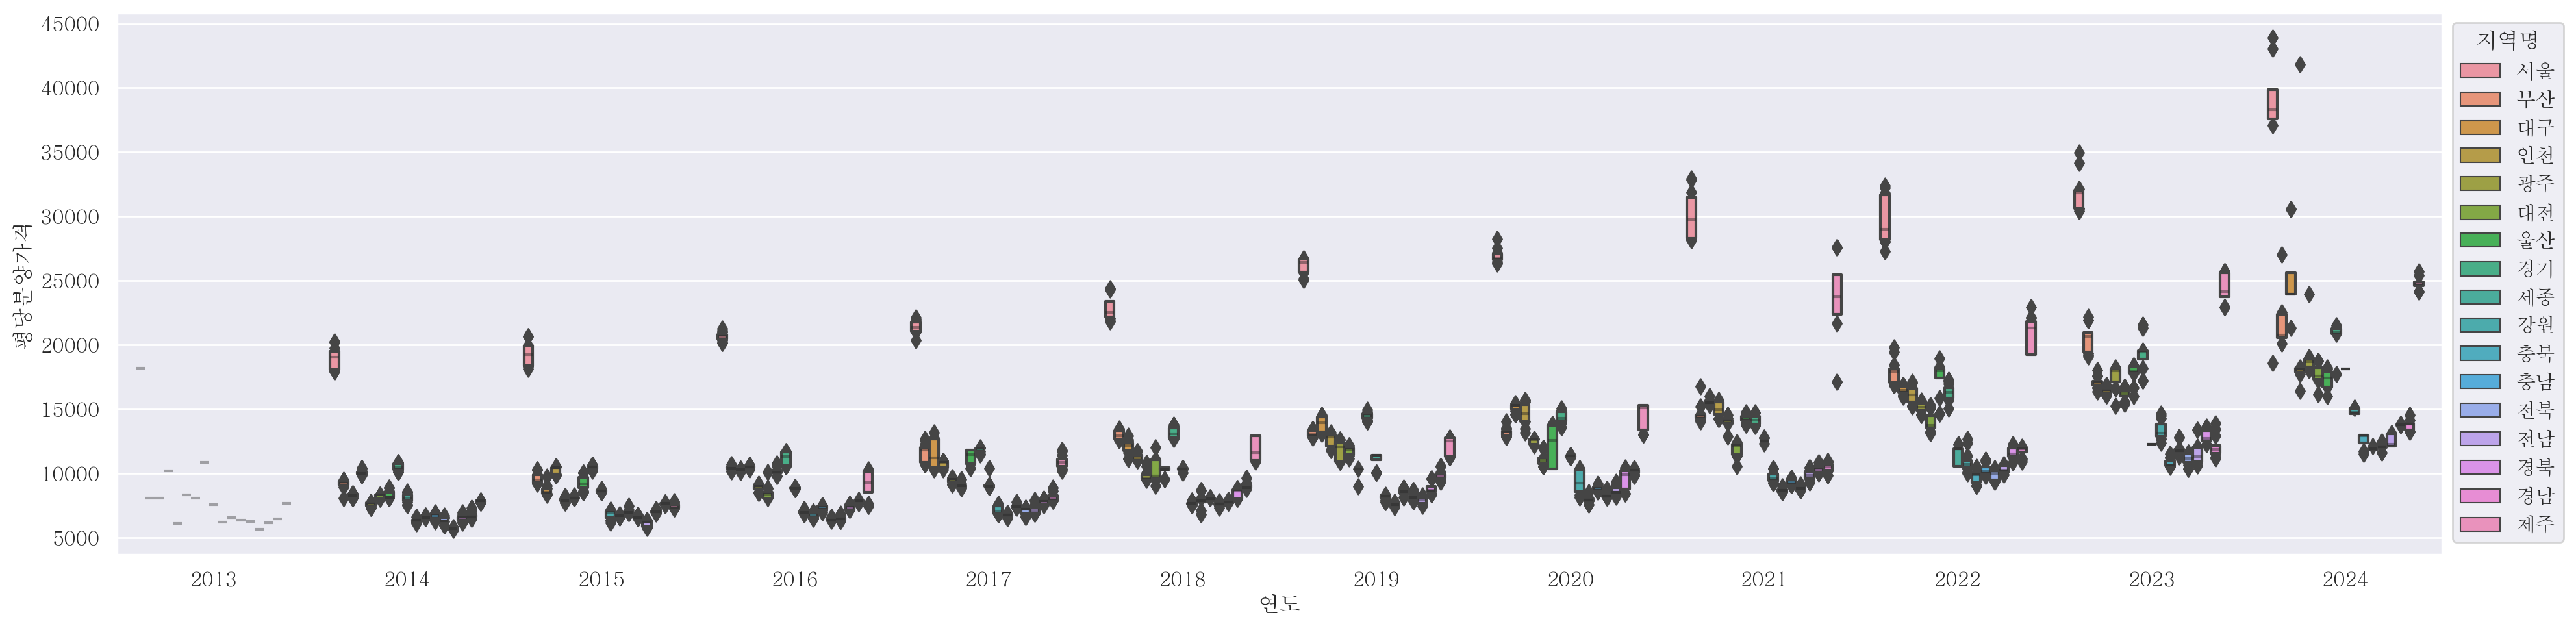

In [440]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)
plt.figure(figsize=(20,5))
ax = sns.boxenplot(data=df, x = '연도', y = '평당분양가격', hue = '지역명')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

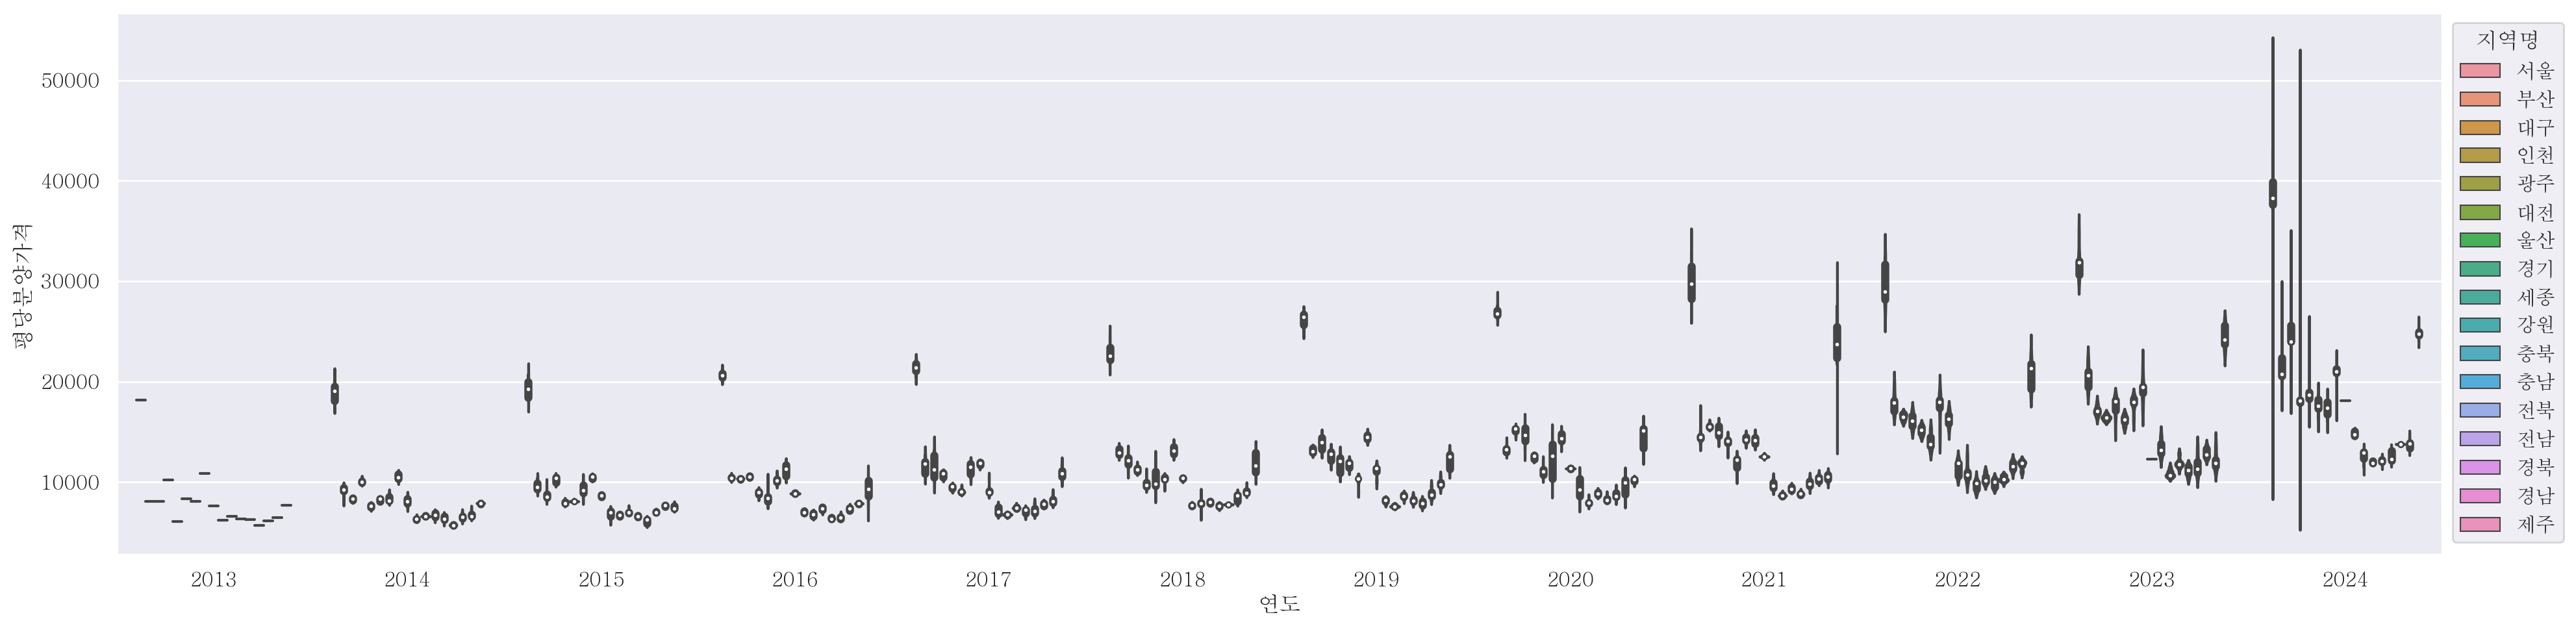

In [441]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)
plt.figure(figsize=(20,5))
ax = sns.violinplot(data=df, x = '연도', y = '평당분양가격', hue = '지역명')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

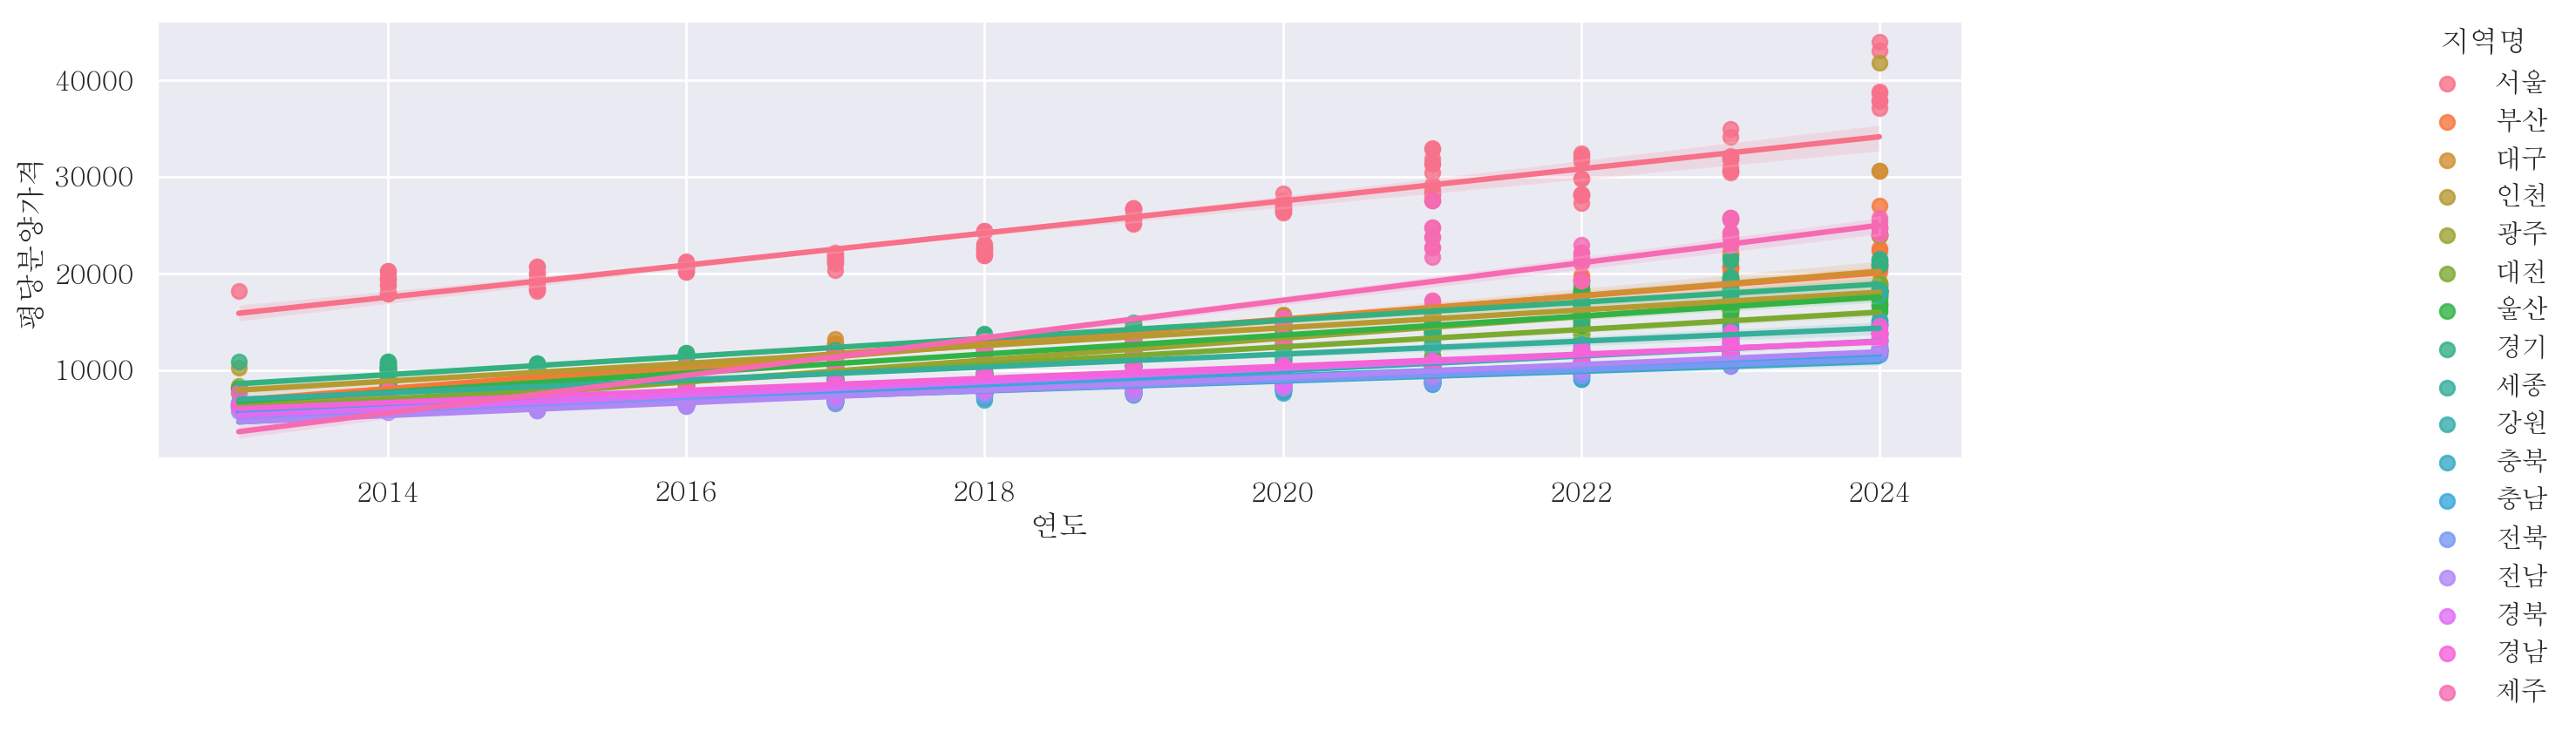

In [447]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화 : regplot => lmplot
ax = sns.lmplot(data = df, x = '연도', y = '평당분양가격', hue = '지역명') # hue X
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.fig.set_size_inches(16,3)
plt.show()

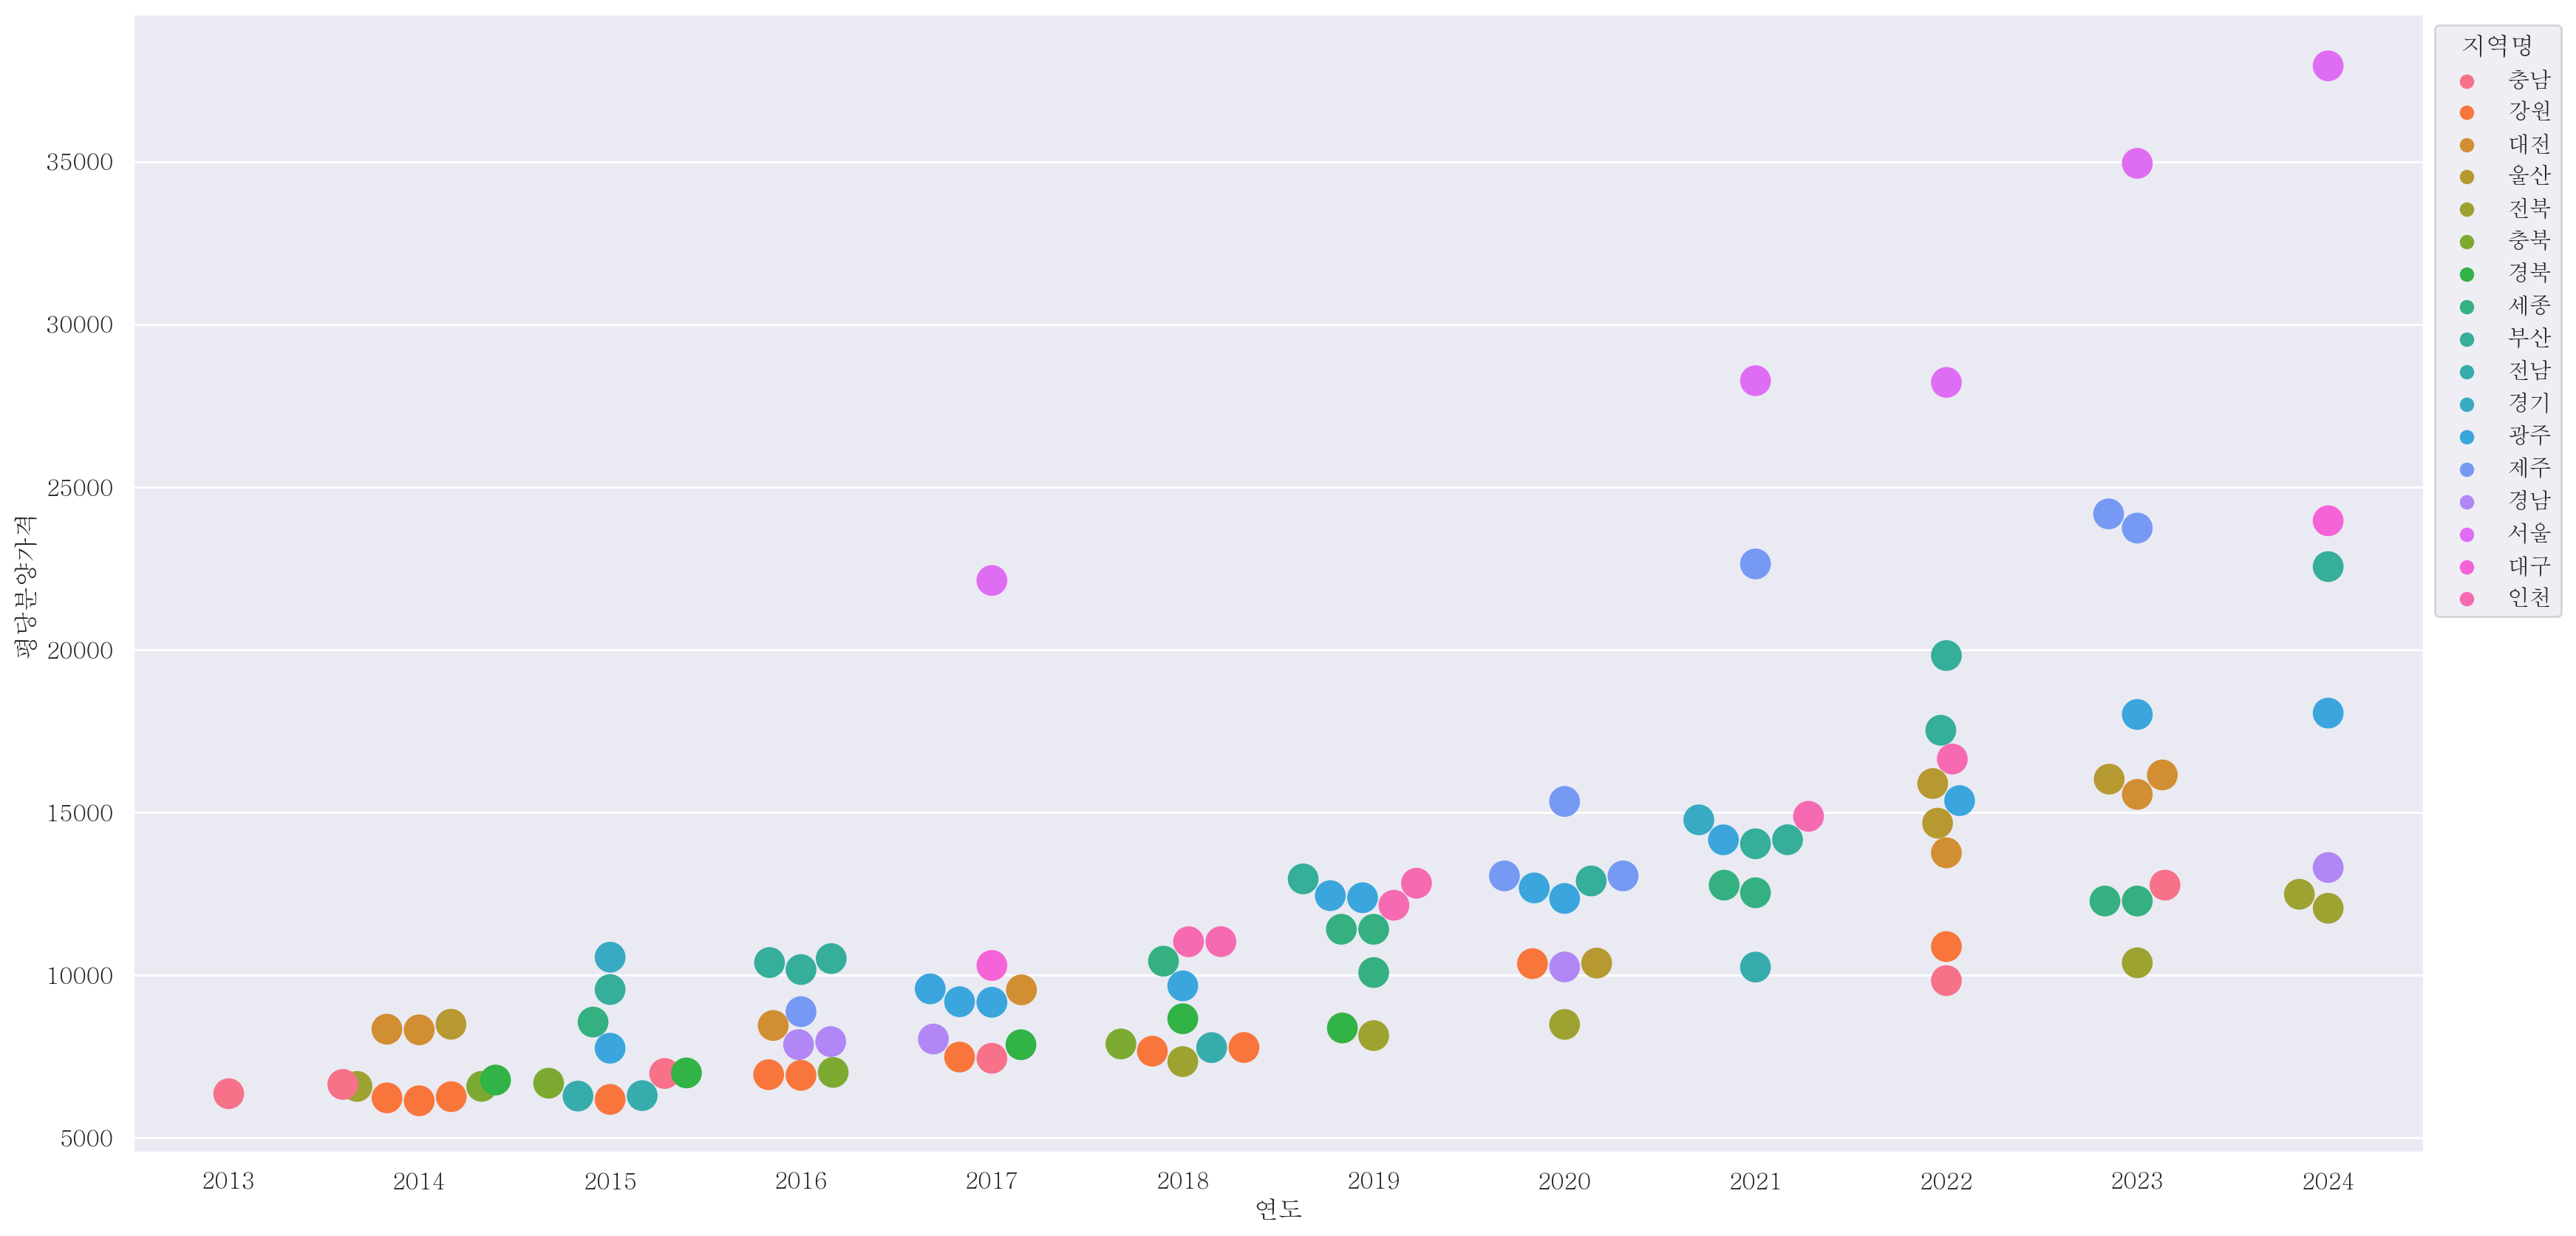

In [451]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
from sklearn.model_selection import train_test_split
_,df_sample = train_test_split(df,
                              test_size = 0.05,
                              stratify=df.연도)
plt.figure(figsize=(20,10))
ax = sns.swarmplot(data = df_sample, x= '연도', y = '평당분양가격', hue = '지역명', size = 15)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

<Axes: xlabel='평당분양가격', ylabel='Count'>

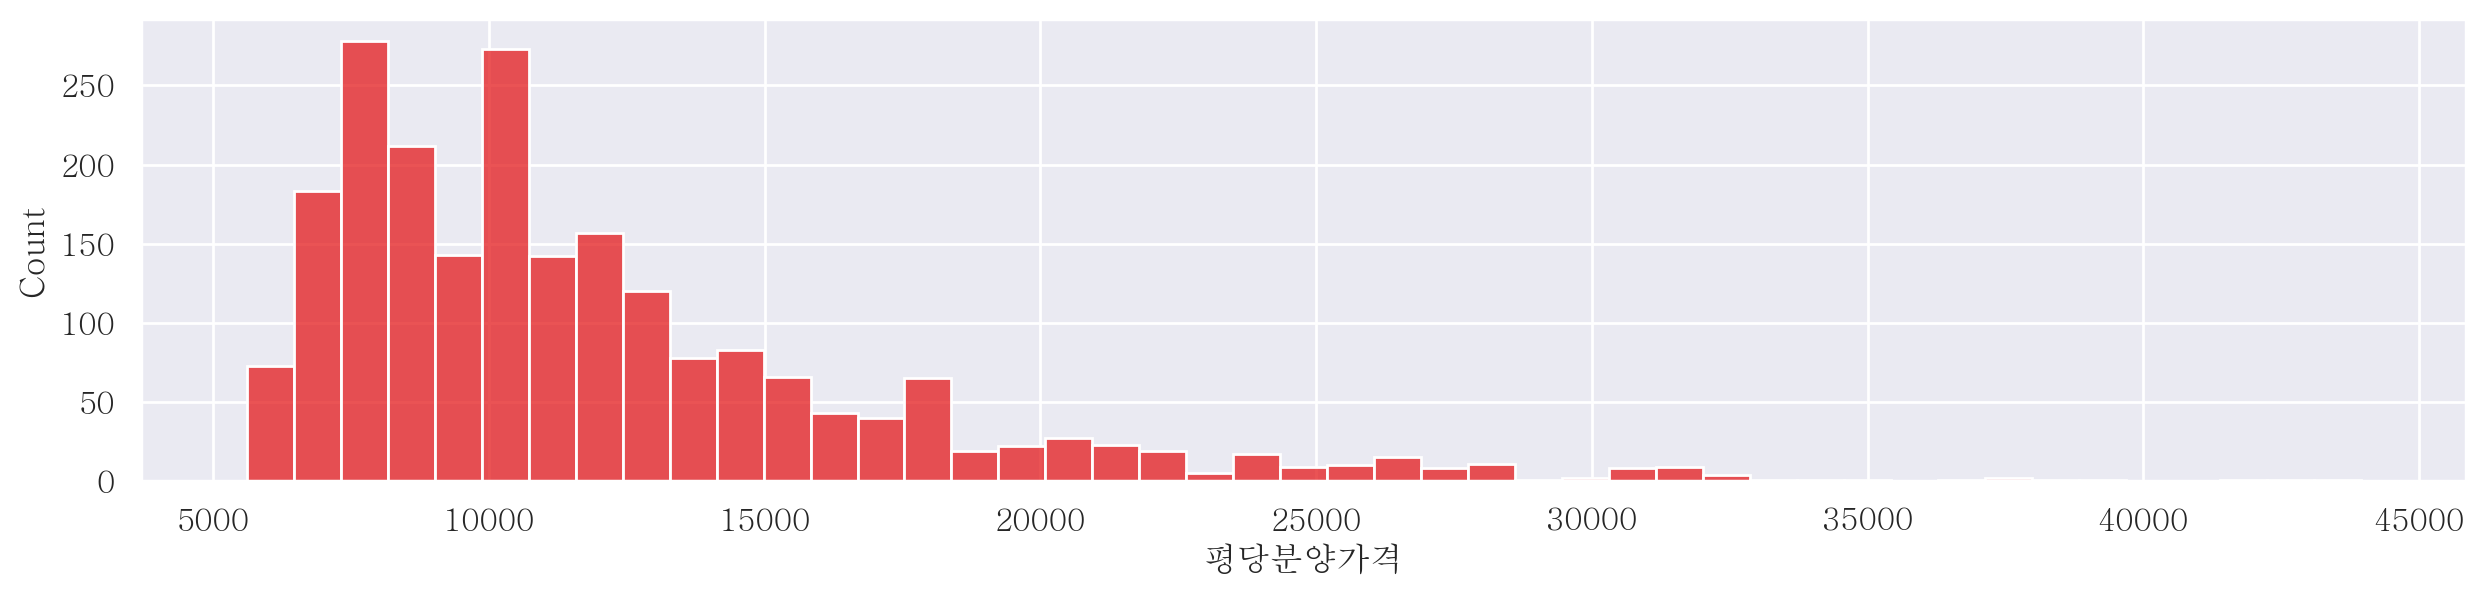

In [452]:
# 분양가격을 hist
sns.histplot(data = df, x = '평당분양가격')

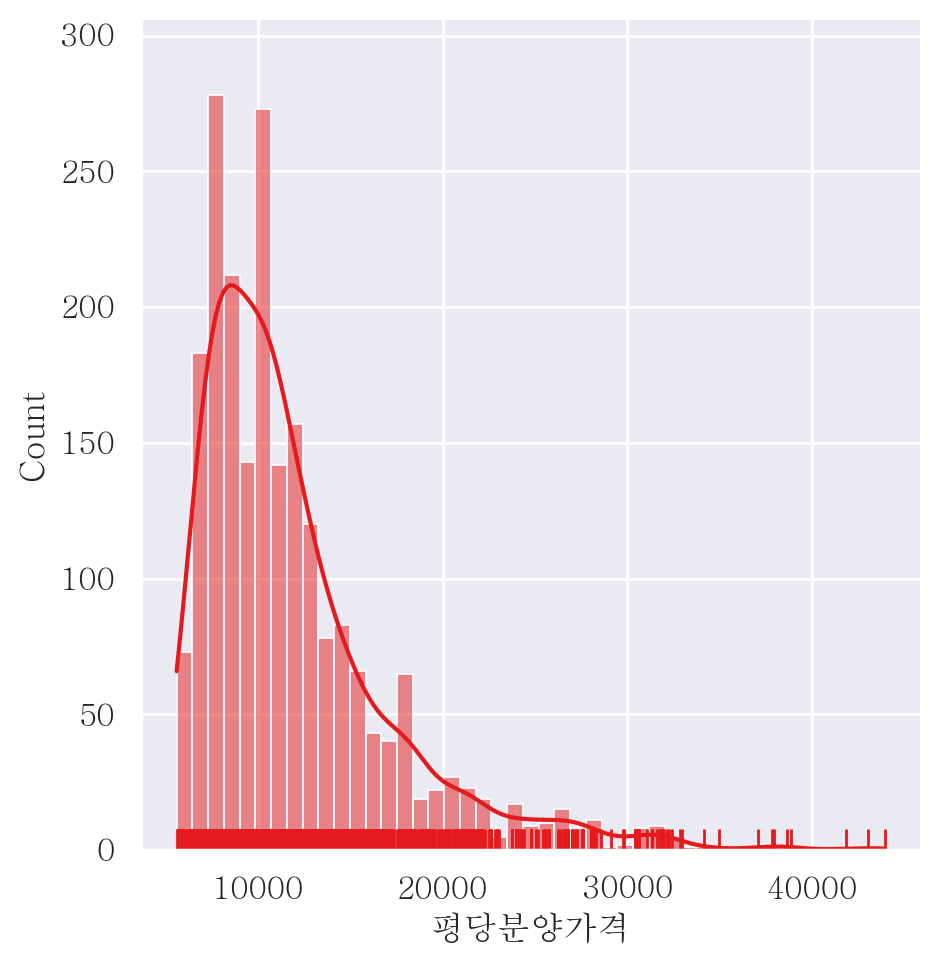

In [453]:
sns.displot(data = df, x = '평당분양가격', kde = True, rug = True)